# 30 — Model Cards, Compute, and Scalability

**Origin:** New Notebook; incorporates existing model-audit documentation  
**Controlled-300 refactor status:** Finished                    
**Validation status:** Finished                 
**Completion gate passed:** Yes
**Output root:** `outputs/30_model_cards_compute_and_scalability/`  
**Depends on:** Notebooks 09–29, including Notebook 12A, and model-audit sources

## Purpose

Create auditable method cards for every evaluated restoration method and analyse their observed compute, storage, failure and scalability evidence without running restoration or metric inference.

The notebook documents:

- exact method and implementation identity;
- original purpose, licence and available training-data information;
- input, mask, resolution, prompt and compositing constraints;
- intended and unsupported uses;
- painting-domain gap, limitations and bias risks;
- deterministic or stochastic behaviour;
- evaluated evidence coverage;
- observed runtime, throughput, memory, storage, failures and retries;
- transparent future runtime and storage projections;
- scoped quality evidence from Notebook 21;
- reproducibility and human-decision-support boundaries.

## Evaluated method scope

The notebook creates five method cards:

| Method | Evaluation status | Executed scope |
|---|---|---|
| OpenCV Telea | Fully evaluated | 2,620 candidates across 300 paintings |
| LaMa | Fully evaluated | 2,620 candidates across 300 paintings |
| HINT | Fully evaluated | 2,620 candidates across 300 paintings |
| Stable Diffusion Inpainting | Fully evaluated | 8,520 candidates across 300 paintings |
| SDXL Inpainting | Partial evaluation | 35 scheduled cases across 30 paintings; 24 completed across 19 paintings |

Telea, LaMa, HINT and Stable Diffusion cover the complete 2,620-case eligible design. Stable Diffusion additionally includes repeated seeds and the approved prompt arm.

SDXL remains a bounded partial evaluation. It is not promoted to the complete 2,620-case comparison.

## Quality-evidence contract

Quality evidence comes from Notebook 21’s eleven validated anchors.

Two populations remain separate:

- `core_three_model`: stable schema identifier for the four full-scope methods—Telea, LaMa, HINT and Stable Diffusion—across 2,620 cases;
- `sdxl_four_model_subset`: stable schema identifier for all five methods across the 24 completed SDXL cases and 19 represented paintings.

Anchor wins are descriptive counts across validated evidence views. They are not combined quality scores, conservation rankings or universal model rankings.

Runtime is never included in the quality vote.

## Compute and projection contract

The notebook retains 32 observed runtime-summary rows from Notebooks 09–12A.

It adds ten explicitly labelled projection rows across two scenarios and five methods:

1. `projected_600_current_design_mix`
   - doubles the executed Controlled-300 design for the four full-scope methods;
   - 5,240 candidate records each for Telea, LaMa and HINT;
   - 17,040 Stable Diffusion candidate records;
   - SDXL is not applicable because it lacks a complete-design execution basis.

2. `projected_300_sdxl_full_design`
   - projects 2,620 SDXL candidate records;
   - includes 2,320 inferred nonzero cases and 300 identity zero controls;
   - all four already executed full-scope methods are not applicable to this SDXL-specific scenario.

Median, mean and p95 observed runtimes provide projection-sensitivity values. They are not confidence intervals.

The Controlled-300 values are executed observations. Only the 600-painting and full-design SDXL rows are projections.

## Model-card contract

Each standalone Markdown card follows the approved thirteen-section structure:

1. at a glance;
2. identity and provenance;
3. intended and unsupported use;
4. training data and painting-domain gap;
5. project implementation;
6. evaluated evidence coverage;
7. compute and storage;
8. quality evidence;
9. determinism, robustness and uncertainty;
10. scalability;
11. strengths and weaknesses;
12. human decision-support interpretation;
13. reproducibility and provenance.

The cards are text-native and portable. They contain no external image dependencies or base64 image payloads.

Notebook 31 owns the image-heavy model reports.

## Interpretation limits

- Observed runtime and memory describe the recorded workstation and software environment.
- Projections are transparent linear sensitivity estimates, not executed experiments.
- Projected storage excludes model caches, environments, Git history and downstream metric outputs.
- No energy or carbon measurements were performed.
- Stable Diffusion uncertainty is empirical repeated-seed variability, not calibrated confidence.
- Telea, LaMa and HINT are deterministic and receive no artificial uncertainty values.
- SDXL has one seed per completed case and therefore receives no seed-based uncertainty estimate.
- SDXL’s incomplete bounded schedule cannot support a full-scope ranking.
- No method card establishes historical authenticity, conservation suitability or approval for physical treatment.

## Canonical outputs

- `data/model_cards.csv`
- `metrics/compute_scalability.csv`
- `reports/model_cards/opencv_telea.md`
- `reports/model_cards/lama.md`
- `reports/model_cards/hint_places2.md`
- `reports/model_cards/stable_diffusion_inpainting.md`
- `reports/model_cards/sdxl_inpainting.md`
- `figures/quality_vs_compute.png`
- `figures/scaling_projection.png`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads the approved Controlled-300 Notebook 30 configuration and helper;
- declares all exact input and output paths;
- creates only Notebook 30-owned output directories;
- verifies the refreshed inventory and its zero-error state;
- verifies the roadmap, implementation guidelines, evidence audit, evidence-coverage contract, literature log and current model-audit notes;
- verifies completion manifests for Notebooks 09–29, including Notebook 12A;
- verifies the exact candidate and runtime-table row counts for all five methods;
- locks the four-full-method plus bounded-SDXL evaluation-status contract;
- locks the 32-observed-row and ten-projection-row arithmetic;
- locks the two approved future projection scenarios;
- locks the eleven quality anchors and two separate evaluation populations;
- verifies that five Markdown cards retain the approved thirteen-section structure;
- prohibits combined quality scores, fabricated SDXL coverage, projected-as-executed claims, universal-runtime claims, calibrated-confidence claims and conservation claims.

This batch does not build model-card rows, calculate projections, generate figures, write canonical outputs or render the final Markdown cards.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.model_cards_compute import (
    COMPUTE_COLUMNS,
    COMPUTE_SCHEMA_VERSION,
    CONFIG_SCHEMA_VERSION,
    MODEL_CARD_COLUMNS,
    MODEL_CARD_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    atomic_write_csv,
    atomic_write_text,
    build_model_cards,
    build_scaling_projections,
    coerce_compute_scalability,
    collect_observed_compute,
    load_model_cards_compute_config,
    prepare_quality_evidence,
    render_model_card_markdown,
    resolve_model_cards_compute_inputs,
    summarize_output_storage,
    validate_compute_scalability,
    validate_model_card_markdown,
    validate_model_cards,
    validate_upstream_completion,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 180)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()


def reset_validation_stage(
    collector: ValidationCollector,
    stage: str,
) -> ValidationCollector:
    """Remove one validation stage so its cells can be rerun safely."""
    preserved = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]
    refreshed = ValidationCollector()
    refreshed.extend(preserved)
    return refreshed


def add_check(
    *,
    stage: str,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
    details="",
) -> None:
    """Register one JSON-safe validation check."""
    VALIDATION.add(
        validation_stage=stage,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


print("Notebook 30 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 30 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.model_cards_compute 2.0.0


In [2]:
BATCH_1_STAGE = "batch_1_preflight"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_1_STAGE,
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "model_cards_compute.yaml"
)

ANALYSIS_CONFIG = load_model_cards_compute_config(
    CONFIG_PATH
)
SETTINGS = ANALYSIS_CONFIG["model_cards_compute"]
EXPECTED = SETTINGS["expected_counts"]

INPUT_PATHS = resolve_model_cards_compute_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (
    PROJECT_ROOT
    / OUTPUT_SPEC["root"]
).resolve()

REPORT_ROOT = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["model_card_reports_dir"]
)

MODEL_IDS = tuple(
    model["model_id"]
    for model in SETTINGS["models"]
)

MODEL_CARD_REPORT_PATHS = {
    model_id: REPORT_ROOT / f"{model_id}.md"
    for model_id in MODEL_IDS
}

OUTPUT_PATHS = {
    "model_cards": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["model_cards_path"]
    ),
    "compute_scalability": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["compute_scalability_path"]
    ),
    "quality_vs_compute_figure": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["quality_vs_compute_figure_path"]
    ),
    "scaling_projection_figure": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["scaling_projection_figure_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["validation_path"]
    ),
}

SMOKE_DIR = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["smoke_dir"]
)

CANONICAL_FILE_PATHS = (
    OUTPUT_PATHS["model_cards"],
    OUTPUT_PATHS["compute_scalability"],
    *MODEL_CARD_REPORT_PATHS.values(),
    OUTPUT_PATHS["quality_vs_compute_figure"],
    OUTPUT_PATHS["scaling_projection_figure"],
    OUTPUT_PATHS["run_manifest"],
    OUTPUT_PATHS["artifacts"],
    OUTPUT_PATHS["validation"],
)

preexisting_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_FILE_PATHS:
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

SMOKE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in CANONICAL_FILE_PATHS
)

configured_schema_versions = {
    "configuration": ANALYSIS_CONFIG[
        "config_schema_version"
    ],
    "model_cards": SETTINGS[
        "model_card_schema_version"
    ],
    "compute": SETTINGS[
        "compute_schema_version"
    ],
}

expected_schema_versions = {
    "configuration": CONFIG_SCHEMA_VERSION,
    "model_cards": MODEL_CARD_SCHEMA_VERSION,
    "compute": COMPUTE_SCHEMA_VERSION,
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="supported_python_version",
    description=(
        "Python uses an approved major and minor version."
    ),
    expected=["3.11", "3.12"],
    observed=(
        f"{sys.version_info.major}."
        f"{sys.version_info.minor}"
    ),
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="configuration_and_schema_versions",
    description=(
        "Configuration and canonical schemas match "
        "the Notebook 30 helper."
    ),
    expected=expected_schema_versions,
    observed=configured_schema_versions,
    passed=(
        configured_schema_versions
        == expected_schema_versions
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="controlled_300_dataset_contract",
    description=(
        "Notebook 30 uses the executed Controlled-300 "
        "dataset identity."
    ),
    expected={
        "dataset_scope": "controlled_300",
        "dataset_version": "2.0.0",
    },
    observed={
        "dataset_scope": SETTINGS["dataset_scope"],
        "dataset_version": SETTINGS["dataset_version"],
    },
    passed=(
        SETTINGS["dataset_scope"] == "controlled_300"
        and SETTINGS["dataset_version"] == "2.0.0"
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="all_declared_inputs_exist",
    description=(
        "Every explicitly declared Notebook 30 input exists."
    ),
    expected=len(SETTINGS["inputs"]),
    observed=sum(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
    passed=all(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="output_root_is_notebook_owned",
    description=(
        "Every canonical output belongs to the exact "
        "Notebook 30 output root."
    ),
    expected=True,
    observed=paths_inside_output_root,
    passed=paths_inside_output_root,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_physical_file_count",
    description=(
        "The Controlled-300 contract contains exactly "
        "twelve physical canonical output files."
    ),
    expected=EXPECTED["canonical_file_count"],
    observed=len(CANONICAL_FILE_PATHS),
    passed=(
        len(CANONICAL_FILE_PATHS)
        == EXPECTED["canonical_file_count"]
        == 12
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="fresh_output_root",
    description=(
        "Notebook 30 starts without pre-existing output files."
    ),
    expected=0,
    observed=len(preexisting_output_files),
    passed=not preexisting_output_files,
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "relative_path": (
                output_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists_after_setup": output_path.exists(),
        }
        for artifact_name, output_path in (
            list(OUTPUT_PATHS.items())
            + [
                (
                    f"model_card_{model_id}",
                    report_path,
                )
                for model_id, report_path
                in MODEL_CARD_REPORT_PATHS.items()
            ]
        )
    ]
)

display(output_contract)

print("Configuration and output contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS):,}")
print(f"Declared methods: {len(MODEL_IDS):,}")
print(
    "Canonical physical files: "
    f"{len(CANONICAL_FILE_PATHS):,}"
)
print(f"Output root: {OUTPUT_ROOT}")

,artifact,relative_path,exists_after_setup
0,model_cards,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,False
1,compute_scalability,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,False
2,quality_vs_compute_figure,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,False
3,scaling_projection_figure,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,False
4,run_manifest,outputs/30_model_cards_compute_and_scalability/manifests/run_manifest.json,False
5,artifacts,outputs/30_model_cards_compute_and_scalability/manifests/artifacts.csv,False
6,validation,outputs/30_model_cards_compute_and_scalability/validation/checks.csv,False
7,model_card_opencv_telea,outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_telea.md,False
8,model_card_lama,outputs/30_model_cards_compute_and_scalability/reports/model_cards/lama.md,False
9,model_card_hint_places2,outputs/30_model_cards_compute_and_scalability/reports/model_cards/hint_places2.md,False


Configuration and output contract validated.
Declared inputs: 49
Declared methods: 5
Canonical physical files: 12
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\30_model_cards_compute_and_scalability


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

ROADMAP_TEXT = INPUT_PATHS[
    "notebook_roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_dependency_audit_path"
].read_text(encoding="utf-8-sig")

MODEL_AUDIT_TEXT = INPUT_PATHS[
    "model_audit_notes_path"
].read_text(encoding="utf-8-sig")

LITERATURE_LOG_TEXT = (
    PROJECT_ROOT
    / "docs"
    / "literature_reference_log.md"
).read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .fillna("")
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/model_cards_compute.yaml",
    "src/restoration_eval/model_cards_compute.py",
    "tests/test_model_cards_compute.py",
    "notebooks/30_model_cards_compute_and_scalability.ipynb",
    "docs/final_notebook_roadmap.md",
    "docs/refactoring_implementation_guidelines.md",
    "docs/evidence_dependency_audit.md",
    "docs/model_audit_notes.md",
    "docs/literature_reference_log.md",
    "config/evaluation/evidence_coverage.yaml",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get(
        "planned_notebooks",
        [],
    )
}

N30_COVERAGE = planned_notebooks.get(
    "30",
    {},
)

UPSTREAM_NOTEBOOK_IDS = (
    "09",
    "10",
    "11",
    "12",
    "12a",
    *tuple(
        f"{notebook_number:02d}"
        for notebook_number in range(13, 30)
    ),
)

MANIFESTS = {}

for notebook_id in UPSTREAM_NOTEBOOK_IDS:
    manifest_key = f"manifest_{notebook_id}_path"

    with INPUT_PATHS[manifest_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        MANIFESTS[notebook_id] = json.load(handle)

UPSTREAM_COMPLETION = validate_upstream_completion(
    MANIFESTS
)

STORAGE_SUMMARY = summarize_output_storage(
    INVENTORY,
    config=ANALYSIS_CONFIG,
)

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get(
            "summary",
            {},
        ).get(
            "read_error_count",
            -1,
        )
    )
    == 0
)

missing_preparation_paths = sorted(
    required_preparation_paths
    - inventory_relative_paths
)

manual_notebook_policy_present = (
    "The assistant must not create, replace, patch, "
    "or otherwise edit an `.ipynb`"
    in IMPLEMENTATION_GUIDELINES_TEXT
)

roadmap_contract_present = (
    "## 30 — Model Cards, Compute, and Scalability"
    in ROADMAP_TEXT
    and "five portable Markdown model cards"
    not in ROADMAP_TEXT
    and "The five cards are OpenCV Telea"
    in ROADMAP_TEXT
    and "32 observed runtime-summary rows"
    in ROADMAP_TEXT
    and "ten"
    in ROADMAP_TEXT
    and "reports/model_cards/<model_id>.md"
    in ROADMAP_TEXT
)

evidence_gate_present = (
    "Notebook 30, `30_model_cards_compute_and_scalability.ipynb`, "
    "is reopened for its"
    in EVIDENCE_AUDIT_TEXT
    and (
        "600-painting and full-design SDXL rows "
        "are linear sensitivity projections"
        in EVIDENCE_AUDIT_TEXT
    )
)

normalized_model_audit_text = " ".join(
    MODEL_AUDIT_TEXT.casefold().split()
)

current_model_audit_present = all(
    required_text
    in normalized_model_audit_text
    for required_text in (
        "five portable markdown model cards",
        "32 observed summaries",
        "8,520 n11 rows",
        "retain sdxl as `partial_evaluation`",
        "controlled-300 run is executed evidence",
    )
)

normalized_literature_text = " ".join(
    LITERATURE_LOG_TEXT.casefold().split()
)

literature_contract_present = all(
    required_text
    in normalized_literature_text
    for required_text in (
        "300 paintings, five balanced broad visual categories",
        "five method cards",
        "32 observed runtime summaries",
        "ten explicitly labelled projection rows",
        "not executed results or confidence intervals",
    )
)

coverage_expected = N30_COVERAGE.get(
    "expected_counts",
    {},
)

coverage_contract_present = (
    N30_COVERAGE.get("stem")
    == "30_model_cards_compute_and_scalability"
    and N30_COVERAGE.get("status")
    == "controlled_300_preparation_complete_pending_rerun"
    and not N30_COVERAGE.get(
        "completion_gate_passed",
        True,
    )
    and coverage_expected.get("model_cards") == 5
    and coverage_expected.get(
        "observed_compute_rows"
    ) == 32
    and coverage_expected.get(
        "projection_rows"
    ) == 10
    and coverage_expected.get(
        "compute_rows"
    ) == 42
    and coverage_expected.get(
        "physical_canonical_files"
    ) == 12
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="inventory_run_completed",
    description=(
        "The refreshed inventory completed without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": (
            INVENTORY_RUN.get(
                "summary",
                {},
            ).get("read_error_count")
        ),
        "inventory_run_id": (
            INVENTORY_RUN.get("inventory_run_id")
        ),
    },
    passed=inventory_status_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="preparation_files_in_inventory",
    description=(
        "The refreshed inventory contains the complete "
        "Notebook 30 preparation layer."
    ),
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths
        & inventory_relative_paths
    ),
    passed=not missing_preparation_paths,
    details={
        "missing": missing_preparation_paths,
    },
)

governing_document_status = {
    "manual_notebook_policy": (
        manual_notebook_policy_present
    ),
    "roadmap_contract": roadmap_contract_present,
    "evidence_gate": evidence_gate_present,
    "model_audit_current": (
        current_model_audit_present
    ),
    "literature_contract": (
        literature_contract_present
    ),
    "machine_readable_coverage": (
        coverage_contract_present
    ),
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="governing_documents_reference_n30",
    description=(
        "The governing documents retain the approved "
        "Controlled-300 Notebook 30 contract and "
        "manual-editing policy."
    ),
    expected={
        key: True
        for key in governing_document_status
    },
    observed=governing_document_status,
    passed=all(
        governing_document_status.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="project_paths_registry_schema",
    description=(
        "The project-path registry uses the approved schema."
    ),
    expected="project_paths.v1",
    observed=PROJECT_PATHS_REGISTRY.get(
        "registry_schema_version"
    ),
    passed=(
        PROJECT_PATHS_REGISTRY.get(
            "registry_schema_version"
        )
        == "project_paths.v1"
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="upstream_notebooks_complete",
    description=(
        "Every required Notebook 09–29 manifest, "
        "including Notebook 12A, is complete and "
        "has passed its completion gate."
    ),
    expected=EXPECTED["upstream_manifest_count"],
    observed=int(
        UPSTREAM_COMPLETION["passed"].sum()
    ),
    passed=(
        len(UPSTREAM_COMPLETION)
        == EXPECTED["upstream_manifest_count"]
        == 22
        and UPSTREAM_COMPLETION["passed"].all()
    ),
    details={
        "failed_notebooks": (
            UPSTREAM_COMPLETION.loc[
                ~UPSTREAM_COMPLETION["passed"],
                "notebook_id",
            ].tolist()
        )
    },
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_output_storage_available",
    description=(
        "Inventory contains positive method-owned storage "
        "with no read errors for all five producers."
    ),
    expected={
        "models": 5,
        "positive_storage": True,
        "read_errors": 0,
    },
    observed={
        "models": len(STORAGE_SUMMARY),
        "positive_storage": bool(
            STORAGE_SUMMARY[
                "output_storage_bytes"
            ].gt(0).all()
        ),
        "read_errors": int(
            STORAGE_SUMMARY[
                "read_error_count"
            ].sum()
        ),
    },
    passed=(
        len(STORAGE_SUMMARY) == 5
        and STORAGE_SUMMARY[
            "output_storage_bytes"
        ].gt(0).all()
        and STORAGE_SUMMARY[
            "read_error_count"
        ].eq(0).all()
    ),
)

display(UPSTREAM_COMPLETION)
display(STORAGE_SUMMARY)

print("Inventory and governing documents validated.")
print(
    "Completed upstream manifests: "
    f"{int(UPSTREAM_COMPLETION['passed'].sum()):,}/"
    f"{len(UPSTREAM_COMPLETION):,}"
)
print(
    "Inventory read errors: "
    f"{INVENTORY_RUN['summary']['read_error_count']:,}"
)

,notebook_id,manifest_present,run_status,completion_gate_passed,passed,details
0,09,True,completed,True,True,run=completed; gate=True
1,10,True,completed,True,True,run=completed; gate=True
2,11,True,completed,True,True,run=completed; gate=True
3,12,True,completed,True,True,run=completed; gate=True
4,12a,True,completed,True,True,run=completed; gate=True
5,13,True,completed,True,True,run=completed; gate=True
6,14,True,completed,True,True,run=completed; gate=True
7,15,True,completed,True,True,run=completed; gate=True
8,16,True,completed,True,True,run=completed; gate=True
9,17,True,completed,True,True,run=completed; gate=True


,model_id,output_root,output_file_count,output_storage_bytes,restored_image_file_count,restored_image_storage_bytes,fixed_file_count,fixed_storage_bytes,read_error_count
0,opencv_telea,outputs/09_opencv_telea_restoration,2626,1867107732,2620,1858391487,6,8716245,0
1,lama,outputs/10_lama_restoration,2626,1895034954,2620,1885438253,6,9596701,0
2,hint_places2,outputs/12a_hint_restoration,2626,1923441386,2620,1913956520,6,9484866,0
3,stable_diffusion_inpainting,outputs/11_stable_diffusion_restoration,8530,6188889017,8520,6157836387,10,31052630,0
4,sdxl_inpainting,outputs/12_sdxl_feasibility_or_restoration,30,16975786,24,16813006,6,162780,0


Inventory and governing documents validated.
Completed upstream manifests: 22/22
Inventory read errors: 0


In [4]:
def csv_row_count(path: Path) -> int:
    """Count CSV rows without retaining the complete table."""
    return int(
        sum(
            len(chunk)
            for chunk in pd.read_csv(
                path,
                usecols=[0],
                chunksize=50_000,
            )
        )
    )


QUALITY_POLICY = SETTINGS["quality"]
PROJECTION_POLICY = SETTINGS["projections"]
REPORT_POLICY = SETTINGS["report"]
EVIDENCE_POLICY = SETTINGS["evidence_policy"]

input_count_specs = (
    (
        "Telea candidates",
        "telea_candidates_path",
        "telea_candidate_rows",
    ),
    (
        "LaMa candidates",
        "lama_candidates_path",
        "lama_candidate_rows",
    ),
    (
        "HINT candidates",
        "hint_candidates_path",
        "hint_candidate_rows",
    ),
    (
        "Stable Diffusion candidates",
        "stable_diffusion_candidates_path",
        "stable_diffusion_candidate_rows",
    ),
    (
        "SDXL scheduled candidates",
        "sdxl_candidates_path",
        "sdxl_candidate_rows",
    ),
    (
        "Telea runtime summaries",
        "telea_runtime_path",
        "telea_runtime_rows",
    ),
    (
        "LaMa runtime summaries",
        "lama_runtime_path",
        "lama_runtime_rows",
    ),
    (
        "HINT runtime summaries",
        "hint_runtime_path",
        "hint_runtime_rows",
    ),
    (
        "Stable Diffusion runtime summaries",
        "stable_diffusion_runtime_path",
        "stable_diffusion_runtime_rows",
    ),
    (
        "SDXL runtime summaries",
        "sdxl_runtime_path",
        "sdxl_runtime_rows",
    ),
)

input_count_contract = pd.DataFrame(
    [
        {
            "input": label,
            "observed_rows": csv_row_count(
                INPUT_PATHS[input_key]
            ),
            "expected_rows": EXPECTED[
                expected_key
            ],
        }
        for label, input_key, expected_key
        in input_count_specs
    ]
)

input_count_contract["passed"] = (
    input_count_contract["observed_rows"]
    == input_count_contract["expected_rows"]
)

MODEL_SPECS = {
    model["model_id"]: model
    for model in SETTINGS["models"]
}

expected_model_statuses = {
    "opencv_telea": "fully_evaluated",
    "lama": "fully_evaluated",
    "hint_places2": "fully_evaluated",
    "stable_diffusion_inpainting": (
        "fully_evaluated"
    ),
    "sdxl_inpainting": "partial_evaluation",
}

observed_model_statuses = {
    model_id: model["evaluation_status"]
    for model_id, model in MODEL_SPECS.items()
}

SCENARIOS = {
    scenario["scenario_id"]: scenario
    for scenario in PROJECTION_POLICY["scenarios"]
}

scaled_design_projection = SCENARIOS[
    "projected_600_current_design_mix"
]

sdxl_full_design_projection = SCENARIOS[
    "projected_300_sdxl_full_design"
]

expected_scaled_design_targets = {
    "opencv_telea": 5240,
    "lama": 5240,
    "hint_places2": 5240,
    "stable_diffusion_inpainting": 17040,
    "sdxl_inpainting": None,
}

expected_scaled_design_inference = {
    "opencv_telea": 4640,
    "lama": 4640,
    "hint_places2": 4640,
    "stable_diffusion_inpainting": 16440,
    "sdxl_inpainting": None,
}

expected_scaled_design_controls = {
    "opencv_telea": 600,
    "lama": 600,
    "hint_places2": 600,
    "stable_diffusion_inpainting": 600,
    "sdxl_inpainting": None,
}

scaled_design_arithmetic_ok = (
    scaled_design_projection[
        "target_painting_count"
    ] == 600
    and scaled_design_projection[
        "target_candidates"
    ] == expected_scaled_design_targets
    and scaled_design_projection[
        "target_inference_candidates"
    ] == expected_scaled_design_inference
    and scaled_design_projection[
        "target_zero_controls"
    ] == expected_scaled_design_controls
)

expected_sdxl_targets = {
    "opencv_telea": None,
    "lama": None,
    "hint_places2": None,
    "stable_diffusion_inpainting": None,
    "sdxl_inpainting": 2620,
}

expected_sdxl_inference = {
    "opencv_telea": None,
    "lama": None,
    "hint_places2": None,
    "stable_diffusion_inpainting": None,
    "sdxl_inpainting": 2320,
}

expected_sdxl_controls = {
    "opencv_telea": None,
    "lama": None,
    "hint_places2": None,
    "stable_diffusion_inpainting": None,
    "sdxl_inpainting": 300,
}

sdxl_full_design_arithmetic_ok = (
    sdxl_full_design_projection[
        "target_painting_count"
    ] == 300
    and sdxl_full_design_projection[
        "target_candidates"
    ] == expected_sdxl_targets
    and sdxl_full_design_projection[
        "target_inference_candidates"
    ] == expected_sdxl_inference
    and sdxl_full_design_projection[
        "target_zero_controls"
    ] == expected_sdxl_controls
)

quality_population_contract = {
    population_id: {
        "models": population["model_ids"],
        "cases": population["case_count"],
        "paintings": population[
            "painting_count"
        ],
    }
    for population_id, population
    in QUALITY_POLICY["populations"].items()
}

expected_quality_population_contract = {
    "core_three_model": {
        "models": [
            "opencv_telea",
            "lama",
            "hint_places2",
            "stable_diffusion_inpainting",
        ],
        "cases": 2620,
        "paintings": 300,
    },
    "sdxl_four_model_subset": {
        "models": [
            "opencv_telea",
            "lama",
            "hint_places2",
            "stable_diffusion_inpainting",
            "sdxl_inpainting",
        ],
        "cases": 24,
        "paintings": 19,
    },
}

prohibited_true = {
    key: bool(value)
    for key, value
    in EVIDENCE_POLICY.items()
    if bool(value)
}

source_urls = [
    source["url"]
    for source
    in SETTINGS["sources"]["records"]
]

candidate_rows_verified = int(
    input_count_contract.loc[
        input_count_contract["input"].str.contains(
            "candidates",
            case=False,
            regex=False,
        ),
        "observed_rows",
    ].sum()
)

runtime_rows_verified = int(
    input_count_contract.loc[
        input_count_contract["input"].str.contains(
            "runtime",
            case=False,
            regex=False,
        ),
        "observed_rows",
    ].sum()
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="candidate_and_runtime_row_counts",
    description=(
        "Every candidate and runtime input matches "
        "the exact approved Controlled-300 count."
    ),
    expected=True,
    observed=input_count_contract[
        [
            "input",
            "observed_rows",
            "expected_rows",
            "passed",
        ]
    ].to_dict("records"),
    passed=input_count_contract["passed"].all(),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_status_contract",
    description=(
        "Four methods remain fully evaluated and "
        "SDXL remains a bounded partial evaluation."
    ),
    expected=expected_model_statuses,
    observed=observed_model_statuses,
    passed=(
        observed_model_statuses
        == expected_model_statuses
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="compute_row_arithmetic",
    description=(
        "Thirty-two observed rows and ten projection "
        "rows produce forty-two canonical compute rows."
    ),
    expected={
        "observed": 32,
        "projected": 10,
        "total": 42,
    },
    observed={
        "observed": EXPECTED[
            "observed_compute_rows"
        ],
        "projected": EXPECTED[
            "projection_rows"
        ],
        "total": EXPECTED[
            "compute_rows"
        ],
    },
    passed=(
        EXPECTED["observed_compute_rows"] == 32
        and EXPECTED["projection_rows"] == 10
        and EXPECTED["compute_rows"] == 42
        and EXPECTED["compute_rows"]
        == (
            EXPECTED["observed_compute_rows"]
            + EXPECTED["projection_rows"]
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="scaled_design_projection_arithmetic",
    description=(
        "The 600-painting scenario doubles the "
        "complete executed design for the four "
        "full-scope methods without fabricating "
        "full SDXL coverage."
    ),
    expected={
        "paintings": 600,
        "targets": expected_scaled_design_targets,
        "inference": expected_scaled_design_inference,
        "zero_controls": (
            expected_scaled_design_controls
        ),
    },
    observed={
        "paintings": scaled_design_projection[
            "target_painting_count"
        ],
        "targets": scaled_design_projection[
            "target_candidates"
        ],
        "inference": scaled_design_projection[
            "target_inference_candidates"
        ],
        "zero_controls": scaled_design_projection[
            "target_zero_controls"
        ],
    },
    passed=scaled_design_arithmetic_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="sdxl_full_design_projection_arithmetic",
    description=(
        "The SDXL-specific scenario projects the "
        "complete 300-painting design only for SDXL."
    ),
    expected={
        "paintings": 300,
        "targets": expected_sdxl_targets,
        "inference": expected_sdxl_inference,
        "zero_controls": expected_sdxl_controls,
    },
    observed={
        "paintings": sdxl_full_design_projection[
            "target_painting_count"
        ],
        "targets": sdxl_full_design_projection[
            "target_candidates"
        ],
        "inference": sdxl_full_design_projection[
            "target_inference_candidates"
        ],
        "zero_controls": (
            sdxl_full_design_projection[
                "target_zero_controls"
            ]
        ),
    },
    passed=sdxl_full_design_arithmetic_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="quality_anchor_and_population_contract",
    description=(
        "Eleven validated anchors remain separated "
        "across the four-method core and bounded "
        "five-method SDXL population."
    ),
    expected={
        "anchors": 11,
        "populations": 2,
        "quality_anchor_rows": 22,
        "population_contract": (
            expected_quality_population_contract
        ),
    },
    observed={
        "anchors": len(
            QUALITY_POLICY["anchors"]
        ),
        "populations": len(
            QUALITY_POLICY["populations"]
        ),
        "quality_anchor_rows": EXPECTED[
            "quality_anchor_rows"
        ],
        "population_contract": (
            quality_population_contract
        ),
    },
    passed=(
        len(QUALITY_POLICY["anchors"]) == 11
        and len(
            QUALITY_POLICY["populations"]
        ) == 2
        and EXPECTED[
            "quality_anchor_rows"
        ] == 22
        and quality_population_contract
        == expected_quality_population_contract
        and not QUALITY_POLICY[
            "combined_quality_score_retained"
        ]
        and not QUALITY_POLICY[
            "runtime_in_quality_vote"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_card_report_contract",
    description=(
        "Five portable Markdown cards retain the "
        "approved thirteen-section structure."
    ),
    expected={
        "reports": 5,
        "sections": 13,
        "external_images": 0,
    },
    observed={
        "reports": len(
            MODEL_CARD_REPORT_PATHS
        ),
        "sections": len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        ),
        "external_images": (
            REPORT_POLICY[
                "required_external_image_dependencies"
            ]
        ),
        "text_native": (
            REPORT_POLICY[
                "self_contained_text"
            ]
        ),
        "mock_structure_locked": (
            REPORT_POLICY[
                "approved_mock_structure_locked"
            ]
        ),
    },
    passed=(
        len(MODEL_CARD_REPORT_PATHS) == 5
        and EXPECTED[
            "model_card_report_count"
        ] == 5
        and len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        ) == 13
        and REPORT_POLICY[
            "required_external_image_dependencies"
        ] == 0
        and REPORT_POLICY[
            "self_contained_text"
        ]
        and REPORT_POLICY[
            "approved_mock_structure_locked"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="primary_source_contract",
    description=(
        "All declared provenance sources use "
        "explicit HTTPS URLs."
    ),
    expected=True,
    observed=source_urls,
    passed=(
        len(source_urls) >= 10
        and all(
            url.startswith("https://")
            for url in source_urls
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="interpretation_protections",
    description=(
        "Every prohibited Notebook 30 "
        "interpretation remains disabled."
    ),
    expected={},
    observed=prohibited_true,
    passed=not prohibited_true,
)

display(input_count_contract)

projection_contract = pd.DataFrame(
    [
        {
            "scenario_id": scenario_id,
            "model_id": model_id,
            "target_paintings": scenario[
                "target_painting_count"
            ],
            "target_cases": scenario[
                "target_case_count"
            ][model_id],
            "target_candidates": scenario[
                "target_candidates"
            ][model_id],
            "target_inference_candidates": scenario[
                "target_inference_candidates"
            ][model_id],
            "target_zero_controls": scenario[
                "target_zero_controls"
            ][model_id],
            "executed": False,
        }
        for scenario_id, scenario
        in SCENARIOS.items()
        for model_id in MODEL_SPECS
    ]
)

display(projection_contract)

BATCH_1_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_1_ROWS = (
    BATCH_1_VALIDATION.loc[
        BATCH_1_VALIDATION[
            "validation_stage"
        ].eq(BATCH_1_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_1_ROWS)

blocking_failures = int(
    (
        BATCH_1_ROWS["severity"].eq("blocking")
        & ~BATCH_1_ROWS["passed"]
    ).sum()
)

print("Batch 1 contract and preflight complete.")
print(
    "Validation checks: "
    f"{len(BATCH_1_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Candidate rows verified: "
    f"{candidate_rows_verified:,}"
)
print(
    "Observed runtime rows verified: "
    f"{runtime_rows_verified:,}"
)
print(
    "Observed plus projected compute rows: "
    f"{EXPECTED['compute_rows']:,}"
)
print(
    "Standalone model cards planned: "
    f"{len(MODEL_CARD_REPORT_PATHS):,}"
)

VALIDATION.raise_for_blocking()

,input,observed_rows,expected_rows,passed
0,Telea candidates,2620,2620,True
1,LaMa candidates,2620,2620,True
2,HINT candidates,2620,2620,True
3,Stable Diffusion candidates,8520,8520,True
4,SDXL scheduled candidates,35,35,True
5,Telea runtime summaries,5,5,True
6,LaMa runtime summaries,5,5,True
7,HINT runtime summaries,5,5,True
8,Stable Diffusion runtime summaries,14,14,True
9,SDXL runtime summaries,3,3,True


,scenario_id,model_id,target_paintings,target_cases,target_candidates,target_inference_candidates,target_zero_controls,executed
0,projected_600_current_design_mix,opencv_telea,600,5240.0,5240.0,4640.0,600.0,False
1,projected_600_current_design_mix,lama,600,5240.0,5240.0,4640.0,600.0,False
2,projected_600_current_design_mix,hint_places2,600,5240.0,5240.0,4640.0,600.0,False
3,projected_600_current_design_mix,stable_diffusion_inpainting,600,5240.0,17040.0,16440.0,600.0,False
4,projected_600_current_design_mix,sdxl_inpainting,600,NaN,NaN,NaN,NaN,False
5,projected_300_sdxl_full_design,opencv_telea,300,NaN,NaN,NaN,NaN,False
6,projected_300_sdxl_full_design,lama,300,NaN,NaN,NaN,NaN,False
7,projected_300_sdxl_full_design,hint_places2,300,NaN,NaN,NaN,NaN,False
8,projected_300_sdxl_full_design,stable_diffusion_inpainting,300,NaN,NaN,NaN,NaN,False
9,projected_300_sdxl_full_design,sdxl_inpainting,300,2620.0,2620.0,2320.0,300.0,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_and_schema_versions,Configuration and canonical schemas match the Notebook 30 helper.,blocking,"{""compute"": ""compute_scalability.v1"", ""configuration"": ""model_cards_compute_config.v1"", ""model_cards"": ""model_cards.v1""}","{""compute"": ""compute_scalability.v1"", ""configuration"": ""model_cards_compute_config.v1"", ""model_cards"": ""model_cards.v1""}",True,
2,batch_1_preflight,controlled_300_dataset_contract,Notebook 30 uses the executed Controlled-300 dataset identity.,blocking,"{""dataset_scope"": ""controlled_300"", ""dataset_version"": ""2.0.0""}","{""dataset_scope"": ""controlled_300"", ""dataset_version"": ""2.0.0""}",True,
3,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 30 input exists.,blocking,49,49,True,
4,batch_1_preflight,output_root_is_notebook_owned,Every canonical output belongs to the exact Notebook 30 output root.,blocking,True,True,True,
5,batch_1_preflight,canonical_physical_file_count,The Controlled-300 contract contains exactly twelve physical canonical output files.,blocking,12,12,True,
6,batch_1_preflight,fresh_output_root,Notebook 30 starts without pre-existing output files.,blocking,0,0,True,
7,batch_1_preflight,inventory_run_completed,The refreshed inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""inventory_run_id"": ""inventory_20260925T081918Z_41379f75"", ""read_error_count"": 0, ""status"": ""completed""}",True,
8,batch_1_preflight,preparation_files_in_inventory,The refreshed inventory contains the complete Notebook 30 preparation layer.,blocking,"[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/model_cards_compute.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/literatu...","[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/model_cards_compute.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/literatu...",True,"{""missing"": []}"
9,batch_1_preflight,governing_documents_reference_n30,The governing documents retain the approved Controlled-300 Notebook 30 contract and manual-editing policy.,blocking,"{""evidence_gate"": true, ""literature_contract"": true, ""machine_readable_coverage"": true, ""manual_notebook_policy"": true, ""model_audit_current"": true, ""roadmap_contract"": true}","{""evidence_gate"": true, ""literature_contract"": true, ""machine_readable_coverage"": true, ""manual_notebook_policy"": true, ""model_audit_current"": true, ""roadmap_contract"": true}",True,


Batch 1 contract and preflight complete.
Validation checks: 22
Blocking failures: 0
Candidate rows verified: 16,415
Observed runtime rows verified: 32
Observed plus projected compute rows: 42
Standalone model cards planned: 5


## Batch 2 — Input loading and evidence normalization

This batch:

- loads the complete Telea, LaMa, HINT, Stable Diffusion and bounded SDXL candidate tables;
- loads all 32 upstream runtime-summary rows;
- normalizes 16,415 candidate records into one in-memory registry;
- derives painting identity consistently across producer schemas;
- retains the 35 scheduled SDXL rows while distinguishing 24 completed candidates from one timeout and ten explicit budget skips;
- preserves each method’s complete source table for later model-card construction;
- loads Notebook 21 model-comparison and metric-disagreement evidence;
- selects the eleven validated quality anchors for both approved populations;
- constructs descriptive anchor-win summaries without creating a combined score;
- verifies candidate identity, painting coverage, completion state, runtime coverage and finite runtime summaries;
- verifies complete input, mask, hardware, source and evaluation-status disclosures for all five cards.

This batch does not build the final model-card table, calculate scalability projections, generate figures, write canonical outputs or render Markdown reports.

In [5]:
BATCH_2_STAGE = "batch_2_input_loading"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

CANDIDATE_TABLES = {
    "opencv_telea": pd.read_csv(
        INPUT_PATHS["telea_candidates_path"],
        low_memory=False,
    ),
    "lama": pd.read_csv(
        INPUT_PATHS["lama_candidates_path"],
        low_memory=False,
    ),
    "hint_places2": pd.read_csv(
        INPUT_PATHS["hint_candidates_path"],
        low_memory=False,
    ),
    "stable_diffusion_inpainting": pd.read_csv(
        INPUT_PATHS[
            "stable_diffusion_candidates_path"
        ],
        low_memory=False,
    ),
    "sdxl_inpainting": pd.read_csv(
        INPUT_PATHS["sdxl_candidates_path"],
        low_memory=False,
    ),
}

RUNTIME_TABLES = {
    "opencv_telea": pd.read_csv(
        INPUT_PATHS["telea_runtime_path"]
    ),
    "lama": pd.read_csv(
        INPUT_PATHS["lama_runtime_path"]
    ),
    "hint_places2": pd.read_csv(
        INPUT_PATHS["hint_runtime_path"]
    ),
    "stable_diffusion_inpainting": pd.read_csv(
        INPUT_PATHS[
            "stable_diffusion_runtime_path"
        ]
    ),
    "sdxl_inpainting": pd.read_csv(
        INPUT_PATHS["sdxl_runtime_path"]
    ),
}

candidate_registry_parts = []

for model_id, source_table in CANDIDATE_TABLES.items():
    required_columns = {
        "candidate_id",
        "case_id",
        "status",
        "runtime_seconds",
    }

    missing_columns = sorted(
        required_columns
        - set(source_table.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{model_id} candidate input is missing "
            f"columns: {missing_columns}"
        )

    normalized = source_table[
        [
            "candidate_id",
            "case_id",
            "status",
            "runtime_seconds",
        ]
    ].copy()

    normalized.insert(
        0,
        "model_id",
        model_id,
    )

    normalized["source_row_index"] = np.arange(
        len(normalized),
        dtype=np.int64,
    )

    extracted_painting_ids = (
        normalized["case_id"]
        .fillna("")
        .astype(str)
        .str.extract(
            r"(p\d{3})",
            expand=False,
        )
    )

    if "painting_id" in source_table.columns:
        declared_painting_ids = (
            source_table["painting_id"]
            .fillna("")
            .astype(str)
            .str.extract(
                r"(p\d{3})",
                expand=False,
            )
        )

        normalized["painting_id"] = (
            declared_painting_ids.fillna(
                extracted_painting_ids
            )
        )
    else:
        normalized["painting_id"] = (
            extracted_painting_ids
        )

    normalized["status"] = (
        normalized["status"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.casefold()
    )

    normalized["runtime_seconds"] = (
        pd.to_numeric(
            normalized["runtime_seconds"],
            errors="coerce",
        )
    )

    candidate_registry_parts.append(
        normalized
    )

CANDIDATE_REGISTRY = pd.concat(
    candidate_registry_parts,
    ignore_index=True,
)

runtime_registry_parts = []

for model_id, source_table in RUNTIME_TABLES.items():
    required_columns = {
        "summary_scope",
        "experiment_id",
        "case_count",
        "completed_count",
        "failed_count",
        "total_runtime_seconds",
        "mean_runtime_seconds",
        "median_runtime_seconds",
        "p95_runtime_seconds",
        "max_runtime_seconds",
        "throughput_cases_per_second",
        "status",
    }

    missing_columns = sorted(
        required_columns
        - set(source_table.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{model_id} runtime input is missing "
            f"columns: {missing_columns}"
        )

    normalized = source_table.copy()

    normalized.insert(
        0,
        "model_id",
        model_id,
    )

    runtime_registry_parts.append(
        normalized
    )

RUNTIME_REGISTRY = pd.concat(
    runtime_registry_parts,
    ignore_index=True,
)

print("Candidate and runtime inputs loaded.")
print(
    "Normalized candidate rows: "
    f"{len(CANDIDATE_REGISTRY):,}"
)
print(
    "Normalized runtime rows: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Methods represented: "
    f"{CANDIDATE_REGISTRY['model_id'].nunique():,}"
)
print(
    "Completed candidate rows: "
    f"{CANDIDATE_REGISTRY['status'].eq('completed').sum():,}"
)
print(
    "Explicit non-completed SDXL rows: "
    f"{CANDIDATE_REGISTRY['status'].ne('completed').sum():,}"
)

Candidate and runtime inputs loaded.
Normalized candidate rows: 16,415
Normalized runtime rows: 32
Methods represented: 5
Completed candidate rows: 16,404
Explicit non-completed SDXL rows: 11


In [6]:
MODEL_COMPARISON_SOURCE = pd.read_csv(
    INPUT_PATHS["model_comparison_path"],
    low_memory=False,
)

METRIC_DISAGREEMENT_SOURCE = pd.read_csv(
    INPUT_PATHS["metric_disagreement_path"],
    low_memory=False,
)

QUALITY_VALUES, QUALITY_WIN_SUMMARY = (
    prepare_quality_evidence(
        MODEL_COMPARISON_SOURCE,
        METRIC_DISAGREEMENT_SOURCE,
        config=ANALYSIS_CONFIG,
    )
)

expected_quality_value_rows = int(
    sum(
        len(population["model_ids"])
        * QUALITY_POLICY["anchor_count"]
        for population
        in QUALITY_POLICY[
            "populations"
        ].values()
    )
)

expected_quality_win_rows = int(
    sum(
        len(population["model_ids"])
        for population
        in QUALITY_POLICY[
            "populations"
        ].values()
    )
)

quality_population_summary = (
    QUALITY_VALUES.groupby(
        [
            "population_id",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        anchor_rows=(
            "anchor_id",
            "size",
        ),
        unique_anchors=(
            "anchor_id",
            "nunique",
        ),
        applicable_cases=(
            "paired_case_count",
            "max",
        ),
        applicable_paintings=(
            "paired_painting_count",
            "max",
        ),
    )
    .reset_index()
)

anchor_win_totals = (
    QUALITY_WIN_SUMMARY.groupby(
        "population_id",
        dropna=False,
    )["anchor_win_count"]
    .sum()
    .astype(int)
    .to_dict()
)

display(quality_population_summary)
display(QUALITY_WIN_SUMMARY)

print("Notebook 21 quality evidence normalized.")
print(
    "Model-anchor evidence rows: "
    f"{len(QUALITY_VALUES):,}"
)
print(
    "Population/model summary rows: "
    f"{len(QUALITY_WIN_SUMMARY):,}"
)
print(
    "Anchor wins represented per population: "
    f"{anchor_win_totals}"
)
print(
    "Combined quality score retained: "
    f"{QUALITY_POLICY['combined_quality_score_retained']}"
)

,population_id,model_id,anchor_rows,unique_anchors,applicable_cases,applicable_paintings
0,core_three_model,hint_places2,11,11,2620,300
1,core_three_model,lama,11,11,2620,300
2,core_three_model,opencv_telea,11,11,2620,300
3,core_three_model,stable_diffusion_inpainting,11,11,2620,300
4,sdxl_four_model_subset,hint_places2,11,11,24,19
5,sdxl_four_model_subset,lama,11,11,24,19
6,sdxl_four_model_subset,opencv_telea,11,11,24,19
7,sdxl_four_model_subset,sdxl_inpainting,11,11,24,19
8,sdxl_four_model_subset,stable_diffusion_inpainting,11,11,24,19


,population_id,model_id,anchor_win_count,anchor_count,case_count,painting_count,interpretation
0,core_three_model,opencv_telea,1,11,2620,300,descriptive_validated_anchor_count_not_combined_quality_score
1,core_three_model,lama,10,11,2620,300,descriptive_validated_anchor_count_not_combined_quality_score
2,core_three_model,hint_places2,0,11,2620,300,descriptive_validated_anchor_count_not_combined_quality_score
3,core_three_model,stable_diffusion_inpainting,0,11,2620,300,descriptive_validated_anchor_count_not_combined_quality_score
4,sdxl_four_model_subset,opencv_telea,1,11,24,19,descriptive_validated_anchor_count_not_combined_quality_score
5,sdxl_four_model_subset,lama,8,11,24,19,descriptive_validated_anchor_count_not_combined_quality_score
6,sdxl_four_model_subset,hint_places2,0,11,24,19,descriptive_validated_anchor_count_not_combined_quality_score
7,sdxl_four_model_subset,stable_diffusion_inpainting,2,11,24,19,descriptive_validated_anchor_count_not_combined_quality_score
8,sdxl_four_model_subset,sdxl_inpainting,0,11,24,19,descriptive_validated_anchor_count_not_combined_quality_score


Notebook 21 quality evidence normalized.
Model-anchor evidence rows: 99
Population/model summary rows: 9
Anchor wins represented per population: {'core_three_model': 11, 'sdxl_four_model_subset': 11}
Combined quality score retained: False


In [8]:
candidate_source_summary_rows = []

for model_id, source_table in CANDIDATE_TABLES.items():
    configured_model = MODEL_SPECS[model_id]

    painting_ids = (
        source_table["case_id"]
        .fillna("")
        .astype(str)
        .str.extract(
            r"(p\d{3})",
            expand=False,
        )
    )

    normalized_status = (
        source_table["status"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.casefold()
    )

    completed_count = int(
        normalized_status.eq("completed").sum()
    )

    candidate_source_summary_rows.append(
        {
            "model_id": model_id,
            "evaluation_status": configured_model[
                "evaluation_status"
            ],
            "candidate_rows": len(source_table),
            "unique_candidate_ids": source_table[
                "candidate_id"
            ].nunique(),
            "unique_case_ids": source_table[
                "case_id"
            ].nunique(),
            "unique_painting_ids": painting_ids.nunique(),
            "completed_rows": completed_count,
            "noncompleted_rows": (
                len(source_table) - completed_count
            ),
            "status_values": sorted(
                normalized_status.unique().tolist()
            ),
            "configured_candidate_rows": configured_model[
                "evaluated_candidate_count"
            ],
            "configured_case_count": configured_model[
                "evaluated_case_count"
            ],
            "configured_painting_count": configured_model[
                "evaluated_painting_count"
            ],
            "inference_resolution": (
                f"{configured_model['inference_width']}"
                f"×"
                f"{configured_model['inference_height']}"
            ),
            "output_resolution": (
                f"{configured_model['output_width']}"
                f"×"
                f"{configured_model['output_height']}"
            ),
        }
    )

CANDIDATE_SOURCE_SUMMARY = pd.DataFrame(
    candidate_source_summary_rows
)

runtime_source_summary = (
    RUNTIME_REGISTRY.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        runtime_rows=(
            "summary_scope",
            "size",
        ),
        overall_rows=(
            "summary_scope",
            lambda values: int(
                values.astype(str)
                .eq("overall")
                .sum()
            ),
        ),
        completed_rows_reported=(
            "completed_count",
            "max",
        ),
        failed_rows_reported=(
            "failed_count",
            "max",
        ),
    )
    .reset_index()
)

configured_runtime_rows = {
    "opencv_telea": EXPECTED[
        "telea_runtime_rows"
    ],
    "lama": EXPECTED[
        "lama_runtime_rows"
    ],
    "hint_places2": EXPECTED[
        "hint_runtime_rows"
    ],
    "stable_diffusion_inpainting": EXPECTED[
        "stable_diffusion_runtime_rows"
    ],
    "sdxl_inpainting": EXPECTED[
        "sdxl_runtime_rows"
    ],
}

runtime_source_summary[
    "configured_runtime_rows"
] = runtime_source_summary[
    "model_id"
].map(configured_runtime_rows)

expected_completed_by_model = {
    "opencv_telea": 2620,
    "lama": 2620,
    "hint_places2": 2620,
    "stable_diffusion_inpainting": 8520,
    "sdxl_inpainting": EXPECTED[
        "sdxl_completed_rows"
    ],
}

expected_noncompleted_by_model = {
    "opencv_telea": 0,
    "lama": 0,
    "hint_places2": 0,
    "stable_diffusion_inpainting": 0,
    "sdxl_inpainting": EXPECTED[
        "sdxl_noncompleted_rows"
    ],
}

observed_completed_by_model = (
    CANDIDATE_SOURCE_SUMMARY
    .set_index("model_id")[
        "completed_rows"
    ]
    .astype(int)
    .to_dict()
)

observed_noncompleted_by_model = (
    CANDIDATE_SOURCE_SUMMARY
    .set_index("model_id")[
        "noncompleted_rows"
    ]
    .astype(int)
    .to_dict()
)

candidate_counts_match = (
    CANDIDATE_SOURCE_SUMMARY[
        "candidate_rows"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_candidate_rows"
        ]
    )
    & CANDIDATE_SOURCE_SUMMARY[
        "unique_candidate_ids"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_candidate_rows"
        ]
    )
    & CANDIDATE_SOURCE_SUMMARY[
        "unique_case_ids"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_case_count"
        ]
    )
    & CANDIDATE_SOURCE_SUMMARY[
        "unique_painting_ids"
    ].eq(
        CANDIDATE_SOURCE_SUMMARY[
            "configured_painting_count"
        ]
    )
).all()

candidate_completion_match = (
    observed_completed_by_model
    == expected_completed_by_model
    and observed_noncompleted_by_model
    == expected_noncompleted_by_model
)

candidate_ids_complete = (
    CANDIDATE_REGISTRY[
        "candidate_id"
    ].notna().all()
    and CANDIDATE_REGISTRY[
        "candidate_id"
    ].astype(str).str.strip().ne("").all()
    and not CANDIDATE_REGISTRY[
        "candidate_id"
    ].duplicated().any()
)

painting_ids_complete = (
    CANDIDATE_REGISTRY[
        "painting_id"
    ].notna().all()
    and CANDIDATE_REGISTRY[
        "painting_id"
    ].str.fullmatch(
        r"p\d{3}"
    ).all()
)

candidate_statuses_valid = set(
    CANDIDATE_REGISTRY["status"].unique()
).issubset(
    {
        "completed",
        "skipped",
        "timed_out",
    }
)

runtime_counts_match = (
    runtime_source_summary[
        "runtime_rows"
    ].eq(
        runtime_source_summary[
            "configured_runtime_rows"
        ]
    ).all()
    and runtime_source_summary[
        "overall_rows"
    ].eq(1).all()
    and len(RUNTIME_REGISTRY)
    == EXPECTED["observed_compute_rows"]
    == 32
)

runtime_numeric_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "max_runtime_seconds",
    "throughput_cases_per_second",
]

runtime_numeric_values = (
    RUNTIME_REGISTRY[
        runtime_numeric_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

runtime_values_valid = (
    runtime_numeric_values.notna().all().all()
    and np.isfinite(
        runtime_numeric_values.to_numpy(
            dtype=float
        )
    ).all()
    and runtime_numeric_values.ge(0).all().all()
)

quality_counts_match = (
    len(QUALITY_VALUES)
    == expected_quality_value_rows
    and len(QUALITY_WIN_SUMMARY)
    == expected_quality_win_rows
    and set(anchor_win_totals)
    == set(
        QUALITY_POLICY["populations"]
    )
    and all(
        total
        == QUALITY_POLICY["anchor_count"]
        for total in anchor_win_totals.values()
    )
)

model_disclosures_complete = all(
    bool(str(model[field]).strip())
    for model in MODEL_SPECS.values()
    for field in (
        "input_constraints",
        "mask_constraints",
        "hardware_requirements",
        "training_data_description",
        "domain_gap",
        "bias_notes",
    )
)

model_sources_complete = all(
    len(model["source_ids"]) >= 1
    for model in MODEL_SPECS.values()
)

expected_candidate_rows = sum(
    (
        EXPECTED["telea_candidate_rows"],
        EXPECTED["lama_candidate_rows"],
        EXPECTED["hint_candidate_rows"],
        EXPECTED[
            "stable_diffusion_candidate_rows"
        ],
        EXPECTED["sdxl_candidate_rows"],
    )
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_population_normalized",
    description=(
        "All scheduled candidate records are normalized "
        "without duplication or population loss."
    ),
    expected=expected_candidate_rows,
    observed=len(CANDIDATE_REGISTRY),
    passed=(
        len(CANDIDATE_REGISTRY)
        == expected_candidate_rows
        == 16415
        and candidate_counts_match
        and candidate_ids_complete
        and candidate_statuses_valid
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_completion_status",
    description=(
        "The four full-scope methods are complete and "
        "SDXL retains exactly 24 completions and "
        "11 explicit non-completions."
    ),
    expected={
        "completed": expected_completed_by_model,
        "noncompleted": (
            expected_noncompleted_by_model
        ),
    },
    observed={
        "completed": observed_completed_by_model,
        "noncompleted": (
            observed_noncompleted_by_model
        ),
    },
    passed=candidate_completion_match,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_painting_identity",
    description=(
        "Every candidate resolves to a normalized "
        "painting identifier."
    ),
    expected=True,
    observed={
        "resolved_rows": int(
            CANDIDATE_REGISTRY[
                "painting_id"
            ].notna().sum()
        ),
        "candidate_rows": len(
            CANDIDATE_REGISTRY
        ),
    },
    passed=painting_ids_complete,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="runtime_population_normalized",
    description=(
        "All 32 runtime-summary rows are present with "
        "one overall row per method."
    ),
    expected={
        "runtime_rows": 32,
        "overall_rows_per_method": 1,
    },
    observed={
        "runtime_rows": len(RUNTIME_REGISTRY),
        "overall_rows": (
            runtime_source_summary
            .set_index("model_id")[
                "overall_rows"
            ]
            .astype(int)
            .to_dict()
        ),
    },
    passed=runtime_counts_match,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="runtime_values_finite",
    description=(
        "Observed runtime and throughput summaries "
        "are finite and non-negative."
    ),
    expected=True,
    observed=runtime_values_valid,
    passed=runtime_values_valid,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="quality_evidence_population",
    description=(
        "Notebook 21 supplies all eleven anchors for "
        "both approved model populations."
    ),
    expected={
        "model_anchor_rows": (
            expected_quality_value_rows
        ),
        "population_model_rows": (
            expected_quality_win_rows
        ),
        "wins_per_population": 11,
    },
    observed={
        "model_anchor_rows": len(
            QUALITY_VALUES
        ),
        "population_model_rows": len(
            QUALITY_WIN_SUMMARY
        ),
        "wins_per_population": (
            anchor_win_totals
        ),
    },
    passed=quality_counts_match,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_disclosure_inputs",
    description=(
        "Every method has explicit constraint, "
        "hardware, training, domain-gap and bias fields."
    ),
    expected=True,
    observed={
        "models": len(MODEL_SPECS),
        "disclosures_complete": (
            model_disclosures_complete
        ),
        "sources_complete": (
            model_sources_complete
        ),
    },
    passed=(
        len(MODEL_SPECS) == 5
        and model_disclosures_complete
        and model_sources_complete
    ),
)

display(CANDIDATE_SOURCE_SUMMARY)
display(runtime_source_summary)

BATCH_2_VALIDATION = VALIDATION.to_dataframe()

BATCH_2_ROWS = (
    BATCH_2_VALIDATION.loc[
        BATCH_2_VALIDATION[
            "validation_stage"
        ].eq(BATCH_2_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_2_ROWS)

blocking_failures = int(
    (
        BATCH_2_ROWS["severity"].eq("blocking")
        & ~BATCH_2_ROWS["passed"]
    ).sum()
)

print("Batch 2 input normalization complete.")
print(
    "Validation checks: "
    f"{len(BATCH_2_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Candidates normalized: "
    f"{len(CANDIDATE_REGISTRY):,}"
)
print(
    "Completed candidates: "
    f"{CANDIDATE_REGISTRY['status'].eq('completed').sum():,}"
)
print(
    "Explicit bounded non-completions: "
    f"{CANDIDATE_REGISTRY['status'].ne('completed').sum():,}"
)
print(
    "Runtime summaries normalized: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Quality evidence rows retained: "
    f"{len(QUALITY_VALUES):,}"
)

VALIDATION.raise_for_blocking()

,model_id,evaluation_status,candidate_rows,unique_candidate_ids,unique_case_ids,unique_painting_ids,completed_rows,noncompleted_rows,status_values,configured_candidate_rows,configured_case_count,configured_painting_count,inference_resolution,output_resolution
0,opencv_telea,fully_evaluated,2620,2620,2620,300,2620,0,[completed],2620,2620,300,768×768,768×768
1,lama,fully_evaluated,2620,2620,2620,300,2620,0,[completed],2620,2620,300,768×768,768×768
2,hint_places2,fully_evaluated,2620,2620,2620,300,2620,0,[completed],2620,2620,300,768×768,768×768
3,stable_diffusion_inpainting,fully_evaluated,8520,8520,2620,300,8520,0,[completed],8520,2620,300,512×512,768×768
4,sdxl_inpainting,partial_evaluation,35,35,35,30,24,11,"[completed, skipped, timed_out]",35,35,30,768×768,768×768


,model_id,runtime_rows,overall_rows,completed_rows_reported,failed_rows_reported,configured_runtime_rows
0,hint_places2,5,1,2620,0,5
1,lama,5,1,2620,0,5
2,opencv_telea,5,1,2620,0,5
3,sdxl_inpainting,3,1,24,11,3
4,stable_diffusion_inpainting,14,1,8520,0,14


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,candidate_population_normalized,All scheduled candidate records are normalized without duplication or population loss.,blocking,16415,16415,True,
1,batch_2_input_loading,candidate_completion_status,The four full-scope methods are complete and SDXL retains exactly 24 completions and 11 explicit non-completions.,blocking,"{""completed"": {""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 24, ""stable_diffusion_inpainting"": 8520}, ""noncompleted"": {""hint_places2"": 0, ""lama""...","{""completed"": {""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 24, ""stable_diffusion_inpainting"": 8520}, ""noncompleted"": {""hint_places2"": 0, ""lama""...",True,
2,batch_2_input_loading,candidate_painting_identity,Every candidate resolves to a normalized painting identifier.,blocking,True,"{""candidate_rows"": 16415, ""resolved_rows"": 16415}",True,
3,batch_2_input_loading,runtime_population_normalized,All 32 runtime-summary rows are present with one overall row per method.,blocking,"{""overall_rows_per_method"": 1, ""runtime_rows"": 32}","{""overall_rows"": {""hint_places2"": 1, ""lama"": 1, ""opencv_telea"": 1, ""sdxl_inpainting"": 1, ""stable_diffusion_inpainting"": 1}, ""runtime_rows"": 32}",True,
4,batch_2_input_loading,runtime_values_finite,Observed runtime and throughput summaries are finite and non-negative.,blocking,True,True,True,
5,batch_2_input_loading,quality_evidence_population,Notebook 21 supplies all eleven anchors for both approved model populations.,blocking,"{""model_anchor_rows"": 99, ""population_model_rows"": 9, ""wins_per_population"": 11}","{""model_anchor_rows"": 99, ""population_model_rows"": 9, ""wins_per_population"": {""core_three_model"": 11, ""sdxl_four_model_subset"": 11}}",True,
6,batch_2_input_loading,model_disclosure_inputs,"Every method has explicit constraint, hardware, training, domain-gap and bias fields.",blocking,True,"{""disclosures_complete"": true, ""models"": 5, ""sources_complete"": true}",True,


Batch 2 input normalization complete.
Validation checks: 7
Blocking failures: 0
Candidates normalized: 16,415
Completed candidates: 16,404
Explicit bounded non-completions: 11
Runtime summaries normalized: 32
Quality evidence rows retained: 99


## Batch 3 — Model-card construction and disclosure smoke test

This batch:

- builds the five-row canonical model-card table in memory;
- combines configured provenance with observed candidate, runtime, manifest, hardware and storage evidence;
- preserves four full-evaluation statuses and SDXL’s bounded partial status;
- records exact implementation and model revisions where available;
- records input, mask, resolution, prompt, device, backend, precision and compositing constraints;
- records intended uses, excluded uses, training-data transparency, domain gap, bias risks, strengths, weaknesses and known limitations;
- verifies completed, non-completed, retry, runtime, memory and storage fields;
- renders compact disclosure previews for all five methods;
- performs representative checks across the classical, convolutional, mask-aware transformer, stochastic diffusion and bounded SDXL roles.

This batch does not persist the model-card table, build compute projections, generate final figures or render the standalone Markdown cards.

In [9]:
BATCH_3_STAGE = "batch_3_model_cards"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_3_STAGE,
)

MODEL_CARDS = build_model_cards(
    CANDIDATE_TABLES,
    RUNTIME_TABLES,
    MANIFESTS,
    STORAGE_SUMMARY,
    config=ANALYSIS_CONFIG,
)

MODEL_CARD_CHECKS = validate_model_cards(
    MODEL_CARDS,
    config=ANALYSIS_CONFIG,
)

for check in MODEL_CARD_CHECKS.itertuples(
    index=False
):
    add_check(
        stage=BATCH_3_STAGE,
        check_id=(
            f"model_cards_{check.check_id}"
        ),
        description=(
            "Canonical model-card validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

print("Canonical model-card table built in memory.")
print(f"Model-card rows: {len(MODEL_CARDS):,}")
print(
    "Model-card columns: "
    f"{len(MODEL_CARDS.columns):,}"
)
print(
    "Helper validation checks: "
    f"{len(MODEL_CARD_CHECKS):,}"
)
print(
    "Helper validation failures: "
    f"{int((~MODEL_CARD_CHECKS['passed']).sum()):,}"
)

Canonical model-card table built in memory.
Model-card rows: 5
Model-card columns: 65
Helper validation checks: 13
Helper validation failures: 0


In [10]:
def parsed_json_list(value) -> list[str]:
    """Parse a required JSON-list disclosure field."""
    parsed = json.loads(str(value))

    if not isinstance(parsed, list):
        raise TypeError(
            "Expected a JSON list disclosure."
        )

    return [
        str(item)
        for item in parsed
    ]


def parsed_json_object(value) -> dict:
    """Parse a required JSON-object disclosure field."""
    parsed = json.loads(str(value))

    if not isinstance(parsed, dict):
        raise TypeError(
            "Expected a JSON object disclosure."
        )

    return parsed


MODEL_CARD_HARDWARE = {
    row["model_id"]: parsed_json_object(
        row["observed_hardware_json"]
    )
    for row in MODEL_CARDS.to_dict("records")
}

required_text_fields = (
    "display_name",
    "evaluation_status",
    "model_family",
    "methodological_role",
    "original_purpose",
    "implementation",
    "model_identifier",
    "software_license",
    "weight_license",
    "license_scope_note",
    "training_data_description",
    "training_data_transparency",
    "input_constraints",
    "mask_constraints",
    "domain_gap",
    "bias_notes",
    "hardware_requirements",
)

text_disclosures_complete = all(
    MODEL_CARDS[field]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .all()
    for field in required_text_fields
)

json_disclosures_complete = all(
    len(parsed_json_list(row[field])) >= 1
    for row in MODEL_CARDS.to_dict("records")
    for field in (
        "intended_uses_json",
        "excluded_uses_json",
        "known_limitations_json",
        "strengths_json",
        "weaknesses_json",
        "source_ids_json",
        "source_urls_json",
    )
)

source_urls_valid = all(
    all(
        url.startswith("https://")
        for url in parsed_json_list(
            row["source_urls_json"]
        )
    )
    for row in MODEL_CARDS.to_dict("records")
)

hardware_disclosures_complete = all(
    bool(hardware)
    and bool(
        str(
            hardware.get(
                "execution_device",
                MODEL_CARDS.loc[
                    MODEL_CARDS[
                        "model_id"
                    ].eq(model_id),
                    "execution_device",
                ].iloc[0],
            )
        ).strip()
    )
    for model_id, hardware
    in MODEL_CARD_HARDWARE.items()
)

expected_precision = {
    "opencv_telea": "uint8",
    "lama": "float32",
    "hint_places2": "float32",
    "stable_diffusion_inpainting": (
        "float16"
    ),
    "sdxl_inpainting": "float16",
}

observed_precision = (
    MODEL_CARDS.set_index(
        "model_id"
    )["precision"]
    .astype(str)
    .to_dict()
)

expected_geometry = {
    "opencv_telea": (
        768,
        768,
        768,
        768,
    ),
    "lama": (
        768,
        768,
        768,
        768,
    ),
    "hint_places2": (
        768,
        768,
        768,
        768,
    ),
    "stable_diffusion_inpainting": (
        512,
        512,
        768,
        768,
    ),
    "sdxl_inpainting": (
        768,
        768,
        768,
        768,
    ),
}

observed_geometry = {
    row["model_id"]: (
        int(row["inference_width"]),
        int(row["inference_height"]),
        int(row["output_width"]),
        int(row["output_height"]),
    )
    for row in MODEL_CARDS.to_dict("records")
}

runtime_alignment_rows = []

for model_id in MODEL_SPECS:
    overall_runtime = RUNTIME_TABLES[
        model_id
    ].loc[
        RUNTIME_TABLES[
            model_id
        ]["summary_scope"]
        .astype(str)
        .eq("overall")
        & RUNTIME_TABLES[
            model_id
        ]["experiment_id"]
        .astype(str)
        .eq("all")
    ]

    if len(overall_runtime) != 1:
        raise ValueError(
            f"{model_id} does not have exactly "
            "one overall runtime row."
        )

    source_runtime = float(
        overall_runtime.iloc[0][
            "total_runtime_seconds"
        ]
    )

    card_runtime = float(
        MODEL_CARDS.loc[
            MODEL_CARDS[
                "model_id"
            ].eq(model_id),
            "total_runtime_seconds",
        ].iloc[0]
    )

    runtime_alignment_rows.append(
        {
            "model_id": model_id,
            "source_total_runtime_seconds": (
                source_runtime
            ),
            "card_total_runtime_seconds": (
                card_runtime
            ),
            "passed": bool(
                np.isclose(
                    source_runtime,
                    card_runtime,
                    rtol=0,
                    atol=1e-9,
                )
            ),
        }
    )

RUNTIME_ALIGNMENT = pd.DataFrame(
    runtime_alignment_rows
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="required_text_disclosures",
    description=(
        "Every method card contains all required "
        "identity, provenance, constraint, risk and "
        "hardware text disclosures."
    ),
    expected=True,
    observed=text_disclosures_complete,
    passed=text_disclosures_complete,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="required_json_disclosures",
    description=(
        "Every list-based method-card disclosure "
        "is valid non-empty JSON."
    ),
    expected=True,
    observed=json_disclosures_complete,
    passed=json_disclosures_complete,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="source_urls_valid",
    description=(
        "Every method-card provenance URL is explicit "
        "and uses HTTPS."
    ),
    expected=True,
    observed=source_urls_valid,
    passed=source_urls_valid,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="hardware_disclosures",
    description=(
        "Every method card retains its observed "
        "hardware object and execution device."
    ),
    expected=True,
    observed={
        model_id: sorted(
            hardware.keys()
        )
        for model_id, hardware
        in MODEL_CARD_HARDWARE.items()
    },
    passed=hardware_disclosures_complete,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="precision_contract",
    description=(
        "Recorded candidate precision matches the "
        "five approved execution contracts."
    ),
    expected=expected_precision,
    observed=observed_precision,
    passed=(
        observed_precision
        == expected_precision
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="geometry_contract",
    description=(
        "Inference and persisted output geometry "
        "match the five approved method pipelines."
    ),
    expected=expected_geometry,
    observed=observed_geometry,
    passed=(
        observed_geometry
        == expected_geometry
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="runtime_source_alignment",
    description=(
        "Each card's total runtime exactly matches "
        "its upstream overall runtime row."
    ),
    expected=True,
    observed=RUNTIME_ALIGNMENT.to_dict(
        "records"
    ),
    passed=RUNTIME_ALIGNMENT["passed"].all(),
)

print("Model-card disclosures validated.")
print(
    "Text disclosures complete: "
    f"{text_disclosures_complete}"
)
print(
    "JSON disclosures complete: "
    f"{json_disclosures_complete}"
)
print(
    "Hardware disclosures complete: "
    f"{hardware_disclosures_complete}"
)
print(
    "Runtime rows aligned: "
    f"{int(RUNTIME_ALIGNMENT['passed'].sum())}/"
    f"{len(RUNTIME_ALIGNMENT)}"
)

Model-card disclosures validated.
Text disclosures complete: True
JSON disclosures complete: True
Hardware disclosures complete: True
Runtime rows aligned: 5/5


In [11]:
def gpu_name_from_hardware(
    hardware: dict,
) -> str:
    """Return the recorded accelerator name or a CPU label."""
    if not hardware.get(
        "gpu_required",
        False,
    ):
        return "CPU only"

    return str(
        hardware.get(
            "cuda_device_name",
            "GPU name not separately recorded",
        )
    )


MODEL_CARD_IDENTITY_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "display_name",
            "evaluation_status",
            "model_family",
            "implementation",
            "implementation_version",
            "model_identifier",
            "model_revision",
            "software_license",
            "weight_license",
        ]
    ]
    .copy()
)

MODEL_CARD_SCOPE_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "evaluated_painting_count",
            "evaluated_case_count",
            "evaluated_candidate_count",
            "model_inference_count",
            "zero_control_count",
            "completed_count",
            "failed_count",
            "retry_count",
            "failure_rate",
        ]
    ]
    .copy()
)

MODEL_CARD_COMPUTE_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "execution_device",
            "execution_backend",
            "precision",
            "inference_width",
            "inference_height",
            "output_width",
            "output_height",
            "total_runtime_seconds",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "throughput_candidates_per_second",
            "gpu_peak_memory_bytes",
            "gpu_total_memory_bytes",
            "output_file_count",
            "output_storage_bytes",
        ]
    ]
    .copy()
)

MODEL_CARD_COMPUTE_PREVIEW.insert(
    3,
    "recorded_accelerator",
    [
        gpu_name_from_hardware(
            MODEL_CARD_HARDWARE[model_id]
        )
        for model_id
        in MODEL_CARD_COMPUTE_PREVIEW[
            "model_id"
        ]
    ],
)

MODEL_CARD_CONSTRAINT_PREVIEW = (
    MODEL_CARDS[
        [
            "model_id",
            "deterministic",
            "stochastic",
            "prompt_dependent",
            "input_constraints",
            "mask_constraints",
            "hardware_requirements",
        ]
    ]
    .copy()
)

display(MODEL_CARD_IDENTITY_PREVIEW)
display(MODEL_CARD_SCOPE_PREVIEW)
display(MODEL_CARD_COMPUTE_PREVIEW)
display(MODEL_CARD_CONSTRAINT_PREVIEW)

BATCH_3_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_3_ROWS = (
    BATCH_3_VALIDATION.loc[
        BATCH_3_VALIDATION[
            "validation_stage"
        ].eq(BATCH_3_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_3_ROWS)

blocking_failures = int(
    (
        BATCH_3_ROWS["severity"].eq("blocking")
        & ~BATCH_3_ROWS["passed"]
    ).sum()
)

print("Batch 3 model-card smoke test complete.")
print(
    "Validation checks: "
    f"{len(BATCH_3_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Completed candidates documented: "
    f"{int(MODEL_CARDS['completed_count'].sum()):,}"
)
print(
    "Failed candidates documented: "
    f"{int(MODEL_CARDS['failed_count'].sum()):,}"
)
print(
    "Evaluation statuses: "
    f"{MODEL_CARDS.set_index('model_id')['evaluation_status'].to_dict()}"
)

VALIDATION.raise_for_blocking()

,model_id,display_name,evaluation_status,model_family,implementation,implementation_version,model_identifier,model_revision,software_license,weight_license
0,opencv_telea,OpenCV Telea,fully_evaluated,classical_fast_marching_inpainting,OpenCV cv2.INPAINT_TELEA,4.11.0,cv2.INPAINT_TELEA,opencv-4.11.0,Apache-2.0,not_applicable_no_model_weights
1,lama,LaMa,fully_evaluated,learned_fourier_convolution_inpainting,IOPaint CLI model=lama,1.6.0,big-lama.pt,iopaint_lama_default,Apache-2.0_method_and_runtime_code,not_separately_verified_in_project_sources
2,hint_places2,HINT,fully_evaluated,learned_mask_aware_transformer_inpainting,Official HINT generator loaded directly,15e867d8c8689b9d5050383fc3884537ae876145,hint_places2_official,15e867d8c8689b9d5050383fc3884537ae876145,MIT,not_separately_verified_in_project_sources
3,stable_diffusion_inpainting,Stable Diffusion Inpainting,fully_evaluated,prompt_conditioned_latent_diffusion_inpainting,Diffusers StableDiffusionInpaintPipeline,1.1.0,stable-diffusion-v1-5/stable-diffusion-inpainting,8a4288a76071f7280aedbdb3253bdb9e9d5d84bb,CreativeML-OpenRAIL-M,CreativeML-OpenRAIL-M
4,sdxl_inpainting,SDXL Inpainting,partial_evaluation,prompt_conditioned_sdxl_latent_diffusion_inpainting,Diffusers StableDiffusionXLInpaintPipeline,3.1.0,diffusers/stable-diffusion-xl-1.0-inpainting-0.1,115134f363124c53c7d878647567d04daf26e41e,CreativeML-OpenRAIL++-M,CreativeML-OpenRAIL++-M


,model_id,evaluated_painting_count,evaluated_case_count,evaluated_candidate_count,model_inference_count,zero_control_count,completed_count,failed_count,retry_count,failure_rate
0,opencv_telea,300,2620,2620,2320,300,2620,0,0,0.000000
1,lama,300,2620,2620,2320,300,2620,0,0,0.000000
2,hint_places2,300,2620,2620,2320,300,2620,0,0,0.000000
3,stable_diffusion_inpainting,300,2620,8520,8220,300,8520,0,0,0.000000
4,sdxl_inpainting,30,35,35,35,0,24,11,0,0.314286


,model_id,execution_device,execution_backend,recorded_accelerator,precision,inference_width,inference_height,output_width,output_height,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,throughput_candidates_per_second,gpu_peak_memory_bytes,gpu_total_memory_bytes,output_file_count,output_storage_bytes
0,opencv_telea,cpu,opencv_cpu,CPU only,uint8,768,768,768,768,1446.740916,0.552191,0.519020,0.925062,1.810967,NaN,NaN,2626,1867107732
1,lama,cuda,iopaint,NVIDIA GeForce RTX 3060 Laptop GPU,float32,768,768,768,768,3570.486736,1.362781,1.450884,1.586221,0.733794,NaN,NaN,2626,1895034954
2,hint_places2,cuda,official_hint_direct,CPU only,float32,768,768,768,768,16025.750000,6.116698,6.677000,7.851000,0.163487,NaN,NaN,2626,1923441386
3,stable_diffusion_inpainting,cuda,diffusers_stable_diffusion_inpaint,NVIDIA GeForce RTX 3060 Laptop GPU,float16,512,512,768,768,71737.585875,8.419904,8.620316,9.476092,0.118766,2.809580e+09,NaN,8530,6188889017
4,sdxl_inpainting,cuda,,NVIDIA GeForce RTX 3060 Laptop GPU,float16,768,768,768,768,4788.453000,199.518875,198.031500,206.559350,0.005012,5.632167e+09,6.441927e+09,30,16975786


,model_id,deterministic,stochastic,prompt_dependent,input_constraints,mask_constraints,hardware_requirements
0,opencv_telea,True,False,False,Normalized 768 x 768 RGB uint8 painting input; identity zero controls bypass inference.,Single-channel binary missing-region mask using threshold 128; fixed Telea radius 3; no per-case tuning.,CPU execution; no GPU required under the evaluated contract.
1,lama,True,False,False,Normalized 768 x 768 RGB painting input passed through the pinned IOPaint LaMa runtime; identity zero controls bypass inference.,Single-channel binary missing-region mask using threshold 128; exact outside-mask compositing; no per-case tuning.,Executed with CUDA on the recorded RTX 3060 Laptop GPU; no experimentally validated minimum VRAM threshold is claimed.
2,hint_places2,True,False,False,Normalized 768 x 768 RGB painting input passed through the official HINT generator; identity zero controls bypass inference.,Single-channel binary missing-region mask under the approved HINT threshold policy; native 768 inference; exact outside-mask compositing; no per-case tuning.,Executed in float32 on the recorded RTX 3060 Laptop GPU; the project does not claim a universal minimum VRAM threshold.
3,stable_diffusion_inpainting,False,True,True,Normalized 768 x 768 RGB painting input resized to 512 x 512 for inference and returned to 768 x 768 for persistence.,Single-channel missing-region mask using threshold 128; exact outside-mask compositing; empty masks copied; fixed generic or approved scratch-aware prompt policy.,Executed in float16 on the recorded RTX 3060 Laptop GPU; observed peak allocation is reported without claiming a universal minimum.
4,sdxl_inpainting,False,True,True,Normalized 768 x 768 RGB painting input in the predeclared 35-case bounded scope across 30 paintings.,Single-channel case-semantic missing-region mask using threshold 128; exact outside-mask compositing; no empty-mask controls in the partial evaluation.,Ten cases completed with model CPU offload on the recorded 6 GB RTX 3060 Laptop GPU; this does not establish a universal minimum-VRAM requirement.


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_model_cards,model_cards_exact_columns,Canonical model-card validation: exact_columns.,blocking,True,columns=65,True,
1,batch_3_model_cards,model_cards_row_count,Canonical model-card validation: row_count.,blocking,True,expected=5; observed=5,True,
2,batch_3_model_cards,model_cards_model_ids,Canonical model-card validation: model_ids.,blocking,True,"['opencv_telea', 'lama', 'hint_places2', 'stable_diffusion_inpainting', 'sdxl_inpainting']",True,
3,batch_3_model_cards,model_cards_unique_ids,Canonical model-card validation: unique_ids.,blocking,True,card/model IDs,True,
4,batch_3_model_cards,model_cards_schema_version,Canonical model-card validation: schema_version.,blocking,True,model_cards.v1,True,
5,batch_3_model_cards,model_cards_complete_scope_counts,Canonical model-card validation: complete_scope_counts.,blocking,True,all four full-scope candidate tables complete,True,
6,batch_3_model_cards,model_cards_complete_scope_zero_failures,Canonical model-card validation: complete_scope_zero_failures.,blocking,True,"{'opencv_telea': 0, 'lama': 0, 'hint_places2': 0, 'stable_diffusion_inpainting': 0}",True,
7,batch_3_model_cards,model_cards_sdxl_observed_outcomes,Canonical model-card validation: sdxl_observed_outcomes.,blocking,True,24 completed; one timeout and ten budget skips,True,
8,batch_3_model_cards,model_cards_sdxl_partial,Canonical model-card validation: sdxl_partial.,blocking,True,35-case bounded partial scope,True,
9,batch_3_model_cards,model_cards_other_models_full,Canonical model-card validation: other_models_full.,blocking,True,four full-scope methods,True,


Batch 3 model-card smoke test complete.
Validation checks: 20
Blocking failures: 0
Completed candidates documented: 16,404
Failed candidates documented: 11
Evaluation statuses: {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'hint_places2': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpainting': 'partial_evaluation'}


## Batch 4 — Observed compute normalization

This batch:

- normalizes all 32 executed runtime-summary rows into the canonical compute schema;
- retains every upstream experiment and summary scope from Telea, LaMa, HINT, Stable Diffusion and bounded SDXL;
- treats the current Controlled-300 measurements as executed observations;
- separates observed measurements from the later 600-painting and full-design SDXL projections;
- joins model-card identity, evaluation status, geometry, memory, storage, failure, retry and candidate-multiplier evidence;
- verifies one overall observed row per method;
- verifies exact alignment with the upstream runtime tables;
- confirms that observed rows contain no projected runtime or storage values;
- summarizes total runtime, per-candidate runtime, throughput, candidate multiplier, memory and notebook-owned storage;
- preserves SDXL’s bounded partial scope and Stable Diffusion’s larger repeated-candidate population.

This batch does not calculate future projections, combine runtime with quality evidence, generate figures, persist canonical tables or render standalone model cards.

In [12]:
BATCH_4_STAGE = "batch_4_observed_compute"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

OBSERVED_COMPUTE = collect_observed_compute(
    RUNTIME_TABLES,
    MODEL_CARDS,
    config=ANALYSIS_CONFIG,
)

observed_model_row_counts = (
    OBSERVED_COMPUTE.groupby(
        "model_id",
        dropna=False,
    )
    .size()
    .astype(int)
    .to_dict()
)

expected_observed_model_row_counts = {
    "opencv_telea": EXPECTED[
        "telea_runtime_rows"
    ],
    "lama": EXPECTED[
        "lama_runtime_rows"
    ],
    "hint_places2": EXPECTED[
        "hint_runtime_rows"
    ],
    "stable_diffusion_inpainting": EXPECTED[
        "stable_diffusion_runtime_rows"
    ],
    "sdxl_inpainting": EXPECTED[
        "sdxl_runtime_rows"
    ],
}

OVERALL_OBSERVED_COMPUTE = (
    OBSERVED_COMPUTE.loc[
        OBSERVED_COMPUTE[
            "summary_scope"
        ].eq("overall")
        & OBSERVED_COMPUTE[
            "experiment_id"
        ].eq("all")
    ]
    .copy()
    .reset_index(drop=True)
)

print("Observed compute evidence normalized.")
print(
    "Observed compute rows: "
    f"{len(OBSERVED_COMPUTE):,}"
)
print(
    "Overall method rows: "
    f"{len(OVERALL_OBSERVED_COMPUTE):,}"
)
print(
    "Rows by method: "
    f"{observed_model_row_counts}"
)
print(
    "Canonical compute columns: "
    f"{len(OBSERVED_COMPUTE.columns):,}"
)

Observed compute evidence normalized.
Observed compute rows: 32
Overall method rows: 5
Rows by method: {'hint_places2': 5, 'lama': 5, 'opencv_telea': 5, 'sdxl_inpainting': 3, 'stable_diffusion_inpainting': 14}
Canonical compute columns: 46


In [13]:
source_runtime_alignment = (
    RUNTIME_REGISTRY[
        [
            "model_id",
            "summary_scope",
            "experiment_id",
            "case_count",
            "completed_count",
            "failed_count",
            "total_runtime_seconds",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
            "throughput_cases_per_second",
        ]
    ]
    .rename(
        columns={
            "case_count": "source_case_count",
            "completed_count": (
                "source_completed_count"
            ),
            "failed_count": (
                "source_failed_count"
            ),
            "total_runtime_seconds": (
                "source_total_runtime_seconds"
            ),
            "mean_runtime_seconds": (
                "source_mean_runtime_seconds"
            ),
            "median_runtime_seconds": (
                "source_median_runtime_seconds"
            ),
            "p95_runtime_seconds": (
                "source_p95_runtime_seconds"
            ),
            "max_runtime_seconds": (
                "source_max_runtime_seconds"
            ),
            "throughput_cases_per_second": (
                "source_throughput"
            ),
        }
    )
    .merge(
        OBSERVED_COMPUTE[
            [
                "model_id",
                "summary_scope",
                "experiment_id",
                "case_count",
                "completed_count",
                "failed_count",
                "total_runtime_seconds",
                "mean_runtime_seconds",
                "median_runtime_seconds",
                "p95_runtime_seconds",
                "max_runtime_seconds",
                "throughput_candidates_per_second",
            ]
        ],
        on=[
            "model_id",
            "summary_scope",
            "experiment_id",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

integer_alignment_columns = (
    (
        "source_case_count",
        "case_count",
    ),
    (
        "source_completed_count",
        "completed_count",
    ),
    (
        "source_failed_count",
        "failed_count",
    ),
)

float_alignment_columns = (
    (
        "source_total_runtime_seconds",
        "total_runtime_seconds",
    ),
    (
        "source_mean_runtime_seconds",
        "mean_runtime_seconds",
    ),
    (
        "source_median_runtime_seconds",
        "median_runtime_seconds",
    ),
    (
        "source_p95_runtime_seconds",
        "p95_runtime_seconds",
    ),
    (
        "source_max_runtime_seconds",
        "max_runtime_seconds",
    ),
    (
        "source_throughput",
        "throughput_candidates_per_second",
    ),
)

integer_alignment_passed = all(
    pd.to_numeric(
        source_runtime_alignment[
            source_column
        ],
        errors="coerce",
    ).eq(
        pd.to_numeric(
            source_runtime_alignment[
                observed_column
            ],
            errors="coerce",
        )
    ).all()
    for source_column, observed_column
    in integer_alignment_columns
)

float_alignment_passed = all(
    np.allclose(
        pd.to_numeric(
            source_runtime_alignment[
                source_column
            ],
            errors="coerce",
        ).to_numpy(dtype=float),
        pd.to_numeric(
            source_runtime_alignment[
                observed_column
            ],
            errors="coerce",
        ).to_numpy(dtype=float),
        rtol=0,
        atol=1e-12,
        equal_nan=False,
    )
    for source_column, observed_column
    in float_alignment_columns
)

runtime_alignment_passed = (
    len(source_runtime_alignment) == 32
    and source_runtime_alignment[
        "_merge"
    ].eq("both").all()
    and integer_alignment_passed
    and float_alignment_passed
)

overall_candidate_counts = (
    OVERALL_OBSERVED_COMPUTE.set_index(
        "model_id"
    )["candidate_count"]
    .astype(int)
    .to_dict()
)

expected_overall_candidate_counts = (
    MODEL_CARDS.set_index(
        "model_id"
    )["evaluated_candidate_count"]
    .astype(int)
    .to_dict()
)

overall_completed_counts = (
    OVERALL_OBSERVED_COMPUTE.set_index(
        "model_id"
    )["completed_count"]
    .astype(int)
    .to_dict()
)

expected_overall_completed_counts = (
    MODEL_CARDS.set_index(
        "model_id"
    )["completed_count"]
    .astype(int)
    .to_dict()
)

runtime_numeric_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "max_runtime_seconds",
    "throughput_candidates_per_second",
]

observed_runtime_values = (
    OBSERVED_COMPUTE[
        runtime_numeric_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

runtime_values_valid = (
    observed_runtime_values.notna().all().all()
    and np.isfinite(
        observed_runtime_values.to_numpy(
            dtype=float
        )
    ).all()
    and observed_runtime_values.ge(0).all().all()
)

projection_only_columns = [
    "runtime_lower_seconds",
    "runtime_central_seconds",
    "runtime_upper_seconds",
    "projection_multiplier",
    "projected_output_file_count",
    "projected_output_storage_bytes",
]

projection_fields_empty = (
    OBSERVED_COMPUTE[
        projection_only_columns
    ].isna().all().all()
)

observed_flags_valid = (
    OBSERVED_COMPUTE[
        "record_type"
    ].eq("observed").all()
    and OBSERVED_COMPUTE[
        "is_executed"
    ].map(bool).all()
    and not OBSERVED_COMPUTE[
        "is_projected"
    ].map(bool).any()
    and OBSERVED_COMPUTE[
        "applicability_status"
    ].eq("applicable_executed").all()
    and OBSERVED_COMPUTE[
        "dataset_scope"
    ].eq("controlled_300").all()
)

overall_storage_valid = (
    OVERALL_OBSERVED_COMPUTE[
        "output_file_count"
    ].notna().all()
    and OVERALL_OBSERVED_COMPUTE[
        "output_storage_bytes"
    ].notna().all()
    and OVERALL_OBSERVED_COMPUTE[
        "output_file_count"
    ].gt(0).all()
    and OVERALL_OBSERVED_COMPUTE[
        "output_storage_bytes"
    ].gt(0).all()
)

non_overall_compute = (
    OBSERVED_COMPUTE.loc[
        ~(
            OBSERVED_COMPUTE[
                "summary_scope"
            ].eq("overall")
            & OBSERVED_COMPUTE[
                "experiment_id"
            ].eq("all")
        )
    ]
)

non_overall_storage_empty = (
    non_overall_compute[
        [
            "output_file_count",
            "output_storage_bytes",
        ]
    ].isna().all().all()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_compute_schema",
    description=(
        "Observed rows use the exact canonical "
        "compute-scalability column order."
    ),
    expected=list(COMPUTE_COLUMNS),
    observed=list(
        OBSERVED_COMPUTE.columns
    ),
    passed=(
        list(OBSERVED_COMPUTE.columns)
        == list(COMPUTE_COLUMNS)
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_compute_row_counts",
    description=(
        "All 32 upstream runtime rows are retained "
        "with exact method-specific counts."
    ),
    expected=(
        expected_observed_model_row_counts
    ),
    observed=observed_model_row_counts,
    passed=(
        len(OBSERVED_COMPUTE)
        == EXPECTED[
            "observed_compute_rows"
        ]
        == 32
        and observed_model_row_counts
        == expected_observed_model_row_counts
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_compute_unique_ids",
    description=(
        "Every observed compute row has a unique "
        "stable compute identifier."
    ),
    expected=True,
    observed={
        "rows": len(OBSERVED_COMPUTE),
        "unique_ids": (
            OBSERVED_COMPUTE[
                "compute_row_id"
            ].nunique()
        ),
    },
    passed=(
        OBSERVED_COMPUTE[
            "compute_row_id"
        ].notna().all()
        and not OBSERVED_COMPUTE[
            "compute_row_id"
        ].duplicated().any()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="upstream_runtime_alignment",
    description=(
        "Every normalized runtime value exactly "
        "matches its upstream summary row."
    ),
    expected=True,
    observed={
        "merged_rows": len(
            source_runtime_alignment
        ),
        "matched_rows": int(
            source_runtime_alignment[
                "_merge"
            ].eq("both").sum()
        ),
        "integer_alignment": (
            integer_alignment_passed
        ),
        "float_alignment": (
            float_alignment_passed
        ),
    },
    passed=runtime_alignment_passed,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="overall_compute_population",
    description=(
        "One overall row per method retains exact "
        "candidate and completion counts."
    ),
    expected={
        "candidate_counts": (
            expected_overall_candidate_counts
        ),
        "completed_counts": (
            expected_overall_completed_counts
        ),
    },
    observed={
        "candidate_counts": (
            overall_candidate_counts
        ),
        "completed_counts": (
            overall_completed_counts
        ),
    },
    passed=(
        len(OVERALL_OBSERVED_COMPUTE) == 5
        and overall_candidate_counts
        == expected_overall_candidate_counts
        and overall_completed_counts
        == expected_overall_completed_counts
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_runtime_values",
    description=(
        "All observed runtime and throughput values "
        "are finite and non-negative."
    ),
    expected=True,
    observed=runtime_values_valid,
    passed=runtime_values_valid,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_projection_separation",
    description=(
        "Executed Controlled-300 rows contain no "
        "projected runtime or projected storage values."
    ),
    expected=True,
    observed={
        "observed_flags_valid": (
            observed_flags_valid
        ),
        "projection_fields_empty": (
            projection_fields_empty
        ),
    },
    passed=(
        observed_flags_valid
        and projection_fields_empty
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="observed_storage_scope",
    description=(
        "Notebook-owned file and storage totals appear "
        "only on each method's overall row."
    ),
    expected=True,
    observed={
        "overall_storage_valid": (
            overall_storage_valid
        ),
        "non_overall_storage_empty": (
            non_overall_storage_empty
        ),
    },
    passed=(
        overall_storage_valid
        and non_overall_storage_empty
    ),
)

print("Observed compute alignment validated.")
print(
    "Aligned upstream runtime rows: "
    f"{int(source_runtime_alignment['_merge'].eq('both').sum()):,}/"
    f"{len(source_runtime_alignment):,}"
)
print(
    "Projection fields empty on observed rows: "
    f"{projection_fields_empty}"
)
print(
    "Overall storage rows valid: "
    f"{overall_storage_valid}"
)

Observed compute alignment validated.
Aligned upstream runtime rows: 32/32
Projection fields empty on observed rows: True
Overall storage rows valid: True


In [14]:
OBSERVED_COMPUTE_SUMMARY = (
    OVERALL_OBSERVED_COMPUTE[
        [
            "model_id",
            "evaluation_status",
            "painting_count",
            "case_count",
            "candidate_count",
            "inference_count",
            "zero_control_count",
            "completed_count",
            "failed_count",
            "retry_count",
            "failure_rate",
            "total_runtime_seconds",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
            "throughput_candidates_per_second",
            "candidate_multiplier",
            "gpu_peak_memory_bytes",
            "gpu_total_memory_bytes",
            "output_file_count",
            "output_storage_bytes",
        ]
    ]
    .copy()
)

OBSERVED_COMPUTE_SUMMARY[
    "total_runtime_hours"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "total_runtime_seconds"
    ]
    / 3600.0
)

OBSERVED_COMPUTE_SUMMARY[
    "output_storage_mib"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "output_storage_bytes"
    ]
    / (1024.0 ** 2)
)

OBSERVED_COMPUTE_SUMMARY[
    "gpu_peak_memory_gib"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "gpu_peak_memory_bytes"
    ]
    / (1024.0 ** 3)
)

OBSERVED_COMPUTE_SUMMARY[
    "gpu_total_memory_gib"
] = (
    OBSERVED_COMPUTE_SUMMARY[
        "gpu_total_memory_bytes"
    ]
    / (1024.0 ** 3)
)

OBSERVED_EXPERIMENT_RUNTIME = (
    OBSERVED_COMPUTE[
        [
            "model_id",
            "summary_scope",
            "experiment_id",
            "case_count",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "throughput_candidates_per_second",
        ]
    ]
    .sort_values(
        [
            "summary_scope",
            "experiment_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(OBSERVED_COMPUTE_SUMMARY)
display(OBSERVED_EXPERIMENT_RUNTIME)

BATCH_4_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_4_ROWS = (
    BATCH_4_VALIDATION.loc[
        BATCH_4_VALIDATION[
            "validation_stage"
        ].eq(BATCH_4_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_4_ROWS)

blocking_failures = int(
    (
        BATCH_4_ROWS["severity"].eq("blocking")
        & ~BATCH_4_ROWS["passed"]
    ).sum()
)

observed_total_runtime_hours = float(
    OVERALL_OBSERVED_COMPUTE[
        "total_runtime_seconds"
    ].sum()
    / 3600.0
)

observed_total_storage_gib = float(
    OVERALL_OBSERVED_COMPUTE[
        "output_storage_bytes"
    ].sum()
    / (1024.0 ** 3)
)

controlled_300_observed = (
    OBSERVED_COMPUTE[
        "dataset_scope"
    ].eq("controlled_300").all()
    and OBSERVED_COMPUTE[
        "is_executed"
    ].map(bool).all()
    and not OBSERVED_COMPUTE[
        "is_projected"
    ].map(bool).any()
)

print("Batch 4 observed compute normalization complete.")
print(
    "Validation checks: "
    f"{len(BATCH_4_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Observed runtime-summary rows: "
    f"{len(OBSERVED_COMPUTE):,}"
)
print(
    "Sum of five overall runtimes: "
    f"{observed_total_runtime_hours:,.3f} hours"
)
print(
    "Combined notebook-owned method storage: "
    f"{observed_total_storage_gib:,.3f} GiB"
)
print(
    "Controlled-300 rows are executed observations: "
    f"{controlled_300_observed}"
)

VALIDATION.raise_for_blocking()

,model_id,evaluation_status,painting_count,case_count,candidate_count,inference_count,zero_control_count,completed_count,failed_count,retry_count,failure_rate,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_candidates_per_second,candidate_multiplier,gpu_peak_memory_bytes,gpu_total_memory_bytes,output_file_count,output_storage_bytes,total_runtime_hours,output_storage_mib,gpu_peak_memory_gib,gpu_total_memory_gib
0,opencv_telea,fully_evaluated,300.0,2620,2620,2320.0,300.0,2620,0,0.0,0.000000,1446.740916,0.552191,0.519020,0.925062,1.428888,1.810967,1.000000,NaN,NaN,2626.0,1.867108e+09,0.401872,1780.612690,NaN,NaN
1,lama,fully_evaluated,300.0,2620,2620,2320.0,300.0,2620,0,0.0,0.000000,3570.486736,1.362781,1.450884,1.586221,1.586221,0.733794,1.000000,NaN,NaN,2626.0,1.895035e+09,0.991802,1807.246164,NaN,NaN
2,hint_places2,fully_evaluated,300.0,2620,2620,2320.0,300.0,2620,0,0.0,0.000000,16025.750000,6.116698,6.677000,7.851000,10.707000,0.163487,1.000000,NaN,NaN,2626.0,1.923441e+09,4.451597,1834.336649,NaN,NaN
3,stable_diffusion_inpainting,fully_evaluated,300.0,8520,8520,8220.0,300.0,8520,0,0.0,0.000000,71737.585875,8.419904,8.620316,9.476092,11.370426,0.118766,3.251908,2.809580e+09,NaN,8530.0,6.188889e+09,19.927107,5902.184503,2.616625,NaN
4,sdxl_inpainting,partial_evaluation,30.0,35,35,35.0,0.0,24,11,0.0,0.314286,4788.453000,199.518875,198.031500,206.559350,221.399000,0.005012,1.000000,5.632167e+09,6.441927e+09,30.0,1.697579e+07,1.330126,16.189371,5.245364,5.999512


,model_id,summary_scope,experiment_id,case_count,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,throughput_candidates_per_second
0,stable_diffusion_inpainting,execution_role,primary,2620,7.643232,8.391409,9.559544,0.130835
1,stable_diffusion_inpainting,execution_role,prompt_context,4460,8.709056,8.714592,9.447877,0.114823
2,stable_diffusion_inpainting,execution_role,uncertainty_extension,1440,8.937450,9.128789,9.544394,0.111889
3,hint_places2,experiment,canonical_missing_region,1500,5.623816,6.643000,8.045050,0.177815
4,lama,experiment,canonical_missing_region,1500,1.232638,1.450884,1.450884,0.811268
5,opencv_telea,experiment,canonical_missing_region,1500,0.508539,0.493737,0.778688,1.966418
6,sdxl_inpainting,experiment,canonical_missing_region,20,200.059769,197.938000,211.500200,0.004999
7,stable_diffusion_inpainting,experiment,canonical_missing_region,4760,8.362561,8.967033,9.612172,0.119581
8,hint_places2,experiment,damage_size_sensitivity,245,6.734216,6.720000,7.185200,0.148495
9,lama,experiment,damage_size_sensitivity,245,1.586221,1.586221,1.586221,0.630429


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_observed_compute,observed_compute_schema,Observed rows use the exact canonical compute-scalability column order.,blocking,"[""compute_row_id"", ""model_id"", ""evaluation_status"", ""record_type"", ""scenario_id"", ""summary_scope"", ""experiment_id"", ""dataset_scope"", ""painting_count"", ""case_count"", ""candidate_...","[""compute_row_id"", ""model_id"", ""evaluation_status"", ""record_type"", ""scenario_id"", ""summary_scope"", ""experiment_id"", ""dataset_scope"", ""painting_count"", ""case_count"", ""candidate_...",True,
1,batch_4_observed_compute,observed_compute_row_counts,All 32 upstream runtime rows are retained with exact method-specific counts.,blocking,"{""hint_places2"": 5, ""lama"": 5, ""opencv_telea"": 5, ""sdxl_inpainting"": 3, ""stable_diffusion_inpainting"": 14}","{""hint_places2"": 5, ""lama"": 5, ""opencv_telea"": 5, ""sdxl_inpainting"": 3, ""stable_diffusion_inpainting"": 14}",True,
2,batch_4_observed_compute,observed_compute_unique_ids,Every observed compute row has a unique stable compute identifier.,blocking,True,"{""rows"": 32, ""unique_ids"": 32}",True,
3,batch_4_observed_compute,upstream_runtime_alignment,Every normalized runtime value exactly matches its upstream summary row.,blocking,True,"{""float_alignment"": true, ""integer_alignment"": true, ""matched_rows"": 32, ""merged_rows"": 32}",True,
4,batch_4_observed_compute,overall_compute_population,One overall row per method retains exact candidate and completion counts.,blocking,"{""candidate_counts"": {""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 35, ""stable_diffusion_inpainting"": 8520}, ""completed_counts"": {""hint_places2""...","{""candidate_counts"": {""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 35, ""stable_diffusion_inpainting"": 8520}, ""completed_counts"": {""hint_places2""...",True,
5,batch_4_observed_compute,observed_runtime_values,All observed runtime and throughput values are finite and non-negative.,blocking,True,True,True,
6,batch_4_observed_compute,observed_projection_separation,Executed Controlled-300 rows contain no projected runtime or projected storage values.,blocking,True,"{""observed_flags_valid"": ""True"", ""projection_fields_empty"": ""True""}",True,
7,batch_4_observed_compute,observed_storage_scope,Notebook-owned file and storage totals appear only on each method's overall row.,blocking,True,"{""non_overall_storage_empty"": ""True"", ""overall_storage_valid"": ""True""}",True,


Batch 4 observed compute normalization complete.
Validation checks: 8
Blocking failures: 0
Observed runtime-summary rows: 32
Sum of five overall runtimes: 27.103 hours
Combined notebook-owned method storage: 11.075 GiB
Controlled-300 rows are executed observations: True


## Batch 5 — Transparent scalability projections

This batch:

- constructs ten explicitly labelled projection rows across two approved scenarios and five methods;
- projects the complete Controlled-300 design to 600 paintings for Telea, LaMa, HINT and Stable Diffusion;
- marks SDXL not applicable to the 600-painting scenario because it lacks a complete-design execution basis;
- separately projects SDXL from its completed bounded evidence to the full 300-painting design;
- marks the four already completed full-scope methods not applicable to the SDXL-specific scenario;
- keeps unique cases, total candidates, inference candidates and identity zero controls separate;
- retains Stable Diffusion’s repeated-candidate multiplier;
- derives runtime sensitivity from observed median, mean and p95 runtimes;
- labels these sensitivity bounds as projections rather than confidence intervals;
- projects notebook-owned output files and storage without including model caches, environments or downstream metrics;
- combines 32 observed rows with ten projection rows into the 42-row canonical compute table;
- verifies that no projection is represented as executed evidence.

This batch does not combine runtime with quality, generate figures, persist canonical outputs or render the standalone model cards.

In [15]:
BATCH_5_STAGE = "batch_5_scalability"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
)

PROJECTION_POLICY = SETTINGS["projections"]

SCENARIOS = {
    scenario["scenario_id"]: scenario
    for scenario in PROJECTION_POLICY["scenarios"]
}

PROJECTION_COMPUTE = build_scaling_projections(
    CANDIDATE_TABLES,
    MODEL_CARDS,
    STORAGE_SUMMARY,
    config=ANALYSIS_CONFIG,
)

COMPUTE_SCALABILITY = coerce_compute_scalability(
    OBSERVED_COMPUTE,
    PROJECTION_COMPUTE,
)

COMPUTE_CHECKS = validate_compute_scalability(
    COMPUTE_SCALABILITY,
    config=ANALYSIS_CONFIG,
)

for check in COMPUTE_CHECKS.itertuples(
    index=False,
):
    add_check(
        stage=BATCH_5_STAGE,
        check_id=f"compute_{check.check_id}",
        description=(
            "Canonical compute-table validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

print("Scalability projections built in memory.")
print(
    "Observed rows: "
    f"{len(OBSERVED_COMPUTE):,}"
)
print(
    "Projection rows: "
    f"{len(PROJECTION_COMPUTE):,}"
)
print(
    "Combined compute rows: "
    f"{len(COMPUTE_SCALABILITY):,}"
)
print(
    "Helper validation failures: "
    f"{int((~COMPUTE_CHECKS['passed']).sum()):,}"
)

Scalability projections built in memory.
Observed rows: 32
Projection rows: 10
Combined compute rows: 42
Helper validation failures: 0


In [16]:
def projected_value_matches(
    observed,
    expected,
) -> bool:
    """Compare configured projection values with explicit NA support."""
    if expected is None:
        return bool(pd.isna(observed))

    if pd.isna(observed):
        return False

    return int(observed) == int(expected)


projection_count_checks = []

for row in PROJECTION_COMPUTE.to_dict(
    "records"
):
    scenario = SCENARIOS[
        row["scenario_id"]
    ]
    model_id = row["model_id"]

    expected_values = {
        "case_count": scenario[
            "target_case_count"
        ][model_id],
        "candidate_count": scenario[
            "target_candidates"
        ][model_id],
        "inference_count": scenario[
            "target_inference_candidates"
        ][model_id],
        "zero_control_count": scenario[
            "target_zero_controls"
        ][model_id],
    }

    field_results = {
        field: projected_value_matches(
            row[field],
            expected_value,
        )
        for field, expected_value
        in expected_values.items()
    }

    projection_count_checks.append(
        {
            "scenario_id": row["scenario_id"],
            "model_id": model_id,
            **field_results,
            "passed": all(
                field_results.values()
            ),
        }
    )

PROJECTION_COUNT_CHECKS = pd.DataFrame(
    projection_count_checks
)

applicable_projections = (
    PROJECTION_COMPUTE.loc[
        PROJECTION_COMPUTE[
            "applicability_status"
        ].eq("applicable_projection")
    ]
    .copy()
)

not_applicable_projections = (
    PROJECTION_COMPUTE.loc[
        PROJECTION_COMPUTE[
            "status"
        ].eq("not_applicable")
    ]
    .copy()
)

expected_applicable_models = {
    "projected_600_current_design_mix": {
        "opencv_telea",
        "lama",
        "hint_places2",
        "stable_diffusion_inpainting",
    },
    "projected_300_sdxl_full_design": {
        "sdxl_inpainting",
    },
}

scenario_applicability_checks = []

for scenario_id, expected_models in (
    expected_applicable_models.items()
):
    scenario_rows = PROJECTION_COMPUTE.loc[
        PROJECTION_COMPUTE[
            "scenario_id"
        ].eq(scenario_id)
    ]

    observed_models = set(
        scenario_rows.loc[
            scenario_rows[
                "applicability_status"
            ].eq("applicable_projection"),
            "model_id",
        ].astype(str)
    )

    scenario_applicability_checks.append(
        {
            "scenario_id": scenario_id,
            "expected_models": sorted(
                expected_models
            ),
            "observed_models": sorted(
                observed_models
            ),
            "passed": (
                len(scenario_rows) == 5
                and observed_models
                == expected_models
            ),
        }
    )

SCENARIO_APPLICABILITY_CHECKS = pd.DataFrame(
    scenario_applicability_checks
)

projection_basis_counts = {}

for model_id in MODEL_IDS:
    basis = CANDIDATE_TABLES[
        model_id
    ].copy()

    if "case_id" in basis.columns:
        basis = basis.loc[
            ~basis["case_id"]
            .astype(str)
            .str.endswith("zero_control")
        ]

    if model_id == "sdxl_inpainting":
        basis = basis.loc[
            basis["status"]
            .astype(str)
            .str.lower()
            .eq("completed")
        ]

    projection_basis_counts[
        model_id
    ] = len(basis)

multiplier_checks = []

for row in applicable_projections.to_dict(
    "records"
):
    model_id = row["model_id"]

    expected_candidate_multiplier = (
        float(row["candidate_count"])
        / float(row["case_count"])
    )

    expected_projection_multiplier = (
        float(row["inference_count"])
        / float(
            projection_basis_counts[
                model_id
            ]
        )
    )

    candidate_multiplier_valid = np.isclose(
        float(
            row["candidate_multiplier"]
        ),
        expected_candidate_multiplier,
        rtol=0,
        atol=1e-12,
    )

    projection_multiplier_valid = np.isclose(
        float(
            row["projection_multiplier"]
        ),
        expected_projection_multiplier,
        rtol=0,
        atol=1e-12,
    )

    multiplier_checks.append(
        {
            "scenario_id": row[
                "scenario_id"
            ],
            "model_id": model_id,
            "basis_count": (
                projection_basis_counts[
                    model_id
                ]
            ),
            "expected_candidate_multiplier": (
                expected_candidate_multiplier
            ),
            "observed_candidate_multiplier": (
                float(
                    row[
                        "candidate_multiplier"
                    ]
                )
            ),
            "expected_projection_multiplier": (
                expected_projection_multiplier
            ),
            "observed_projection_multiplier": (
                float(
                    row[
                        "projection_multiplier"
                    ]
                )
            ),
            "passed": (
                candidate_multiplier_valid
                and projection_multiplier_valid
            ),
        }
    )

MULTIPLIER_CHECKS = pd.DataFrame(
    multiplier_checks
)

sensitivity_order_valid = (
    (
        applicable_projections[
            "runtime_lower_seconds"
        ]
        <= applicable_projections[
            "runtime_central_seconds"
        ]
    ).all()
    and (
        applicable_projections[
            "runtime_central_seconds"
        ]
        <= applicable_projections[
            "runtime_upper_seconds"
        ]
    ).all()
)

raw_runtime_statistics_valid = (
    applicable_projections[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
        ]
    ].notna().all().all()
    and applicable_projections[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "max_runtime_seconds",
        ]
    ].gt(0).all().all()
)

projection_storage_valid = (
    applicable_projections[
        "projected_output_file_count"
    ].notna().all()
    and applicable_projections[
        "projected_output_storage_bytes"
    ].notna().all()
    and applicable_projections[
        "projected_output_file_count"
    ].gt(
        applicable_projections[
            "candidate_count"
        ]
    ).all()
    and applicable_projections[
        "projected_output_storage_bytes"
    ].gt(0).all()
)

expected_dataset_scopes = {
    "projected_600_current_design_mix": (
        "projected_600"
    ),
    "projected_300_sdxl_full_design": (
        "projected_300"
    ),
}

projection_scope_valid = all(
    row["dataset_scope"]
    == expected_dataset_scopes[
        row["scenario_id"]
    ]
    for row in PROJECTION_COMPUTE.to_dict(
        "records"
    )
)

projection_flags_valid = (
    PROJECTION_COMPUTE[
        "record_type"
    ].eq("projection").all()
    and PROJECTION_COMPUTE[
        "is_projected"
    ].map(bool).all()
    and not PROJECTION_COMPUTE[
        "is_executed"
    ].map(bool).any()
    and projection_scope_valid
    and not PROJECTION_COMPUTE[
        "sensitivity_is_confidence_interval"
    ].map(bool).any()
)

applicable_arithmetic_valid = (
    (
        applicable_projections[
            "inference_count"
        ]
        + applicable_projections[
            "zero_control_count"
        ]
    )
    .eq(
        applicable_projections[
            "candidate_count"
        ]
    )
    .all()
)

scenario_boundaries_valid = (
    len(PROJECTION_COMPUTE) == 10
    and len(applicable_projections) == 5
    and len(
        not_applicable_projections
    ) == 5
    and applicable_arithmetic_valid
    and SCENARIO_APPLICABILITY_CHECKS[
        "passed"
    ].all()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_population_arithmetic",
    description=(
        "Every projection retains its configured "
        "case, candidate, inference and zero-control counts."
    ),
    expected=True,
    observed=(
        PROJECTION_COUNT_CHECKS
        .to_dict("records")
    ),
    passed=(
        len(
            PROJECTION_COUNT_CHECKS
        ) == 10
        and PROJECTION_COUNT_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_scenario_applicability",
    description=(
        "The 600-painting scenario applies only to "
        "the four full-scope methods, while the "
        "300-painting full-design scenario applies "
        "only to SDXL."
    ),
    expected=True,
    observed=(
        SCENARIO_APPLICABILITY_CHECKS
        .to_dict("records")
    ),
    passed=(
        SCENARIO_APPLICABILITY_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_multipliers",
    description=(
        "Candidate and inference-runtime multipliers "
        "match the declared scenario populations and "
        "observed nonzero inference bases."
    ),
    expected=True,
    observed=(
        MULTIPLIER_CHECKS
        .to_dict("records")
    ),
    passed=(
        len(MULTIPLIER_CHECKS) == 5
        and MULTIPLIER_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_sensitivity_order",
    description=(
        "Every applicable sensitivity envelope "
        "satisfies lower ≤ central ≤ upper."
    ),
    expected=True,
    observed=sensitivity_order_valid,
    passed=sensitivity_order_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_raw_runtime_statistics",
    description=(
        "Raw mean, median, p95 and maximum basis "
        "runtimes remain finite and positive."
    ),
    expected=True,
    observed=raw_runtime_statistics_valid,
    passed=raw_runtime_statistics_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_storage_values",
    description=(
        "Every applicable projection has positive "
        "file and notebook-owned storage estimates."
    ),
    expected=True,
    observed=projection_storage_valid,
    passed=projection_storage_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_evidence_flags",
    description=(
        "Every projected row is non-executed and "
        "no sensitivity value is presented as a "
        "confidence interval."
    ),
    expected=True,
    observed=projection_flags_valid,
    passed=projection_flags_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="projection_scenario_boundaries",
    description=(
        "The two scenarios retain five applicable "
        "and five explicitly non-applicable rows."
    ),
    expected=True,
    observed={
        "projection_rows": len(
            PROJECTION_COMPUTE
        ),
        "applicable_rows": len(
            applicable_projections
        ),
        "not_applicable_rows": len(
            not_applicable_projections
        ),
        "inference_plus_controls": (
            applicable_arithmetic_valid
        ),
    },
    passed=scenario_boundaries_valid,
)

print(
    "Projection arithmetic and interpretation "
    "validated."
)
print(
    "Applicable projections: "
    f"{len(applicable_projections):,}"
)
print(
    "Not-applicable projections: "
    f"{len(not_applicable_projections):,}"
)
print(
    "Sensitivity order valid: "
    f"{sensitivity_order_valid}"
)
print(
    "Scenario boundaries valid: "
    f"{scenario_boundaries_valid}"
)

Projection arithmetic and interpretation validated.
Applicable projections: 5
Not-applicable projections: 5
Sensitivity order valid: True
Scenario boundaries valid: True


In [17]:
PROJECTION_DISPLAY = (
    PROJECTION_COMPUTE[
        [
            "scenario_id",
            "model_id",
            "evaluation_status",
            "status",
            "applicability_status",
            "painting_count",
            "case_count",
            "candidate_count",
            "inference_count",
            "zero_control_count",
            "candidate_multiplier",
            "projection_multiplier",
            "median_runtime_seconds",
            "mean_runtime_seconds",
            "p95_runtime_seconds",
            "runtime_lower_seconds",
            "runtime_central_seconds",
            "runtime_upper_seconds",
            "projected_output_file_count",
            "projected_output_storage_bytes",
            "projection_basis",
        ]
    ]
    .copy()
)

for source_column, target_column in (
    (
        "runtime_lower_seconds",
        "runtime_lower_hours",
    ),
    (
        "runtime_central_seconds",
        "runtime_central_hours",
    ),
    (
        "runtime_upper_seconds",
        "runtime_upper_hours",
    ),
):
    PROJECTION_DISPLAY[
        target_column
    ] = (
        PROJECTION_DISPLAY[
            source_column
        ]
        / 3600.0
    )

PROJECTION_DISPLAY[
    "runtime_central_days"
] = (
    PROJECTION_DISPLAY[
        "runtime_central_seconds"
    ]
    / 86_400.0
)

PROJECTION_DISPLAY[
    "projected_storage_gib"
] = (
    PROJECTION_DISPLAY[
        "projected_output_storage_bytes"
    ]
    / (1024.0 ** 3)
)

display(
    PROJECTION_DISPLAY[
        [
            "scenario_id",
            "model_id",
            "status",
            "applicability_status",
            "painting_count",
            "case_count",
            "candidate_count",
            "inference_count",
            "zero_control_count",
            "candidate_multiplier",
            "projection_multiplier",
            "median_runtime_seconds",
            "mean_runtime_seconds",
            "p95_runtime_seconds",
            "runtime_lower_hours",
            "runtime_central_hours",
            "runtime_upper_hours",
            "runtime_central_days",
            "projected_output_file_count",
            "projected_storage_gib",
            "projection_basis",
        ]
    ]
)

SCENARIO_RUNTIME_SUMMARY = (
    applicable_projections
    .groupby(
        "scenario_id",
        as_index=False,
    )
    .agg(
        applicable_methods=(
            "model_id",
            "nunique",
        ),
        projected_candidates=(
            "candidate_count",
            "sum",
        ),
        projected_inference_candidates=(
            "inference_count",
            "sum",
        ),
        runtime_lower_seconds=(
            "runtime_lower_seconds",
            "sum",
        ),
        runtime_central_seconds=(
            "runtime_central_seconds",
            "sum",
        ),
        runtime_upper_seconds=(
            "runtime_upper_seconds",
            "sum",
        ),
        projected_storage_bytes=(
            "projected_output_storage_bytes",
            "sum",
        ),
    )
)

for source_column, target_column in (
    (
        "runtime_lower_seconds",
        "runtime_lower_hours",
    ),
    (
        "runtime_central_seconds",
        "runtime_central_hours",
    ),
    (
        "runtime_upper_seconds",
        "runtime_upper_hours",
    ),
):
    SCENARIO_RUNTIME_SUMMARY[
        target_column
    ] = (
        SCENARIO_RUNTIME_SUMMARY[
            source_column
        ]
        / 3600.0
    )

SCENARIO_RUNTIME_SUMMARY[
    "projected_storage_gib"
] = (
    SCENARIO_RUNTIME_SUMMARY[
        "projected_storage_bytes"
    ]
    / (1024.0 ** 3)
)

display(
    SCENARIO_RUNTIME_SUMMARY[
        [
            "scenario_id",
            "applicable_methods",
            "projected_candidates",
            "projected_inference_candidates",
            "runtime_lower_hours",
            "runtime_central_hours",
            "runtime_upper_hours",
            "projected_storage_gib",
        ]
    ]
)

BATCH_5_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_5_ROWS = (
    BATCH_5_VALIDATION.loc[
        BATCH_5_VALIDATION[
            "validation_stage"
        ].eq(BATCH_5_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_5_ROWS)

blocking_failures = int(
    (
        BATCH_5_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_5_ROWS[
            "passed"
        ]
    ).sum()
)

observed_controlled_300_overall_rows = int(
    (
        COMPUTE_SCALABILITY[
            "record_type"
        ].eq("observed")
        & COMPUTE_SCALABILITY[
            "summary_scope"
        ].eq("overall")
        & COMPUTE_SCALABILITY[
            "dataset_scope"
        ].eq("controlled_300")
        & COMPUTE_SCALABILITY[
            "is_executed"
        ].map(bool)
    ).sum()
)

projected_rows_marked_executed = int(
    (
        COMPUTE_SCALABILITY[
            "record_type"
        ].eq("projection")
        & COMPUTE_SCALABILITY[
            "is_executed"
        ].map(bool)
    ).sum()
)

print("Batch 5 scalability analysis complete.")
print(
    "Validation checks: "
    f"{len(BATCH_5_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Canonical compute rows: "
    f"{len(COMPUTE_SCALABILITY):,}"
)
print(
    "Observed rows: "
    f"{int(COMPUTE_SCALABILITY['record_type'].eq('observed').sum()):,}"
)
print(
    "Projection rows: "
    f"{int(COMPUTE_SCALABILITY['record_type'].eq('projection').sum()):,}"
)
print(
    "Applicable projection rows: "
    f"{len(applicable_projections):,}"
)
print(
    "Explicitly non-applicable rows: "
    f"{len(not_applicable_projections):,}"
)
print(
    "Executed Controlled-300 overall rows: "
    f"{observed_controlled_300_overall_rows:,}"
)
print(
    "Projected rows incorrectly marked executed: "
    f"{projected_rows_marked_executed:,}"
)

VALIDATION.raise_for_blocking()

,scenario_id,model_id,status,applicability_status,painting_count,case_count,candidate_count,inference_count,zero_control_count,candidate_multiplier,projection_multiplier,median_runtime_seconds,mean_runtime_seconds,p95_runtime_seconds,runtime_lower_hours,runtime_central_hours,runtime_upper_hours,runtime_central_days,projected_output_file_count,projected_storage_gib,projection_basis
0,projected_600_current_design_mix,opencv_telea,ok,applicable_projection,600,5240.0,5240.0,4640.0,600.0,1.000000,2.000000,0.534298,0.569875,0.940007,0.688650,0.734506,1.211565,0.030604,5246.0,3.469642,complete executed controlled-300 design scaled to 600 paintings; identity zero controls carry no inference runtime
1,projected_600_current_design_mix,lama,ok,applicable_projection,600,5240.0,5240.0,4640.0,600.0,1.000000,2.000000,1.450884,1.492496,1.586221,1.870028,1.923661,2.044462,0.080153,5246.0,3.520840,complete executed controlled-300 design scaled to 600 paintings; identity zero controls carry no inference runtime
2,projected_600_current_design_mix,hint_places2,ok,applicable_projection,600,5240.0,5240.0,4640.0,600.0,1.000000,2.000000,6.720000,6.838756,7.911150,8.661333,8.814396,10.196593,0.367267,5246.0,3.573855,complete executed controlled-300 design scaled to 600 paintings; identity zero controls carry no inference runtime
3,projected_600_current_design_mix,stable_diffusion_inpainting,ok,applicable_projection,600,5240.0,17040.0,16440.0,600.0,3.251908,2.000000,8.659513,8.711523,9.484540,39.545108,39.782620,43.312733,1.657609,17050.0,11.498784,complete executed controlled-300 design scaled to 600 paintings; identity zero controls carry no inference runtime
4,projected_600_current_design_mix,sdxl_inpainting,not_applicable,not_applicable_no_full_design_basis,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable to this model-specific projection scenario
5,projected_300_sdxl_full_design,opencv_telea,not_applicable,not_applicable_no_full_design_basis,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable to this model-specific projection scenario
6,projected_300_sdxl_full_design,lama,not_applicable,not_applicable_no_full_design_basis,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable to this model-specific projection scenario
7,projected_300_sdxl_full_design,hint_places2,not_applicable,not_applicable_no_full_design_basis,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable to this model-specific projection scenario
8,projected_300_sdxl_full_design,stable_diffusion_inpainting,not_applicable,not_applicable_no_full_design_basis,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable to this model-specific projection scenario
9,projected_300_sdxl_full_design,sdxl_inpainting,ok,applicable_projection,300,2620.0,2620.0,2320.0,300.0,1.000000,96.666667,198.031500,199.518875,206.559350,127.620300,128.578831,133.116026,5.357451,2626.0,1.709520,24 completed bounded SDXL candidates scaled to 2320 full-design inference cases; identity zero controls carry no inference runtime


,scenario_id,applicable_methods,projected_candidates,projected_inference_candidates,runtime_lower_hours,runtime_central_hours,runtime_upper_hours,projected_storage_gib
0,projected_300_sdxl_full_design,1,2620.0,2320.0,127.62030,128.578831,133.116026,1.709520
1,projected_600_current_design_mix,4,32760.0,30360.0,50.76512,51.255183,56.765353,22.063121


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_scalability,compute_exact_columns,Canonical compute-table validation: exact_columns.,blocking,True,columns=46,True,
1,batch_5_scalability,compute_row_count,Canonical compute-table validation: row_count.,blocking,True,expected=42; observed=42,True,
2,batch_5_scalability,compute_observed_rows,Canonical compute-table validation: observed_rows.,blocking,True,observed=32,True,
3,batch_5_scalability,compute_projection_rows,Canonical compute-table validation: projection_rows.,blocking,True,observed=10,True,
4,batch_5_scalability,compute_unique_ids,Canonical compute-table validation: unique_ids.,blocking,True,rows=42,True,
5,batch_5_scalability,compute_schema_version,Canonical compute-table validation: schema_version.,blocking,True,compute_scalability.v1,True,
6,batch_5_scalability,compute_executed_flags,Canonical compute-table validation: executed_flags.,blocking,True,observed only,True,
7,batch_5_scalability,compute_projected_flags,Canonical compute-table validation: projected_flags.,blocking,True,projected only,True,
8,batch_5_scalability,compute_projection_values,Canonical compute-table validation: projection_values.,blocking,True,applicable=5,True,
9,batch_5_scalability,compute_projection_order,Canonical compute-table validation: projection_order.,blocking,True,lower <= central <= upper sensitivity,True,


Batch 5 scalability analysis complete.
Validation checks: 21
Blocking failures: 0
Canonical compute rows: 42
Observed rows: 32
Projection rows: 10
Applicable projection rows: 5
Explicitly non-applicable rows: 5
Executed Controlled-300 overall rows: 5
Projected rows incorrectly marked executed: 0


## Batch 6 — Quality-versus-compute analysis and figures

This batch:

- reconstructs runtime evidence on the exact candidate populations used by Notebook 21’s validated quality comparison;
- uses 2,620 primary candidates per method for the complete four-method population;
- uses the exact 24 completed SDXL case identifiers for the bounded five-method population;
- includes HINT in both applicable quality populations;
- keeps the eleven anchor wins descriptive and separate from runtime;
- creates `quality_vs_compute.png` with scoped quality, runtime, candidate, storage and available memory evidence;
- creates `scaling_projection.png` for the 600-painting current-design and 300-painting full-design SDXL scenarios;
- displays every explicitly non-applicable method/scenario combination;
- validates both PNG files, dimensions, checksums and Notebook 30 ownership.

The figures do not create a combined quality/compute score, imply statistical independence, call sensitivity bounds confidence intervals or present projections as executed experiments.

In [18]:
BATCH_6_STAGE = "batch_6_analysis_figures"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
)

QUALITY_POLICY = SETTINGS["quality"]


def normalized_boolean_series(
    values: pd.Series,
) -> pd.Series:
    """Normalize common persisted boolean representations."""
    if pd.api.types.is_bool_dtype(
        values.dtype
    ):
        return values.fillna(False)

    return (
        values.fillna("")
        .astype(str)
        .str.strip()
        .str.casefold()
        .isin(
            {
                "true",
                "1",
                "1.0",
                "yes",
                "y",
            }
        )
    )


sdxl_candidates = CANDIDATE_TABLES[
    "sdxl_inpainting"
].copy()

SDXL_COMPLETED_CASE_IDS = set(
    sdxl_candidates.loc[
        sdxl_candidates["status"]
        .astype(str)
        .str.lower()
        .eq("completed"),
        "case_id",
    ].astype(str)
)

quality_compute_rows = []

for (
    population_id,
    population_spec,
) in QUALITY_POLICY[
    "populations"
].items():
    for model_id in population_spec[
        "model_ids"
    ]:
        source = CANDIDATE_TABLES[
            model_id
        ].copy()

        if (
            model_id
            == "stable_diffusion_inpainting"
        ):
            source = source.loc[
                normalized_boolean_series(
                    source[
                        "is_primary_candidate"
                    ]
                )
            ].copy()

        if (
            population_id
            == "sdxl_four_model_subset"
        ):
            source = source.loc[
                source["case_id"]
                .astype(str)
                .isin(
                    SDXL_COMPLETED_CASE_IDS
                )
            ].copy()

        if model_id == "sdxl_inpainting":
            source = source.loc[
                source["status"]
                .astype(str)
                .str.lower()
                .eq("completed")
            ].copy()

        runtime_values = (
            pd.to_numeric(
                source[
                    "runtime_seconds"
                ],
                errors="coerce",
            )
            .dropna()
            .to_numpy(dtype=float)
        )

        quality_compute_rows.append(
            {
                "population_id": (
                    population_id
                ),
                "model_id": model_id,
                "candidate_rows": len(
                    source
                ),
                "unique_cases": int(
                    source[
                        "case_id"
                    ].nunique()
                ),
                "mean_runtime_seconds": float(
                    runtime_values.mean()
                ),
                "median_runtime_seconds": float(
                    np.median(
                        runtime_values
                    )
                ),
                "p95_runtime_seconds": float(
                    np.quantile(
                        runtime_values,
                        0.95,
                    )
                ),
                "total_runtime_seconds": float(
                    runtime_values.sum()
                ),
            }
        )

QUALITY_COMPUTE_BASIS = pd.DataFrame(
    quality_compute_rows
)

QUALITY_COMPUTE_VIEW = (
    QUALITY_WIN_SUMMARY.merge(
        QUALITY_COMPUTE_BASIS,
        on=[
            "population_id",
            "model_id",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

expected_population_rows = {
    (
        population_id,
        model_id,
    ): int(
        population_spec[
            "case_count"
        ]
    )
    for (
        population_id,
        population_spec,
    ) in QUALITY_POLICY[
        "populations"
    ].items()
    for model_id in population_spec[
        "model_ids"
    ]
}

observed_population_rows = {
    (
        row["population_id"],
        row["model_id"],
    ): int(row["candidate_rows"])
    for row in QUALITY_COMPUTE_VIEW.to_dict(
        "records"
    )
}

expected_quality_compute_rows = sum(
    len(
        population_spec[
            "model_ids"
        ]
    )
    for population_spec in QUALITY_POLICY[
        "populations"
    ].values()
)

quality_compute_population_valid = (
    len(QUALITY_COMPUTE_VIEW)
    == expected_quality_compute_rows
    and QUALITY_COMPUTE_VIEW[
        "_merge"
    ].eq("both").all()
    and observed_population_rows
    == expected_population_rows
    and QUALITY_COMPUTE_VIEW[
        "candidate_rows"
    ].eq(
        QUALITY_COMPUTE_VIEW[
            "unique_cases"
        ]
    ).all()
    and len(
        SDXL_COMPLETED_CASE_IDS
    ) == 24
)

quality_runtime_valid = (
    QUALITY_COMPUTE_VIEW[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "total_runtime_seconds",
        ]
    ].notna().all().all()
    and np.isfinite(
        QUALITY_COMPUTE_VIEW[
            [
                "mean_runtime_seconds",
                "median_runtime_seconds",
                "p95_runtime_seconds",
                "total_runtime_seconds",
            ]
        ].to_numpy(dtype=float)
    ).all()
    and QUALITY_COMPUTE_VIEW[
        [
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "total_runtime_seconds",
        ]
    ].ge(0).all().all()
)

quality_boundary_valid = (
    QUALITY_COMPUTE_VIEW[
        "interpretation"
    ].eq(
        "descriptive_validated_anchor_count_"
        "not_combined_quality_score"
    ).all()
    and not QUALITY_POLICY[
        "combined_quality_score_retained"
    ]
    and not QUALITY_POLICY[
        "runtime_in_quality_vote"
    ]
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="quality_compute_population",
    description=(
        "Runtime evidence uses the exact primary "
        "candidate populations represented by each "
        "Notebook 21 quality view."
    ),
    expected={
        (
            f"{population_id}|"
            f"{model_id}"
        ): count
        for (
            population_id,
            model_id,
        ), count in expected_population_rows.items()
    },
    observed={
        (
            f"{population_id}|"
            f"{model_id}"
        ): count
        for (
            population_id,
            model_id,
        ), count in observed_population_rows.items()
    },
    passed=quality_compute_population_valid,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="quality_compute_runtime_values",
    description=(
        "Population-matched runtime values are "
        "finite and non-negative."
    ),
    expected=True,
    observed=quality_runtime_valid,
    passed=quality_runtime_valid,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="quality_compute_interpretation",
    description=(
        "Anchor wins remain descriptive and runtime "
        "is not included in a quality score."
    ),
    expected=True,
    observed={
        "combined_quality_score": (
            QUALITY_POLICY[
                "combined_quality_score_retained"
            ]
        ),
        "runtime_in_quality_vote": (
            QUALITY_POLICY[
                "runtime_in_quality_vote"
            ]
        ),
        "completed_sdxl_cases": len(
            SDXL_COMPLETED_CASE_IDS
        ),
    },
    passed=quality_boundary_valid,
)

display(
    QUALITY_COMPUTE_VIEW[
        [
            "population_id",
            "model_id",
            "anchor_win_count",
            "anchor_count",
            "candidate_rows",
            "unique_cases",
            "mean_runtime_seconds",
            "median_runtime_seconds",
            "p95_runtime_seconds",
            "interpretation",
        ]
    ]
)

print(
    "Population-matched quality/compute "
    "evidence prepared."
)
print(
    "Quality/compute rows: "
    f"{len(QUALITY_COMPUTE_VIEW):,}"
)
print(
    "Complete-population candidates per model: "
    f"{QUALITY_POLICY['populations']['core_three_model']['case_count']:,}"
)
print(
    "Bounded-population candidates per model: "
    f"{QUALITY_POLICY['populations']['sdxl_four_model_subset']['case_count']:,}"
)
print(
    "Completed SDXL case identifiers: "
    f"{len(SDXL_COMPLETED_CASE_IDS):,}"
)
print(
    "Combined quality/compute score created: "
    "False"
)

,population_id,model_id,anchor_win_count,anchor_count,candidate_rows,unique_cases,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,interpretation
0,core_three_model,hint_places2,0,11,2620,2620,6.116698,6.677000,7.851000,descriptive_validated_anchor_count_not_combined_quality_score
1,core_three_model,lama,10,11,2620,2620,1.362781,1.450884,1.586221,descriptive_validated_anchor_count_not_combined_quality_score
2,core_three_model,opencv_telea,1,11,2620,2620,0.552191,0.519020,0.925062,descriptive_validated_anchor_count_not_combined_quality_score
3,core_three_model,stable_diffusion_inpainting,0,11,2620,2620,7.643232,8.391409,9.559544,descriptive_validated_anchor_count_not_combined_quality_score
4,sdxl_four_model_subset,hint_places2,0,11,24,24,7.015542,6.664000,8.410800,descriptive_validated_anchor_count_not_combined_quality_score
5,sdxl_four_model_subset,lama,8,11,24,24,1.500847,1.450884,1.559895,descriptive_validated_anchor_count_not_combined_quality_score
6,sdxl_four_model_subset,opencv_telea,1,11,24,24,0.629066,0.607675,1.088138,descriptive_validated_anchor_count_not_combined_quality_score
7,sdxl_four_model_subset,sdxl_inpainting,0,11,24,24,199.518875,198.031500,206.559350,descriptive_validated_anchor_count_not_combined_quality_score
8,sdxl_four_model_subset,stable_diffusion_inpainting,2,11,24,24,8.683397,8.591413,9.449941,descriptive_validated_anchor_count_not_combined_quality_score


Population-matched quality/compute evidence prepared.
Quality/compute rows: 9
Complete-population candidates per model: 2,620
Bounded-population candidates per model: 24
Completed SDXL case identifiers: 24
Combined quality/compute score created: False


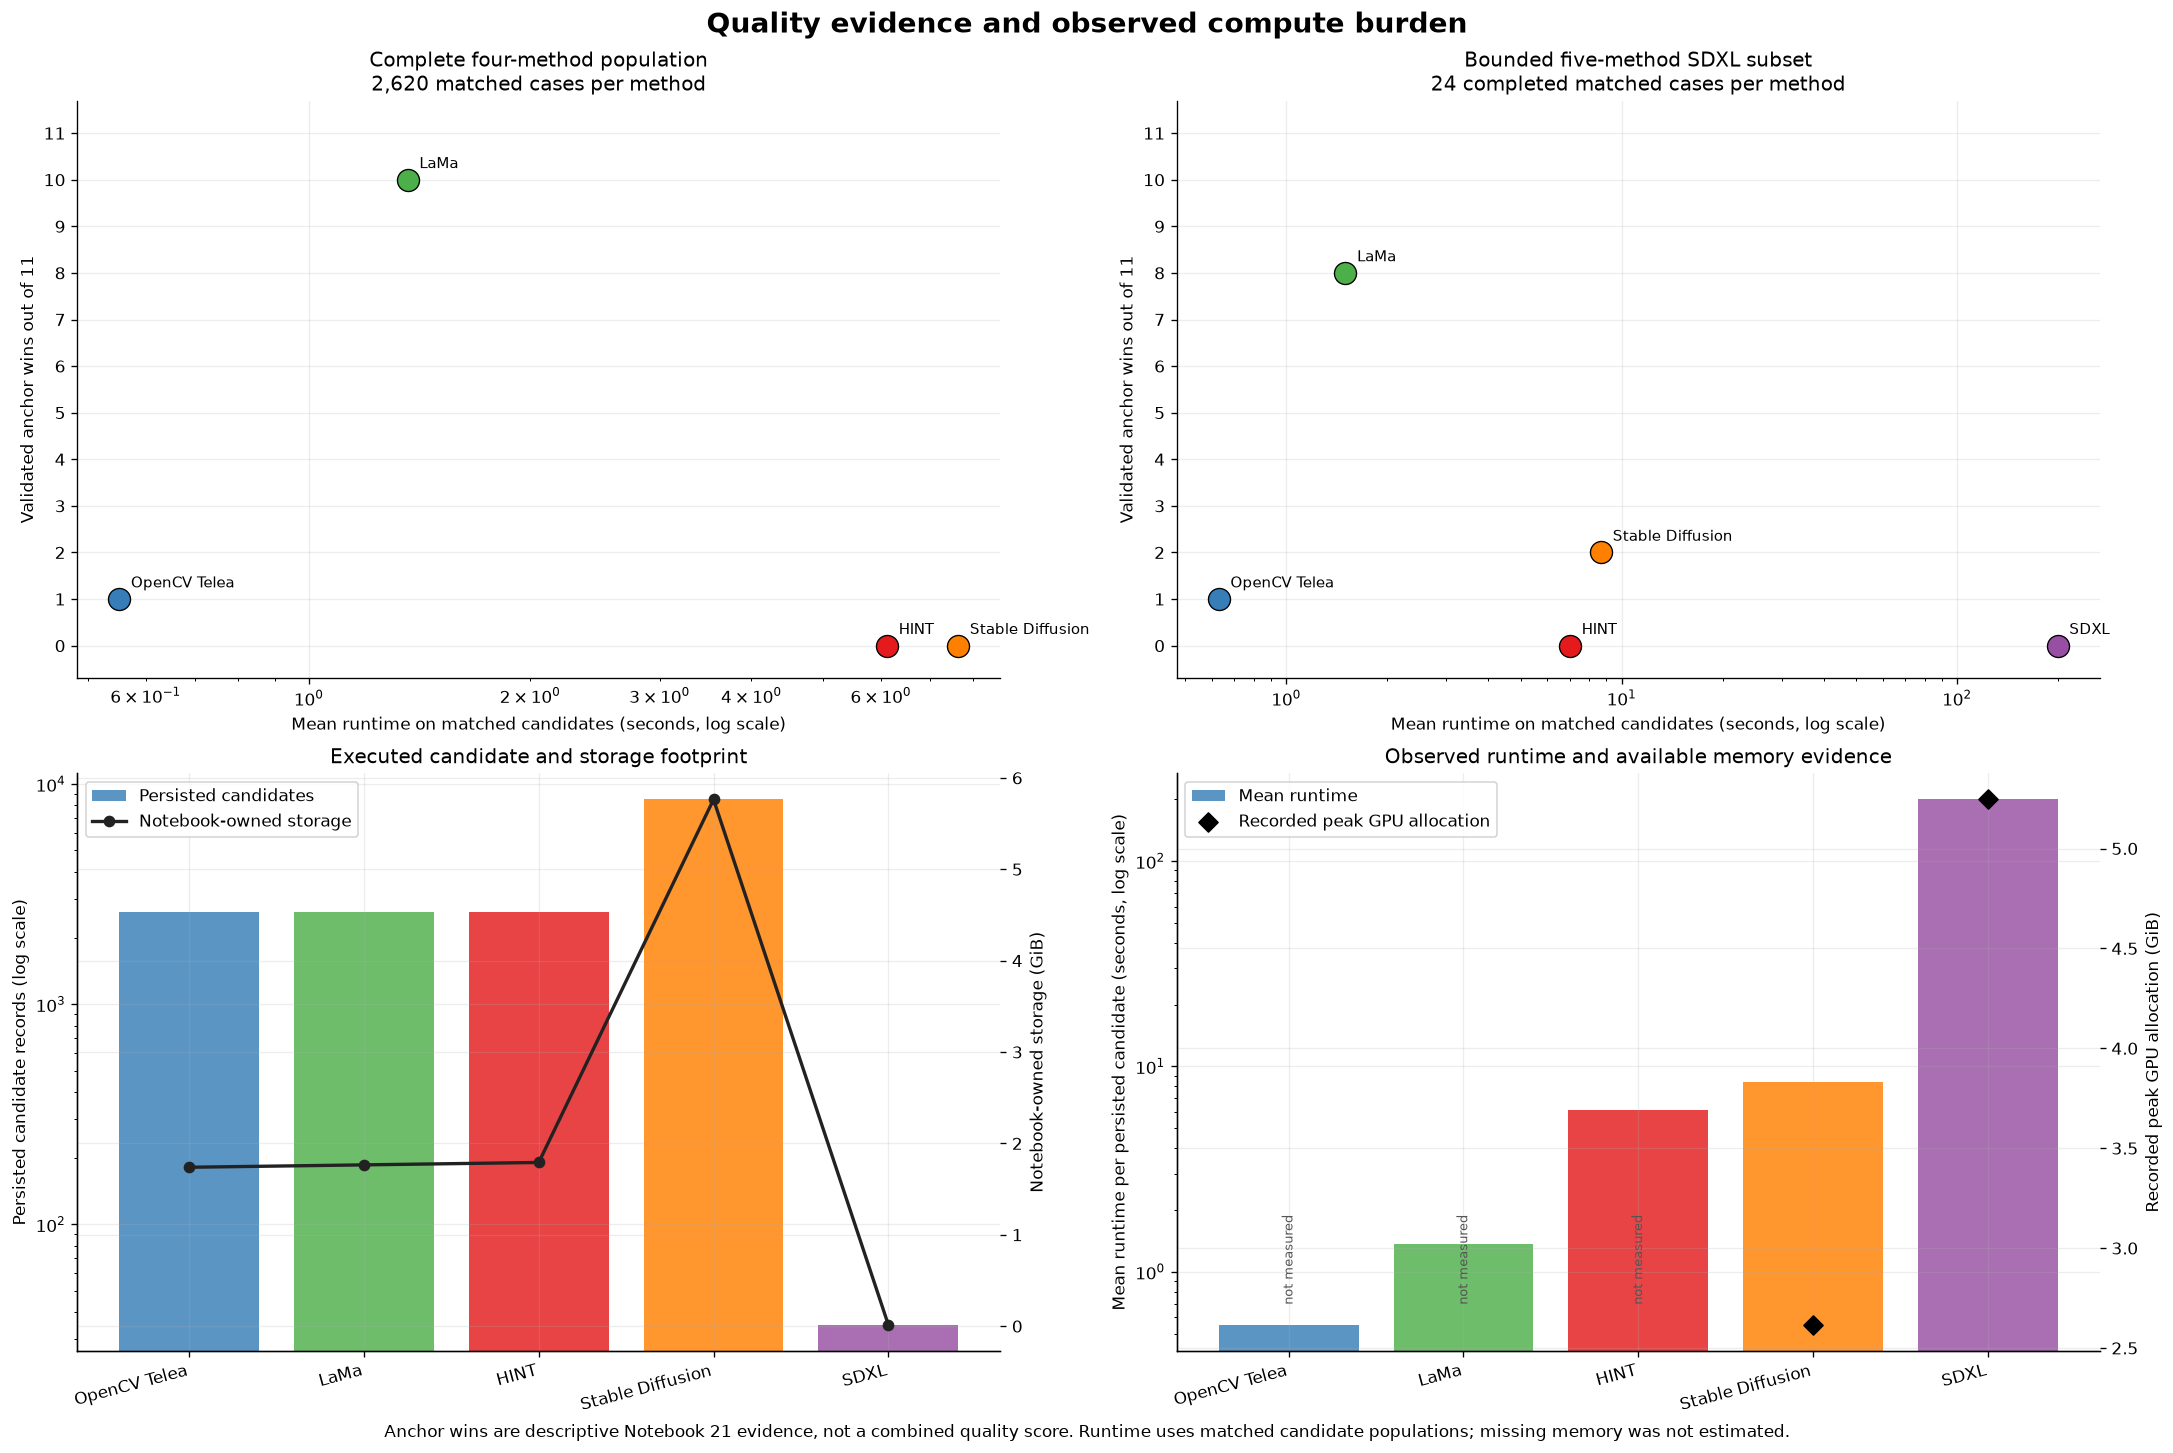

Quality-versus-compute figure generated.
Saved to: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\30_model_cards_compute_and_scalability\figures\quality_vs_compute.png


In [19]:
MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
    "sdxl_inpainting": "SDXL",
}

MODEL_COLORS = {
    "opencv_telea": "#377eb8",
    "lama": "#4daf4a",
    "hint_places2": "#e41a1c",
    "stable_diffusion_inpainting": (
        "#ff7f00"
    ),
    "sdxl_inpainting": "#984ea3",
}

MODEL_ORDER = list(
    MODEL_LABELS
)

overall_figure_compute = (
    COMPUTE_SCALABILITY.loc[
        COMPUTE_SCALABILITY[
            "record_type"
        ].eq("observed")
        & COMPUTE_SCALABILITY[
            "summary_scope"
        ].eq("overall")
        & COMPUTE_SCALABILITY[
            "experiment_id"
        ].eq("all")
    ]
    .set_index("model_id")
    .loc[MODEL_ORDER]
    .reset_index()
)

figure_1, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    constrained_layout=True,
)

population_panels = (
    (
        "core_three_model",
        (
            "Complete four-method population\n"
            "2,620 matched cases per method"
        ),
        axes[0, 0],
    ),
    (
        "sdxl_four_model_subset",
        (
            "Bounded five-method SDXL subset\n"
            "24 completed matched cases per method"
        ),
        axes[0, 1],
    ),
)

for (
    population_id,
    panel_title,
    axis,
) in population_panels:
    subset = QUALITY_COMPUTE_VIEW.loc[
        QUALITY_COMPUTE_VIEW[
            "population_id"
        ].eq(population_id)
    ].copy()

    for row in subset.to_dict(
        "records"
    ):
        model_id = row["model_id"]

        axis.scatter(
            row["mean_runtime_seconds"],
            row["anchor_win_count"],
            s=175,
            color=MODEL_COLORS[
                model_id
            ],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

        axis.annotate(
            MODEL_LABELS[model_id],
            (
                row[
                    "mean_runtime_seconds"
                ],
                row[
                    "anchor_win_count"
                ],
            ),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
        )

    axis.set_xscale("log")
    axis.set_ylim(-0.7, 11.7)
    axis.set_yticks(
        np.arange(0, 12, 1)
    )
    axis.set_xlabel(
        "Mean runtime on matched candidates "
        "(seconds, log scale)"
    )
    axis.set_ylabel(
        "Validated anchor wins out of 11"
    )
    axis.set_title(panel_title)

x_positions = np.arange(
    len(MODEL_ORDER)
)

candidate_counts = (
    overall_figure_compute
    .set_index("model_id")
    .loc[MODEL_ORDER][
        "candidate_count"
    ]
    .to_numpy(dtype=float)
)

storage_gib = (
    overall_figure_compute
    .set_index("model_id")
    .loc[MODEL_ORDER][
        "output_storage_bytes"
    ]
    .to_numpy(dtype=float)
    / (1024.0 ** 3)
)

candidate_axis = axes[1, 0]
storage_axis = candidate_axis.twinx()

candidate_axis.bar(
    x_positions,
    candidate_counts,
    color=[
        MODEL_COLORS[model_id]
        for model_id in MODEL_ORDER
    ],
    alpha=0.82,
    label="Persisted candidates",
)

storage_axis.plot(
    x_positions,
    storage_gib,
    color="#222222",
    marker="o",
    linewidth=2,
    label="Notebook-owned storage",
)

candidate_axis.set_yscale("log")
candidate_axis.set_xticks(
    x_positions,
    [
        MODEL_LABELS[model_id]
        for model_id in MODEL_ORDER
    ],
    rotation=15,
    ha="right",
)
candidate_axis.set_ylabel(
    "Persisted candidate records "
    "(log scale)"
)
storage_axis.set_ylabel(
    "Notebook-owned storage (GiB)"
)
candidate_axis.set_title(
    "Executed candidate and storage footprint"
)

candidate_handles, candidate_labels = (
    candidate_axis.get_legend_handles_labels()
)
storage_handles, storage_labels = (
    storage_axis.get_legend_handles_labels()
)

candidate_axis.legend(
    candidate_handles
    + storage_handles,
    candidate_labels
    + storage_labels,
    loc="upper left",
)

runtime_values = (
    overall_figure_compute
    .set_index("model_id")
    .loc[MODEL_ORDER][
        "mean_runtime_seconds"
    ]
    .to_numpy(dtype=float)
)

gpu_peak_gib = (
    overall_figure_compute
    .set_index("model_id")
    .loc[MODEL_ORDER][
        "gpu_peak_memory_bytes"
    ]
    .to_numpy(dtype=float)
    / (1024.0 ** 3)
)

runtime_axis = axes[1, 1]
memory_axis = runtime_axis.twinx()

runtime_axis.bar(
    x_positions,
    runtime_values,
    color=[
        MODEL_COLORS[model_id]
        for model_id in MODEL_ORDER
    ],
    alpha=0.82,
    label="Mean runtime",
)

finite_memory = np.isfinite(
    gpu_peak_gib
)

memory_axis.scatter(
    x_positions[finite_memory],
    gpu_peak_gib[finite_memory],
    color="black",
    marker="D",
    s=65,
    zorder=4,
    label="Recorded peak GPU allocation",
)

runtime_axis.set_yscale("log")
runtime_axis.set_xticks(
    x_positions,
    [
        MODEL_LABELS[model_id]
        for model_id in MODEL_ORDER
    ],
    rotation=15,
    ha="right",
)
runtime_axis.set_ylabel(
    "Mean runtime per persisted candidate "
    "(seconds, log scale)"
)
memory_axis.set_ylabel(
    "Recorded peak GPU allocation (GiB)"
)
runtime_axis.set_title(
    "Observed runtime and available "
    "memory evidence"
)

for position, model_id in enumerate(
    MODEL_ORDER
):
    if not finite_memory[position]:
        memory_axis.annotate(
            "not measured",
            (
                position,
                0.08,
            ),
            xycoords=(
                "data",
                "axes fraction",
            ),
            ha="center",
            va="bottom",
            fontsize=8,
            color="#555555",
            rotation=90,
        )

runtime_handles, runtime_labels = (
    runtime_axis.get_legend_handles_labels()
)
memory_handles, memory_labels = (
    memory_axis.get_legend_handles_labels()
)

runtime_axis.legend(
    runtime_handles
    + memory_handles,
    runtime_labels
    + memory_labels,
    loc="upper left",
)

figure_1.suptitle(
    "Quality evidence and observed compute burden",
    fontsize=17,
    fontweight="bold",
)

figure_1.supxlabel(
    (
        "Anchor wins are descriptive Notebook 21 "
        "evidence, not a combined quality score. "
        "Runtime uses matched candidate populations; "
        "missing memory was not estimated."
    ),
    fontsize=10,
)

figure_1.savefig(
    OUTPUT_PATHS[
        "quality_vs_compute_figure"
    ],
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(
    "Quality-versus-compute figure generated."
)
print(
    "Saved to: "
    f"{OUTPUT_PATHS['quality_vs_compute_figure']}"
)

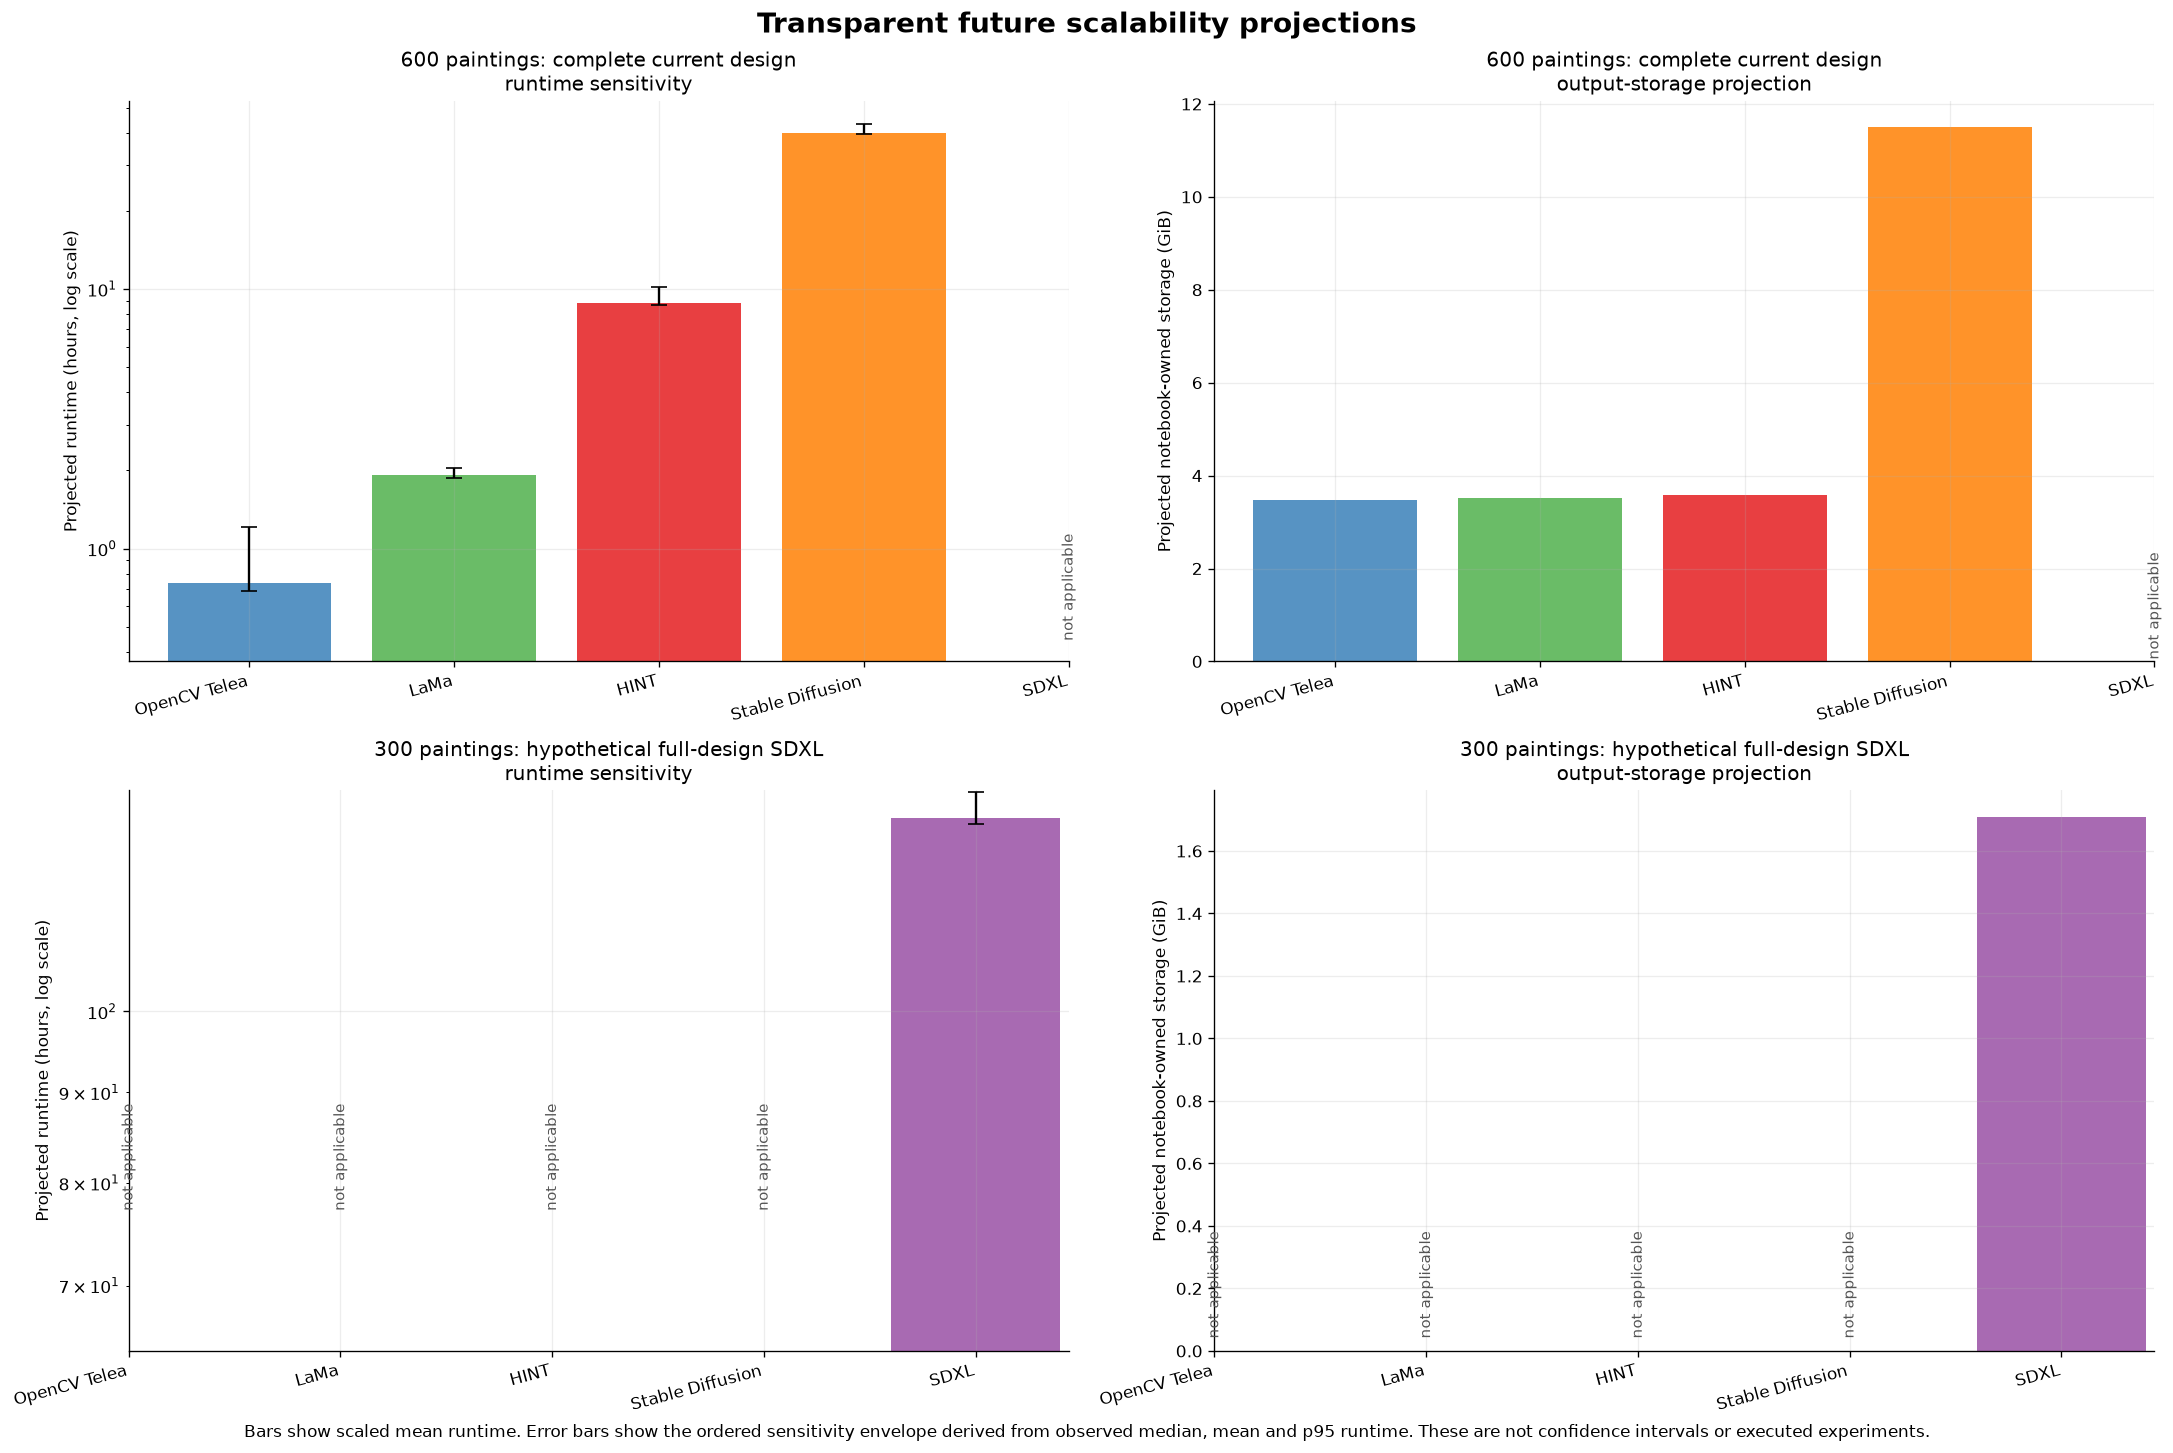

,figure_name,relative_path,exists,format,mode,width,height,size_bytes,sha256,verified
0,quality_vs_compute_figure,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,True,PNG,RGBA,3260,2180,365279,306ec5b8fa9a7a5900b44b388255c8f3f3ca3f77a01d5ffef674d77ede8ce443,True
1,scaling_projection_figure,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,True,PNG,RGBA,3260,2180,321166,7c6192e1b0534e3370a303b3942cefe7303831b1bda2b9e63238dbdee779583b,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_analysis_figures,quality_compute_population,Runtime evidence uses the exact primary candidate populations represented by each Notebook 21 quality view.,blocking,"{""core_three_model|hint_places2"": 2620, ""core_three_model|lama"": 2620, ""core_three_model|opencv_telea"": 2620, ""core_three_model|stable_diffusion_inpainting"": 2620, ""sdxl_four_m...","{""core_three_model|hint_places2"": 2620, ""core_three_model|lama"": 2620, ""core_three_model|opencv_telea"": 2620, ""core_three_model|stable_diffusion_inpainting"": 2620, ""sdxl_four_m...",True,
1,batch_6_analysis_figures,quality_compute_runtime_values,Population-matched runtime values are finite and non-negative.,blocking,True,True,True,
2,batch_6_analysis_figures,quality_compute_interpretation,Anchor wins remain descriptive and runtime is not included in a quality score.,blocking,True,"{""combined_quality_score"": false, ""completed_sdxl_cases"": 24, ""runtime_in_quality_vote"": false}",True,
3,batch_6_analysis_figures,canonical_figures,"Both canonical Notebook 30 PNG figures exist, decode successfully and have report-ready dimensions.",blocking,"{""figures"": 2, ""format"": ""PNG"", ""minimum_height"": 900, ""minimum_width"": 1600}","[{""exists"": true, ""figure_name"": ""quality_vs_compute_figure"", ""format"": ""PNG"", ""height"": 2180, ""mode"": ""RGBA"", ""relative_path"": ""outputs/30_model_cards_compute_and_scalability/...",True,


Batch 6 analysis and figures complete.
Validation checks: 4
Blocking failures: 0
Canonical figures generated: 2
Combined quality/compute score created: False
Projected rows presented as executed: False


In [20]:
from PIL import Image

scenario_order = [
    "projected_600_current_design_mix",
    "projected_300_sdxl_full_design",
]

scenario_titles = {
    "projected_600_current_design_mix": (
        "600 paintings: complete current design"
    ),
    "projected_300_sdxl_full_design": (
        "300 paintings: hypothetical full-design SDXL"
    ),
}

figure_2, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    constrained_layout=True,
)

for row_index, scenario_id in enumerate(
    scenario_order
):
    subset = (
        PROJECTION_COMPUTE.loc[
            PROJECTION_COMPUTE[
                "scenario_id"
            ].eq(scenario_id)
        ]
        .set_index("model_id")
        .loc[MODEL_ORDER]
        .reset_index()
    )

    runtime_axis = axes[
        row_index,
        0,
    ]
    storage_axis = axes[
        row_index,
        1,
    ]

    central_hours = (
        subset[
            "runtime_central_seconds"
        ].to_numpy(dtype=float)
        / 3600.0
    )

    lower_hours = (
        subset[
            "runtime_lower_seconds"
        ].to_numpy(dtype=float)
        / 3600.0
    )

    upper_hours = (
        subset[
            "runtime_upper_seconds"
        ].to_numpy(dtype=float)
        / 3600.0
    )

    runtime_applicable = np.isfinite(
        central_hours
    )

    runtime_positions = x_positions[
        runtime_applicable
    ]

    displayed_runtime_values = (
        central_hours[
            runtime_applicable
        ]
    )

    lower_error = (
        displayed_runtime_values
        - lower_hours[
            runtime_applicable
        ]
    )

    upper_error = (
        upper_hours[
            runtime_applicable
        ]
        - displayed_runtime_values
    )

    runtime_axis.bar(
        runtime_positions,
        displayed_runtime_values,
        color=[
            MODEL_COLORS[
                MODEL_ORDER[position]
            ]
            for position
            in runtime_positions
        ],
        alpha=0.84,
    )

    runtime_axis.errorbar(
        runtime_positions,
        displayed_runtime_values,
        yerr=np.vstack(
            [
                lower_error,
                upper_error,
            ]
        ),
        fmt="none",
        ecolor="black",
        elinewidth=1.4,
        capsize=5,
        zorder=4,
    )

    runtime_axis.set_yscale("log")
    runtime_axis.set_xticks(
        x_positions,
        [
            MODEL_LABELS[model_id]
            for model_id in MODEL_ORDER
        ],
        rotation=15,
        ha="right",
    )
    runtime_axis.set_ylabel(
        "Projected runtime "
        "(hours, log scale)"
    )
    runtime_axis.set_title(
        f"{scenario_titles[scenario_id]}\n"
        "runtime sensitivity"
    )

    runtime_floor = float(
        np.nanmin(
            displayed_runtime_values
        )
        / 2.0
    )

    runtime_axis.set_ylim(
        bottom=runtime_floor
    )

    for position in x_positions[
        ~runtime_applicable
    ]:
        runtime_axis.text(
            position,
            runtime_floor * 1.2,
            "not applicable",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=9,
            color="#555555",
        )

    storage_values = (
        subset[
            "projected_output_storage_bytes"
        ].to_numpy(dtype=float)
        / (1024.0 ** 3)
    )

    storage_applicable = np.isfinite(
        storage_values
    )

    storage_axis.bar(
        x_positions[
            storage_applicable
        ],
        storage_values[
            storage_applicable
        ],
        color=[
            MODEL_COLORS[
                MODEL_ORDER[position]
            ]
            for position
            in x_positions[
                storage_applicable
            ]
        ],
        alpha=0.84,
    )

    storage_axis.set_xticks(
        x_positions,
        [
            MODEL_LABELS[model_id]
            for model_id in MODEL_ORDER
        ],
        rotation=15,
        ha="right",
    )
    storage_axis.set_ylabel(
        "Projected notebook-owned storage (GiB)"
    )
    storage_axis.set_title(
        f"{scenario_titles[scenario_id]}\n"
        "output-storage projection"
    )

    for position in x_positions[
        ~storage_applicable
    ]:
        storage_axis.text(
            position,
            0.04,
            "not applicable",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=9,
            color="#555555",
        )

figure_2.suptitle(
    "Transparent future scalability projections",
    fontsize=17,
    fontweight="bold",
)

figure_2.supxlabel(
    (
        "Bars show scaled mean runtime. Error bars "
        "show the ordered sensitivity envelope "
        "derived from observed median, mean and p95 "
        "runtime. These are not confidence intervals "
        "or executed experiments."
    ),
    fontsize=10,
)

figure_2.savefig(
    OUTPUT_PATHS[
        "scaling_projection_figure"
    ],
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

FIGURE_VALIDATION_ROWS = []

for figure_name in (
    "quality_vs_compute_figure",
    "scaling_projection_figure",
):
    figure_path = OUTPUT_PATHS[
        figure_name
    ]

    with Image.open(
        figure_path
    ) as image:
        image_format = image.format
        image_mode = image.mode
        image_width = int(
            image.width
        )
        image_height = int(
            image.height
        )

        image.verify()

    FIGURE_VALIDATION_ROWS.append(
        {
            "figure_name": figure_name,
            "relative_path": (
                figure_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists": (
                figure_path.exists()
            ),
            "format": image_format,
            "mode": image_mode,
            "width": image_width,
            "height": image_height,
            "size_bytes": (
                figure_path
                .stat()
                .st_size
            ),
            "sha256": sha256_file(
                figure_path
            ),
            "verified": True,
        }
    )

FIGURE_VALIDATION = pd.DataFrame(
    FIGURE_VALIDATION_ROWS
)

figures_valid = (
    len(FIGURE_VALIDATION) == 2
    and FIGURE_VALIDATION[
        "exists"
    ].all()
    and FIGURE_VALIDATION[
        "format"
    ].eq("PNG").all()
    and FIGURE_VALIDATION[
        "width"
    ].ge(1600).all()
    and FIGURE_VALIDATION[
        "height"
    ].ge(900).all()
    and FIGURE_VALIDATION[
        "size_bytes"
    ].gt(0).all()
    and FIGURE_VALIDATION[
        "verified"
    ].all()
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="canonical_figures",
    description=(
        "Both canonical Notebook 30 PNG figures "
        "exist, decode successfully and have "
        "report-ready dimensions."
    ),
    expected={
        "figures": 2,
        "format": "PNG",
        "minimum_width": 1600,
        "minimum_height": 900,
    },
    observed=(
        FIGURE_VALIDATION
        .to_dict("records")
    ),
    passed=figures_valid,
)

display(FIGURE_VALIDATION)

BATCH_6_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_6_ROWS = (
    BATCH_6_VALIDATION.loc[
        BATCH_6_VALIDATION[
            "validation_stage"
        ].eq(BATCH_6_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_6_ROWS)

blocking_failures = int(
    (
        BATCH_6_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_6_ROWS[
            "passed"
        ]
    ).sum()
)

print(
    "Batch 6 analysis and figures complete."
)
print(
    "Validation checks: "
    f"{len(BATCH_6_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Canonical figures generated: "
    f"{len(FIGURE_VALIDATION):,}"
)
print(
    "Combined quality/compute score created: "
    "False"
)
print(
    "Projected rows presented as executed: "
    "False"
)

VALIDATION.raise_for_blocking()

## Batch 7 — Canonical persistence and standalone model cards

This batch:

- renders five standalone Markdown model cards;
- includes all eleven applicable Notebook 21 anchors in every card;
- validates the approved thirteen-section structure;
- verifies that the cards contain no image, base64 or external-file dependency;
- writes `model_cards.csv` and `compute_scalability.csv` atomically;
- writes all five Markdown cards atomically;
- reloads both canonical CSVs from disk;
- repeats schema, row-count, scope, projection and interpretation validation after reload;
- verifies exact report text, checksums, byte counts and absence of temporary files;
- verifies nine scientific output files: two CSVs, five cards and two figures;
- renders the completed Markdown cards in the notebook for human inspection.

This batch does not write the final run manifest, artifact registry or consolidated validation table.

In [21]:
BATCH_7_STAGE = "batch_7_persistence_reports"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
)

REPORT_POLICY = SETTINGS["report"]
EXPECTED = SETTINGS["expected_counts"]

RENDERED_MODEL_CARDS = {}
report_validation_parts = []

for model_row in MODEL_CARDS.to_dict(
    "records"
):
    model_id = model_row["model_id"]

    rendered_card = (
        render_model_card_markdown(
            model_row,
            COMPUTE_SCALABILITY,
            QUALITY_VALUES,
            QUALITY_WIN_SUMMARY,
            config=ANALYSIS_CONFIG,
        )
    )

    RENDERED_MODEL_CARDS[
        model_id
    ] = rendered_card

    card_checks = (
        validate_model_card_markdown(
            rendered_card,
            model_id=model_id,
            config=ANALYSIS_CONFIG,
        )
    )

    card_checks.insert(
        0,
        "model_id",
        model_id,
    )

    report_validation_parts.append(
        card_checks
    )

    for check in card_checks.itertuples(
        index=False
    ):
        add_check(
            stage=BATCH_7_STAGE,
            check_id=(
                f"report_{model_id}_"
                f"{check.check_id}"
            ),
            description=(
                f"{model_id} Markdown-card "
                f"validation: {check.check_id}."
            ),
            expected=True,
            observed=check.details,
            passed=bool(check.passed),
        )

MODEL_CARD_REPORT_CHECKS = pd.concat(
    report_validation_parts,
    ignore_index=True,
)

report_anchor_counts = {
    model_id: sum(
        rendered_card.count(
            f"| {anchor_id} |"
        )
        for anchor_id
        in QUALITY_POLICY["anchors"]
    )
    for (
        model_id,
        rendered_card,
    ) in RENDERED_MODEL_CARDS.items()
}

all_anchor_tables_complete = all(
    count
    == len(
        QUALITY_POLICY["anchors"]
    )
    for count
    in report_anchor_counts.values()
)

expected_report_count = int(
    EXPECTED[
        "model_card_report_count"
    ]
)

report_count_valid = (
    len(RENDERED_MODEL_CARDS)
    == expected_report_count
    == len(MODEL_IDS)
    == 5
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="all_report_anchor_tables",
    description=(
        "Every standalone card contains each of "
        "the eleven validated anchors exactly once."
    ),
    expected={
        "reports": expected_report_count,
        "anchors_per_report": len(
            QUALITY_POLICY["anchors"]
        ),
    },
    observed={
        "reports": len(
            RENDERED_MODEL_CARDS
        ),
        "anchors_per_report": (
            report_anchor_counts
        ),
    },
    passed=(
        report_count_valid
        and all_anchor_tables_complete
    ),
)

print(
    "Standalone model cards rendered in memory."
)
print(
    "Rendered cards: "
    f"{len(RENDERED_MODEL_CARDS):,}"
)
print(
    "Report validation checks: "
    f"{len(MODEL_CARD_REPORT_CHECKS):,}"
)
print(
    "Report validation failures: "
    f"{int((~MODEL_CARD_REPORT_CHECKS['passed']).sum()):,}"
)
print(
    "All eleven anchors retained per card: "
    f"{all_anchor_tables_complete}"
)

Standalone model cards rendered in memory.
Rendered cards: 5
Report validation checks: 50
Report validation failures: 0
All eleven anchors retained per card: True


In [22]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=(
            "invalid value encountered in cast"
        ),
        category=RuntimeWarning,
    )

    atomic_write_csv(
        MODEL_CARDS,
        OUTPUT_PATHS["model_cards"],
    )

    atomic_write_csv(
        COMPUTE_SCALABILITY,
        OUTPUT_PATHS[
            "compute_scalability"
        ],
    )

for (
    model_id,
    rendered_card,
) in RENDERED_MODEL_CARDS.items():
    atomic_write_text(
        rendered_card,
        MODEL_CARD_REPORT_PATHS[
            model_id
        ],
    )

RELOADED_MODEL_CARDS = pd.read_csv(
    OUTPUT_PATHS["model_cards"],
    low_memory=False,
)

RELOADED_COMPUTE_SCALABILITY = (
    pd.read_csv(
        OUTPUT_PATHS[
            "compute_scalability"
        ],
        low_memory=False,
    )
)

RELOADED_MODEL_CARD_CHECKS = (
    validate_model_cards(
        RELOADED_MODEL_CARDS,
        config=ANALYSIS_CONFIG,
    )
)

RELOADED_COMPUTE_CHECKS = (
    validate_compute_scalability(
        RELOADED_COMPUTE_SCALABILITY,
        config=ANALYSIS_CONFIG,
    )
)

for check in (
    RELOADED_MODEL_CARD_CHECKS.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_7_STAGE,
        check_id=(
            "reloaded_model_cards_"
            f"{check.check_id}"
        ),
        description=(
            "Reloaded model-card table validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

for check in (
    RELOADED_COMPUTE_CHECKS.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_7_STAGE,
        check_id=(
            "reloaded_compute_"
            f"{check.check_id}"
        ),
        description=(
            "Reloaded compute-table validation: "
            f"{check.check_id}."
        ),
        expected=True,
        observed=check.details,
        passed=bool(check.passed),
    )

report_file_rows = []

for (
    model_id,
    report_path,
) in MODEL_CARD_REPORT_PATHS.items():
    persisted_text = report_path.read_text(
        encoding="utf-8-sig"
    )

    expected_text = (
        RENDERED_MODEL_CARDS[
            model_id
        ]
    )

    report_file_rows.append(
        {
            "model_id": model_id,
            "relative_path": (
                report_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists": (
                report_path.exists()
            ),
            "size_bytes": (
                report_path
                .stat()
                .st_size
            ),
            "line_count": len(
                persisted_text.splitlines()
            ),
            "required_sections": sum(
                persisted_text.count(
                    f'<a id="{section_id}"></a>'
                )
                for section_id
                in REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
            "anchor_rows": sum(
                persisted_text.count(
                    f"| {anchor_id} |"
                )
                for anchor_id
                in QUALITY_POLICY["anchors"]
            ),
            "text_matches_memory": (
                persisted_text
                == expected_text
            ),
            "sha256": sha256_file(
                report_path
            ),
        }
    )

PERSISTED_REPORT_INDEX = pd.DataFrame(
    report_file_rows
)

persisted_reports_valid = (
    len(PERSISTED_REPORT_INDEX)
    == expected_report_count
    and PERSISTED_REPORT_INDEX[
        "exists"
    ].all()
    and PERSISTED_REPORT_INDEX[
        "size_bytes"
    ].gt(4000).all()
    and PERSISTED_REPORT_INDEX[
        "required_sections"
    ].eq(13).all()
    and PERSISTED_REPORT_INDEX[
        "anchor_rows"
    ].eq(11).all()
    and PERSISTED_REPORT_INDEX[
        "text_matches_memory"
    ].all()
)

temporary_files = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            path.suffix.casefold()
            == ".tmp"
            or ".tmp."
            in path.name.casefold()
            or path.name.startswith(".")
        )
    )
)

persisted_scientific_files = (
    [
        OUTPUT_PATHS[
            "model_cards"
        ],
        OUTPUT_PATHS[
            "compute_scalability"
        ],
        OUTPUT_PATHS[
            "quality_vs_compute_figure"
        ],
        OUTPUT_PATHS[
            "scaling_projection_figure"
        ],
    ]
    + list(
        MODEL_CARD_REPORT_PATHS.values()
    )
)

expected_scientific_file_count = (
    4 + expected_report_count
)

persisted_scientific_files_valid = (
    len(persisted_scientific_files)
    == expected_scientific_file_count
    and all(
        path.exists()
        and path.is_file()
        and path.stat().st_size > 0
        for path
        in persisted_scientific_files
    )
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_tables_reloaded",
    description=(
        "Both canonical CSVs reload with their "
        "exact schemas, row counts and scientific "
        "contracts."
    ),
    expected={
        "model_cards": (
            EXPECTED[
                "model_card_rows"
            ]
        ),
        "compute_rows": (
            EXPECTED[
                "compute_rows"
            ]
        ),
    },
    observed={
        "model_cards": len(
            RELOADED_MODEL_CARDS
        ),
        "compute_rows": len(
            RELOADED_COMPUTE_SCALABILITY
        ),
        "model_card_failures": int(
            (
                ~RELOADED_MODEL_CARD_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
        "compute_failures": int(
            (
                ~RELOADED_COMPUTE_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(RELOADED_MODEL_CARDS)
        == int(
            EXPECTED[
                "model_card_rows"
            ]
        )
        and len(
            RELOADED_COMPUTE_SCALABILITY
        )
        == int(
            EXPECTED[
                "compute_rows"
            ]
        )
        and RELOADED_MODEL_CARD_CHECKS[
            "passed"
        ].all()
        and RELOADED_COMPUTE_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="standalone_reports_persisted",
    description=(
        "All five Markdown cards match their "
        "validated in-memory text and retain all "
        "required sections."
    ),
    expected=True,
    observed=(
        PERSISTED_REPORT_INDEX
        .to_dict("records")
    ),
    passed=persisted_reports_valid,
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="scientific_files_persisted",
    description=(
        "The two CSVs, five cards and two figures "
        "exist as the nine scientific output files."
    ),
    expected=(
        expected_scientific_file_count
    ),
    observed=sum(
        path.exists()
        for path
        in persisted_scientific_files
    ),
    passed=(
        persisted_scientific_files_valid
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="no_temporary_files",
    description=(
        "Atomic persistence left no temporary or "
        "hidden checkpoint files in the output root."
    ),
    expected=[],
    observed=temporary_files,
    passed=not temporary_files,
)

display(PERSISTED_REPORT_INDEX)

print(
    "Canonical tables and cards persisted."
)
print(
    "Reloaded model-card rows: "
    f"{len(RELOADED_MODEL_CARDS):,}"
)
print(
    "Reloaded compute rows: "
    f"{len(RELOADED_COMPUTE_SCALABILITY):,}"
)
print(
    "Persisted scientific files: "
    f"{sum(path.exists() for path in persisted_scientific_files):,}"
    f"/{expected_scientific_file_count:,}"
)
print(
    "Temporary files: "
    f"{len(temporary_files):,}"
)

,model_id,relative_path,exists,size_bytes,line_count,required_sections,anchor_rows,text_matches_memory,sha256
0,opencv_telea,outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_telea.md,True,9408,213,13,11,True,1727f14eb235ba07767ced106078444c46bd4e7217600f5a16e09f5f889bc1cb
1,lama,outputs/30_model_cards_compute_and_scalability/reports/model_cards/lama.md,True,10342,217,13,11,True,8430d2b7a736f1ef2e844e822fdc189d39c23f561b8608b9337c7f923128f233
2,hint_places2,outputs/30_model_cards_compute_and_scalability/reports/model_cards/hint_places2.md,True,10177,213,13,11,True,ead16402cded02838731ac895c17adf162276ca1b6dccfec6d7190cf425a5fb1
3,stable_diffusion_inpainting,outputs/30_model_cards_compute_and_scalability/reports/model_cards/stable_diffusion_inpainting.md,True,11107,220,13,11,True,1696ef2aa0d73242207546d84a64a4d52b3c8475c4d4449769bd774316826a8d
4,sdxl_inpainting,outputs/30_model_cards_compute_and_scalability/reports/model_cards/sdxl_inpainting.md,True,10370,215,13,11,True,37483fb0d3da73613570cf5f46236a59a191abf75c5b583d704ceb2f5f787de5


Canonical tables and cards persisted.
Reloaded model-card rows: 5
Reloaded compute rows: 42
Persisted scientific files: 9/9
Temporary files: 0


In [23]:
BATCH_7_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_7_ROWS = (
    BATCH_7_VALIDATION.loc[
        BATCH_7_VALIDATION[
            "validation_stage"
        ].eq(BATCH_7_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_7_ROWS)

blocking_failures = int(
    (
        BATCH_7_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_7_ROWS[
            "passed"
        ]
    ).sum()
)

print(
    "Batch 7 persistence and report "
    "validation complete."
)
print(
    "Validation checks: "
    f"{len(BATCH_7_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Standalone Markdown cards: "
    f"{len(PERSISTED_REPORT_INDEX):,}"
)
print(
    "Required sections per card: "
    f"{PERSISTED_REPORT_INDEX['required_sections'].tolist()}"
)
print(
    "Quality anchors per card: "
    f"{PERSISTED_REPORT_INDEX['anchor_rows'].tolist()}"
)

VALIDATION.raise_for_blocking()

for model_id in MODEL_IDS:
    display(
        Markdown(
            RENDERED_MODEL_CARDS[
                model_id
            ]
        )
    )

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_persistence_reports,report_opencv_telea_report_nonempty,opencv_telea Markdown-card validation: report_nonempty.,blocking,True,bytes=9408,True,
1,batch_7_persistence_reports,report_opencv_telea_model_id_present,opencv_telea Markdown-card validation: model_id_present.,blocking,True,opencv_telea,True,
2,batch_7_persistence_reports,report_opencv_telea_required_sections,opencv_telea Markdown-card validation: required_sections.,blocking,True,required=13,True,
3,batch_7_persistence_reports,report_opencv_telea_section_order,opencv_telea Markdown-card validation: section_order.,blocking,True,approved mock order,True,
4,batch_7_persistence_reports,report_opencv_telea_no_image_dependencies,opencv_telea Markdown-card validation: no_image_dependencies.,blocking,True,image_tokens=0,True,
...,...,...,...,...,...,...,...,...
76,batch_7_persistence_reports,reloaded_compute_executed_controlled_300,Reloaded compute-table validation: executed_controlled_300.,blocking,True,five observed controlled-300 summaries,True,
77,batch_7_persistence_reports,canonical_tables_reloaded,"Both canonical CSVs reload with their exact schemas, row counts and scientific contracts.",blocking,"{""compute_rows"": 42, ""model_cards"": 5}","{""compute_failures"": 0, ""compute_rows"": 42, ""model_card_failures"": 0, ""model_cards"": 5}",True,
78,batch_7_persistence_reports,standalone_reports_persisted,All five Markdown cards match their validated in-memory text and retain all required sections.,blocking,True,"[{""anchor_rows"": 11, ""exists"": true, ""line_count"": 213, ""model_id"": ""opencv_telea"", ""relative_path"": ""outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_...",True,
79,batch_7_persistence_reports,scientific_files_persisted,"The two CSVs, five cards and two figures exist as the nine scientific output files.",blocking,9,9,True,


Batch 7 persistence and report validation complete.
Validation checks: 81
Blocking failures: 0
Standalone Markdown cards: 5
Required sections per card: [13, 13, 13, 13, 13]
Quality anchors per card: [11, 11, 11, 11, 11]


# OpenCV Telea - Model Card and Compute Audit

**Evaluation status:** Fully Evaluated  
**Method role:** classical deterministic baseline  
**Dataset scope:** controlled_300  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

OpenCV Telea was the fastest and most reproducible baseline, while its local interpolation remained limited for semantically demanding missing regions.

- Completed candidates: **2,620 of 2,620**.
- Mean runtime: **0.55 seconds per candidate**.
- Observed notebook-owned storage: **1.74 GiB**.
- Validated anchor wins in the applicable population: **1 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `opencv_telea` |
| Family | classical fast marching inpainting |
| Original purpose | Local image inpainting from the boundary of a masked region. |
| Project implementation | OpenCV cv2.INPAINT_TELEA |
| Implementation version | 4.11.0 |
| Model identifier | `cv2.INPAINT_TELEA` |
| Model revision | `opencv-4.11.0` |
| Software licence | Apache-2.0 |
| Weight licence | not_applicable_no_model_weights |

OpenCV software licence; the Telea method has no learned weights.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- classical deterministic restoration baseline
- small local damage and thin-scratch comparison
- reproducible candidate generation for controlled evaluation

Unsupported uses:

- historically verified reconstruction
- semantic reconstruction of large missing structures
- conservation approval

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

Not applicable; this is a classical non-learning algorithm.

**Training-data transparency status:** not applicable

**Domain gap:** No painting-specific knowledge, semantic model, or brushwork model.

**Bias and risk:** No learned training-data bias; locality and interpolation assumptions remain algorithmic biases.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `opencv_telea_r3_threshold_policy_v1` |
| Device | cpu |
| Backend | opencv_cpu |
| Recorded accelerator | not applicable (CPU execution) |
| Precision | uint8 |
| Inference resolution | 768 x 768 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB uint8 painting input; identity zero controls bypass inference. |
| Mask constraints | Single-channel binary missing-region mask using threshold 128; fixed Telea radius 3; no per-case tuning. |
| Deterministic | True |
| Prompt dependent | False |
| Hardware statement | CPU execution; no GPU required under the evaluated contract. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 300 |
| Unique cases | 2,620 |
| Candidates | 2,620 |
| Model-inference candidates | 2,320 |
| Identity zero controls | 300 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 24.1 minutes |
| Mean runtime | 0.552 s |
| Median runtime | 0.519 s |
| p95 runtime | 0.925 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 1.8110 candidates/second |
| Candidate multiplier | 1.0000 candidates per evaluated case |
| Recorded peak GPU allocation | not applicable |
| Recorded total GPU memory | not applicable |
| Output files | 2,626 |
| Output storage | 1.74 GiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `core_three_model` (2620 cases nested within 300 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 17.575 | 2 | lama |
| colour_masked_delta_e | 7.7657 | 2 | lama |
| feature_clip_crop | 0.88181 | 4 | lama |
| feature_dino_crop | 0.68702 | 4 | lama |
| perceptual_crop_lpips | 0.20066 | 4 | lama |
| seam_boundary_gradient | 0.0082864 | 2 | lama |
| semantic_local_dino | 0.59121 | 4 | lama |
| spatial_masked_error | 17.575 | 2 | lama |
| structural_affinity_correlation | 0.81834 | 4 | lama |
| structural_crop_ssim | 0.86323 | 1 | opencv_telea |
| texture_crop_p95 | 0.62469 | 2 | lama |

The method won 1 of 11 validated anchors in this population. Its strongest displayed anchor was `structural_crop_ssim`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

OpenCV Telea is deterministic. Its appropriate reliability evidence is input robustness and sensitivity, not generative uncertainty.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_600_current_design_mix | 5,240 | 44.1 minutes | 3.47 GiB |
| projected_300_sdxl_full_design | not applicable | not applicable | not applicable to this model-specific projection scenario |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. The controlled 300-painting study was executed; only rows explicitly labelled as projections are extrapolations.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- fast and deterministic
- transparent classical baseline
- low compute burden

Weaknesses:

- no semantic understanding
- limited large-mask reconstruction
- local interpolation may lose meaningful structure

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The controlled 300-painting values are executed observations; only the explicitly labelled 600-painting and full-design SDXL values are projections.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL scheduled 35 bounded cases across 30 paintings; 24 completed, one timed out and ten were skipped under the declared budget, so it cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- OpenCV Telea is a local interpolation baseline and does not reconstruct historically verified content.
- A fixed radius of 3 is used without per-case tuning.
- Eligible synthetic-degradation cases are supplementary masked-removal diagnostics and must remain separate from missing-content claims.
- Runtime measurements describe the recorded CPU environment and are not universal benchmarks.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 09 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://docs.opencv.org/4.x/d7/d8b/group__photo__inpaint.html
- https://github.com/opencv/opencv

### Final scoped verdict

OpenCV Telea was the fastest and most reproducible baseline, while its local interpolation remained limited for semantically demanding missing regions. This conclusion remains limited to the controlled evidence and the recorded compute environment.


# LaMa - Model Card and Compute Audit

**Evaluation status:** Fully Evaluated  
**Method role:** learned deterministic inpainting baseline  
**Dataset scope:** controlled_300  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

LaMa provided the strongest broad reference-based baseline under the validated full-scope anchor policy.

- Completed candidates: **2,620 of 2,620**.
- Mean runtime: **1.36 seconds per candidate**.
- Observed notebook-owned storage: **1.76 GiB**.
- Validated anchor wins in the applicable population: **10 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `lama` |
| Family | learned fourier convolution inpainting |
| Original purpose | Resolution-robust large-mask image inpainting using Fourier convolutions. |
| Project implementation | IOPaint CLI model=lama |
| Implementation version | 1.6.0 |
| Model identifier | `big-lama.pt` |
| Model revision | `iopaint_lama_default` |
| Software licence | Apache-2.0_method_and_runtime_code |
| Weight licence | not_separately_verified_in_project_sources |

The LaMa and IOPaint code are Apache-2.0; the downloaded Big-LaMa weight artifact is not assigned a separate project-verified licence claim.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- learned large-mask inpainting baseline
- controlled digital restoration candidate generation
- quality and robustness comparison against classical and diffusion methods

Unsupported uses:

- historically verified reconstruction
- artist authentication or semantic brushstroke recognition
- conservation approval

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

Official LaMa documentation describes Places365/Places-based training; the exact IOPaint-converted checkpoint-to-training-run mapping is not independently verified here.

**Training-data transparency status:** partial

**Domain gap:** General-scene inpainting training does not establish painting-specific or conservation-specific competence.

**Bias and risk:** Learned priors may smooth texture or synthesize plausible but unsupported structures.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `lama_iopaint_masked_composite_v1` |
| Device | cuda |
| Backend | iopaint |
| Recorded accelerator | NVIDIA GeForce RTX 3060 Laptop GPU |
| Precision | float32 |
| Inference resolution | 768 x 768 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB painting input passed through the pinned IOPaint LaMa runtime; identity zero controls bypass inference. |
| Mask constraints | Single-channel binary missing-region mask using threshold 128; exact outside-mask compositing; no per-case tuning. |
| Deterministic | True |
| Prompt dependent | False |
| Hardware statement | Executed with CUDA on the recorded RTX 3060 Laptop GPU; no experimentally validated minimum VRAM threshold is claimed. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 300 |
| Unique cases | 2,620 |
| Candidates | 2,620 |
| Model-inference candidates | 2,320 |
| Identity zero controls | 300 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 59.5 minutes |
| Mean runtime | 1.363 s |
| Median runtime | 1.451 s |
| p95 runtime | 1.586 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 0.7338 candidates/second |
| Candidate multiplier | 1.0000 candidates per evaluated case |
| Recorded peak GPU allocation | not applicable |
| Recorded total GPU memory | not applicable |
| Output files | 2,626 |
| Output storage | 1.76 GiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `core_three_model` (2620 cases nested within 300 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 14.83 | 1 | lama |
| colour_masked_delta_e | 6.8834 | 1 | lama |
| feature_clip_crop | 0.95714 | 1 | lama |
| feature_dino_crop | 0.87116 | 1 | lama |
| perceptual_crop_lpips | 0.12915 | 1 | lama |
| seam_boundary_gradient | 0.007027 | 1 | lama |
| semantic_local_dino | 0.8008 | 1 | lama |
| spatial_masked_error | 14.83 | 1 | lama |
| structural_affinity_correlation | 0.9424 | 1 | lama |
| structural_crop_ssim | 0.8577 | 2 | opencv_telea |
| texture_crop_p95 | 0.41157 | 1 | lama |

The method won 10 of 11 validated anchors in this population. Its strongest displayed anchor was `classical_masked_mae`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

LaMa is deterministic under the evaluated contract. Mask robustness and damage sensitivity are the relevant reliability constructs; repeated-seed generative uncertainty is not applicable.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_600_current_design_mix | 5,240 | 115.4 minutes | 3.52 GiB |
| projected_300_sdxl_full_design | not applicable | not applicable | not applicable to this model-specific projection scenario |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. The controlled 300-painting study was executed; only rows explicitly labelled as projections are extrapolations.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- broad learned context
- practical large-mask baseline
- deterministic under the evaluated contract

Weaknesses:

- general-scene rather than painting-specific training
- possible texture smoothing
- plausible content may remain historically incorrect

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The controlled 300-painting values are executed observations; only the explicitly labelled 600-painting and full-design SDXL values are projections.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL scheduled 35 bounded cases across 30 paintings; 24 completed, one timed out and ten were skipped under the declared budget, so it cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- LaMa produces plausible learned inpainting, not historically verified reconstruction.
- IOPaint batch execution exposes group wall-clock runtime; per-case inference runtimes are transparently allocated estimates.
- The fixed model and mask policies are not tuned per painting or per damage case.
- Eligible synthetic-degradation cases are supplementary masked-removal diagnostics and remain separate from missing-content claims.
- Exact model-weight provenance depends on the locally resolved IOPaint cache artifact and is recorded when discoverable.
- CUDA inference is evaluated for tightly bounded numerical repeatability rather than byte-identical output; the configured smoke tolerance permits at most one 8-bit channel level of deviation while outside-mask invariance remains exact.
- Runtime measurements describe the recorded hardware and software environment and are not universal benchmarks.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 10 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://github.com/advimman/lama
- https://github.com/Sanster/IOPaint/blob/main/iopaint/model/lama.py
- https://github.com/Sanster/IOPaint

### Final scoped verdict

LaMa provided the strongest broad reference-based baseline under the validated full-scope anchor policy. This conclusion remains limited to the controlled evidence and the recorded compute environment.


# HINT - Model Card and Compute Audit

**Evaluation status:** Fully Evaluated  
**Method role:** learned deterministic mask aware transformer  
**Dataset scope:** controlled_300  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

HINT added a deterministic mask-aware transformer family with complete controlled-300 coverage, extending the learned comparison beyond LaMa's convolutional design.

- Completed candidates: **2,620 of 2,620**.
- Mean runtime: **6.12 seconds per candidate**.
- Observed notebook-owned storage: **1.79 GiB**.
- Validated anchor wins in the applicable population: **0 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `hint_places2` |
| Family | learned mask aware transformer inpainting |
| Original purpose | High-fidelity image inpainting using mask-aware transformer features and a learned general-scene prior. |
| Project implementation | Official HINT generator loaded directly |
| Implementation version | 15e867d8c8689b9d5050383fc3884537ae876145 |
| Model identifier | `hint_places2_official` |
| Model revision | `15e867d8c8689b9d5050383fc3884537ae876145` |
| Software licence | MIT |
| Weight licence | not_separately_verified_in_project_sources |

The official repository software is MIT licensed; the Places2 checkpoint terms are recorded separately and are not silently equated with the software licence.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- deterministic structure-aware learned inpainting comparison
- controlled digital restoration candidate generation
- full-scope comparison with classical, convolutional and diffusion methods

Unsupported uses:

- historically verified reconstruction
- artist authentication or conservation approval
- calibrated uncertainty estimation

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

The selected official checkpoint is the Places2 variant. Places2 is general-scene data rather than painting-conservation data.

**Training-data transparency status:** partial

**Domain gap:** Places2 training does not establish painting-specific, art-historical or conservation-specific competence.

**Bias and risk:** Learned scene priors may impose unsupported structure, texture or cultural regularities despite deterministic execution.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `hint_places2_native_768_exact_composite_v1` |
| Device | cuda |
| Backend | official_hint_direct |
| Recorded accelerator | NVIDIA GeForce RTX 3060 Laptop GPU |
| Precision | float32 |
| Inference resolution | 768 x 768 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB painting input passed through the official HINT generator; identity zero controls bypass inference. |
| Mask constraints | Single-channel binary missing-region mask under the approved HINT threshold policy; native 768 inference; exact outside-mask compositing; no per-case tuning. |
| Deterministic | True |
| Prompt dependent | False |
| Hardware statement | Executed in float32 on the recorded RTX 3060 Laptop GPU; the project does not claim a universal minimum VRAM threshold. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 300 |
| Unique cases | 2,620 |
| Candidates | 2,620 |
| Model-inference candidates | 2,320 |
| Identity zero controls | 300 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 4.5 hours |
| Mean runtime | 6.117 s |
| Median runtime | 6.677 s |
| p95 runtime | 7.851 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 0.1635 candidates/second |
| Candidate multiplier | 1.0000 candidates per evaluated case |
| Recorded peak GPU allocation | not applicable |
| Recorded total GPU memory | not applicable |
| Output files | 2,626 |
| Output storage | 1.79 GiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `core_three_model` (2620 cases nested within 300 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 19.155 | 3 | lama |
| colour_masked_delta_e | 8.961 | 3 | lama |
| feature_clip_crop | 0.9257 | 3 | lama |
| feature_dino_crop | 0.81558 | 3 | lama |
| perceptual_crop_lpips | 0.17476 | 2 | lama |
| seam_boundary_gradient | 0.0092329 | 3 | lama |
| semantic_local_dino | 0.7132 | 2 | lama |
| spatial_masked_error | 19.155 | 3 | lama |
| structural_affinity_correlation | 0.90167 | 2 | lama |
| structural_crop_ssim | 0.8168 | 3 | opencv_telea |
| texture_crop_p95 | 1.2739 | 3 | lama |

The method won 0 of 11 validated anchors in this population. Its strongest displayed anchor was `perceptual_crop_lpips`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

HINT is deterministic under the evaluated fixed-checkpoint contract. Robustness and sensitivity are the relevant reliability constructs; repeated-seed generative uncertainty is not applicable.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_600_current_design_mix | 5,240 | 8.8 hours | 3.57 GiB |
| projected_300_sdxl_full_design | not applicable | not applicable | not applicable to this model-specific projection scenario |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. The controlled 300-painting study was executed; only rows explicitly labelled as projections are extrapolations.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- deterministic learned transformer family distinct from LaMa
- native 768 x 768 execution under the validated adapter
- full controlled-300 coverage

Weaknesses:

- general-scene rather than painting-specific training
- no prompt or repeated-seed uncertainty mechanism
- plausible structure may remain historically unsupported

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The controlled 300-painting values are executed observations; only the explicitly labelled 600-painting and full-design SDXL values are projections.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL scheduled 35 bounded cases across 30 paintings; 24 completed, one timed out and ten were skipped under the declared budget, so it cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- HINT was trained on Places2 rather than conservation-restoration paintings.
- A plausible completion is not evidence of historical authenticity or conservation suitability.
- The deterministic run measures one fixed checkpoint and configuration, not model-family uncertainty.
- Eligible synthetic-degradation cases are supplementary masked-removal diagnostics.
- Runtime measurements describe the recorded local hardware and are not universal benchmarks.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 12A |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://github.com/ChrisChen1023/HINT

### Final scoped verdict

HINT added a deterministic mask-aware transformer family with complete controlled-300 coverage, extending the learned comparison beyond LaMa's convolutional design. This conclusion remains limited to the controlled evidence and the recorded compute environment.


# Stable Diffusion Inpainting - Model Card and Compute Audit

**Evaluation status:** Fully Evaluated  
**Method role:** prompt conditioned stochastic inpainting baseline  
**Dataset scope:** controlled_300  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

Stable Diffusion added prompt-conditioned and repeated-seed evidence, but required far more candidates and did not lead the full-scope reference-based anchor comparison.

- Completed candidates: **8,520 of 8,520**.
- Mean runtime: **8.42 seconds per candidate**.
- Observed notebook-owned storage: **5.76 GiB**.
- Validated anchor wins in the applicable population: **0 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `stable_diffusion_inpainting` |
| Family | prompt conditioned latent diffusion inpainting |
| Original purpose | Text-conditioned image generation and masked image modification. |
| Project implementation | Diffusers StableDiffusionInpaintPipeline |
| Implementation version | 1.1.0 |
| Model identifier | `stable-diffusion-v1-5/stable-diffusion-inpainting` |
| Model revision | `8a4288a76071f7280aedbdb3253bdb9e9d5d84bb` |
| Software licence | CreativeML-OpenRAIL-M |
| Weight licence | CreativeML-OpenRAIL-M |

The pinned Hugging Face model card declares CreativeML OpenRAIL-M.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- prompt-conditioned generative inpainting baseline
- repeated-seed variability analysis
- controlled prompt-sensitivity analysis for thin scratches

Unsupported uses:

- historically verified reconstruction
- calibrated confidence estimation
- unreviewed conservation decisions

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

Stable Diffusion v1 lineage uses LAION-derived data; the inpainting checkpoint was further trained at 512x512 on LAION Aesthetics v2 5+ with synthetic masks.

**Training-data transparency status:** documented but not fully auditable

**Domain gap:** Web-scale and natural-image priors are not painting-conservation training.

**Bias and risk:** Prompt, language, web-data, cultural, memorization, hallucination, and lossy-autoencoder risks apply.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `sd15_inpaint_fixed_policy_v1` |
| Device | cuda |
| Backend | diffusers_stable_diffusion_inpaint |
| Recorded accelerator | NVIDIA GeForce RTX 3060 Laptop GPU |
| Precision | float16 |
| Inference resolution | 512 x 512 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB painting input resized to 512 x 512 for inference and returned to 768 x 768 for persistence. |
| Mask constraints | Single-channel missing-region mask using threshold 128; exact outside-mask compositing; empty masks copied; fixed generic or approved scratch-aware prompt policy. |
| Deterministic | False |
| Prompt dependent | True |
| Hardware statement | Executed in float16 on the recorded RTX 3060 Laptop GPU; observed peak allocation is reported without claiming a universal minimum. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 300 |
| Unique cases | 2,620 |
| Candidates | 8,520 |
| Model-inference candidates | 8,220 |
| Identity zero controls | 300 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 19.9 hours |
| Mean runtime | 8.420 s |
| Median runtime | 8.620 s |
| p95 runtime | 9.476 s |
| Failed candidates | 0 |
| Failure rate | 0.00% |
| Retries | 0 |
| Throughput | 0.1188 candidates/second |
| Candidate multiplier | 3.2519 candidates per evaluated case |
| Recorded peak GPU allocation | 2.62 GiB |
| Recorded total GPU memory | not applicable |
| Output files | 8,530 |
| Output storage | 5.76 GiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `core_three_model` (2620 cases nested within 300 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 30.606 | 4 | lama |
| colour_masked_delta_e | 13.267 | 4 | lama |
| feature_clip_crop | 0.94232 | 2 | lama |
| feature_dino_crop | 0.83309 | 2 | lama |
| perceptual_crop_lpips | 0.19717 | 3 | lama |
| seam_boundary_gradient | 0.02085 | 4 | lama |
| semantic_local_dino | 0.66544 | 3 | lama |
| spatial_masked_error | 30.606 | 4 | lama |
| structural_affinity_correlation | 0.85096 | 3 | lama |
| structural_crop_ssim | 0.81233 | 4 | opencv_telea |
| texture_crop_p95 | 2.1169 | 4 | lama |

The method won 0 of 11 validated anchors in this population. Its strongest displayed anchor was `feature_clip_crop`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

Stable Diffusion is stochastic. Repeated seeds measure empirical candidate variability, and the scratch-aware arm measures damage-specific prompt sensitivity; neither is calibrated confidence.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_600_current_design_mix | 17,040 | 39.8 hours | 11.50 GiB |
| projected_300_sdxl_full_design | not applicable | not applicable | not applicable to this model-specific projection scenario |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. The controlled 300-painting study was executed; only rows explicitly labelled as projections are extrapolations.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- prompt-conditioned generative completion
- seed-controllable stochastic candidates
- supports empirical variability analysis

Weaknesses:

- high hallucination and prompt-sensitivity risk
- higher compute and candidate multiplier
- thin-mask geometry can remain visible after compositing

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The controlled 300-painting values are executed observations; only the explicitly labelled 600-painting and full-design SDXL values are projections.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL scheduled 35 bounded cases across 30 paintings; 24 completed, one timed out and ten were skipped under the declared budget, so it cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- Stable Diffusion produces plausible prompt-conditioned inpainting, not historically verified reconstruction.
- The generic primary prompt and fixed inference settings are intentionally not tuned per painting or damage case.
- Contextual prompts form a controlled ablation and are not used to select primary candidates.
- Repeated seeds characterize stochastic sensitivity for a fixed predeclared subset and are not metric-selected.
- Eligible synthetic-degradation cases are supplementary masked-removal diagnostics and remain separate from missing-content claims.
- CUDA inference may not be byte-identical across hardware or software stacks; the complete environment is recorded.
- The safety checker is disabled for this fixed research dataset and that policy is explicitly recorded.
- The scratch-aware prompt is a controlled semantic-conditioning treatment and does not change the model, mask, seed, scheduler, inference resolution, compositing policy, or any other generation setting.
- Thin scratch masks can lose or fragment spatial support during 512-pixel and latent-grid downsampling; prompting cannot be assumed to resolve that geometric limitation.
- Literal scratch terminology is concentrated in the negative prompt because text encoders may not reliably interpret negation in positive prompts.
- The 1,200 painting-seed pairs are repeated observations nested within 300 paintings; downstream inference must not treat all seed-level pairs as independent paintings.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 11 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-inpainting
- https://arxiv.org/abs/2112.10752

### Final scoped verdict

Stable Diffusion added prompt-conditioned and repeated-seed evidence, but required far more candidates and did not lead the full-scope reference-based anchor comparison. This conclusion remains limited to the controlled evidence and the recorded compute environment.


# SDXL Inpainting - Model Card and Compute Audit

**Evaluation status:** Partial Evaluation  
**Method role:** bounded higher capacity diffusion candidate  
**Dataset scope:** controlled_300  
**Decision boundary:** Digital restoration candidate method, not a conservation authority

<a id="at-a-glance"></a>
## 1. At a glance

SDXL completed 24 of 35 scheduled cases in a bounded partial evaluation, providing local feasibility and cost evidence without supporting a full-dataset ranking.

- Completed candidates: **24 of 35**.
- Mean runtime: **199.52 seconds per candidate**.
- Observed notebook-owned storage: **16.19 MiB**.
- Validated anchor wins in the applicable population: **0 of 11**.

**Conclusion:** The compute and quality evidence support this method only within its declared evaluation scope. Anchor wins are descriptive Notebook 21 outcomes, not a combined quality score or conservation verdict.

<a id="identity-and-provenance"></a>
## 2. Identity and provenance

| Field | Recorded value |
|---|---|
| Model ID | `sdxl_inpainting` |
| Family | prompt conditioned sdxl latent diffusion inpainting |
| Original purpose | Higher-capacity text-conditioned image generation and masked image modification. |
| Project implementation | Diffusers StableDiffusionXLInpaintPipeline |
| Implementation version | 3.1.0 |
| Model identifier | `diffusers/stable-diffusion-xl-1.0-inpainting-0.1` |
| Model revision | `115134f363124c53c7d878647567d04daf26e41e` |
| Software licence | CreativeML-OpenRAIL++-M |
| Weight licence | CreativeML-OpenRAIL++-M |

The pinned Hugging Face model card declares CreativeML Open RAIL++-M.

<a id="intended-and-unsupported-use"></a>
## 3. Intended and unsupported use

Appropriate project uses:

- bounded partial comparison
- local compute and memory feasibility evidence
- transparent SDXL scaling projection

Unsupported uses:

- full controlled-dataset ranking
- universal comparison against the three full-scope methods
- historically verified reconstruction or conservation approval

<a id="training-data-and-domain-gap"></a>
## 4. Training data and painting-domain gap

The inpainting checkpoint was initialized from SDXL base and trained for 40k steps at 1024x1024 with synthetic masks; the pinned inpainting card does not provide a complete independently auditable training corpus inventory.

**Training-data transparency status:** partial

**Domain gap:** The higher-capacity generative model remains non-conservation-specific and only partially evaluated here.

**Bias and risk:** Generative, prompt, cultural, hallucination, compositional, face, and lossy-autoencoder limitations remain.

**Conclusion:** Source transparency and general-image performance do not establish painting-specific historical or conservation competence.

<a id="project-implementation"></a>
## 5. Project implementation

| Setting | Recorded value |
|---|---|
| Configuration | `sdxl_quality_preserving_partial_evaluation_v1` |
| Device | cuda |
| Backend | recorded in upstream manifest |
| Recorded accelerator | NVIDIA GeForce RTX 3060 Laptop GPU |
| Precision | float16 |
| Inference resolution | 768 x 768 |
| Output resolution | 768 x 768 |
| Input constraints | Normalized 768 x 768 RGB painting input in the predeclared 35-case bounded scope across 30 paintings. |
| Mask constraints | Single-channel case-semantic missing-region mask using threshold 128; exact outside-mask compositing; no empty-mask controls in the partial evaluation. |
| Deterministic | False |
| Prompt dependent | True |
| Hardware statement | Ten cases completed with model CPU offload on the recorded 6 GB RTX 3060 Laptop GPU; this does not establish a universal minimum-VRAM requirement. |

The project used a fixed predeclared configuration and exact outside-mask compositing policy where applicable. Per-case metric-guided tuning was not used.

<a id="evaluated-evidence-coverage"></a>
## 6. Evaluated evidence coverage

| Coverage field | Recorded count |
|---|---:|
| Paintings | 30 |
| Unique cases | 35 |
| Candidates | 35 |
| Model-inference candidates | 35 |
| Identity zero controls | 0 |

Cases and repeated candidates remain nested within paintings. Candidate rows are not treated as independent artworks.

<a id="compute-and-storage"></a>
## 7. Compute and storage

| Measure | Observed result |
|---|---:|
| Total runtime | 79.8 minutes |
| Mean runtime | 199.519 s |
| Median runtime | 198.031 s |
| p95 runtime | 206.559 s |
| Failed candidates | 11 |
| Failure rate | 31.43% |
| Retries | 0 |
| Throughput | 0.0050 candidates/second |
| Candidate multiplier | 1.0000 candidates per evaluated case |
| Recorded peak GPU allocation | 5.25 GiB |
| Recorded total GPU memory | 6.00 GiB |
| Output files | 30 |
| Output storage | 16.19 MiB |

**Conclusion:** These measurements describe the recorded workstation and software environment. They are project evidence, not universal hardware benchmarks.

<a id="quality-evidence"></a>
## 8. Quality evidence

Applicable population: `sdxl_four_model_subset` (24 cases nested within 19 paintings).

| Validated anchor | Restored mean | Rank | Winner |
|---|---:|---:|---|
| classical_masked_mae | 72.627 | 5 | lama |
| colour_masked_delta_e | 29.611 | 5 | lama |
| feature_clip_crop | 0.86598 | 4 | stable_diffusion_inpainting |
| feature_dino_crop | 0.77602 | 3 | stable_diffusion_inpainting |
| perceptual_crop_lpips | 0.31078 | 5 | lama |
| seam_boundary_gradient | 0.046617 | 5 | lama |
| semantic_local_dino | 0.51293 | 5 | lama |
| spatial_masked_error | 72.627 | 5 | lama |
| structural_affinity_correlation | 0.67215 | 5 | lama |
| structural_crop_ssim | 0.75834 | 5 | opencv_telea |
| texture_crop_p95 | 3.5998 | 5 | lama |

The method won 0 of 11 validated anchors in this population. Its strongest displayed anchor was `feature_dino_crop`.

**Conclusion:** Better or worse language applies only to the named anchor and population. Runtime is not included in the quality vote, and the anchor count is not a universal quality score.

<a id="determinism-robustness-and-uncertainty"></a>
## 9. Determinism, robustness, and uncertainty

SDXL has one seed per completed case. Generative uncertainty is therefore not estimable from this scope, and no artificial uncertainty value is assigned.

Low variability or deterministic repetition does not prove that a reconstructed region is correct.

<a id="scalability"></a>
## 10. Scalability

| Scenario | Candidate outputs | Central runtime projection | Output-storage projection |
|---|---:|---:|---:|
| projected_600_current_design_mix | not applicable | not applicable | not applicable to this model-specific projection scenario |
| projected_300_sdxl_full_design | 2,620 | 128.6 hours | 1.71 GiB |

Raw observed median, mean, and p95 runtimes are retained in the compute table. The displayed sensitivity envelope uses the smaller of scaled median and mean as its lower value, scaled mean as its central value, and the larger of scaled p95 and mean as its upper value. These are not confidence intervals. The controlled 300-painting study was executed; only rows explicitly labelled as projections are extrapolations.

<a id="strengths-and-weaknesses"></a>
## 11. Strengths and weaknesses

Strengths:

- higher-capacity diffusion lineage
- technically valid 768px partial outputs
- direct local feasibility evidence

Weaknesses:

- only 35 purposively selected cases, of which 24 completed
- very high runtime on recorded hardware
- no repeated-seed uncertainty coverage

Known project limitations:

- Runtime and memory observations describe one recorded local workstation and software environment.
- The controlled 300-painting values are executed observations; only the explicitly labelled 600-painting and full-design SDXL values are projections.
- Projected storage covers notebook-owned output artifacts and excludes model caches, environments, Git history, and downstream metric outputs.
- SDXL scheduled 35 bounded cases across 30 paintings; 24 completed, one timed out and ten were skipped under the declared budget, so it cannot support a full-scope ranking.
- LaMa per-case runtime includes transparent allocation from IOPaint batch wall-clock measurements.
- Quality-anchor wins are descriptive validated Notebook 21 evidence, not a universal quality or conservation score.
- The 35 cases are a predeclared balanced purposive scope and do not represent a full SDXL evaluation.
- The 35 case observations span 30 paintings; repeated cases from five retained pilot anchors are nested observations.
- A timeout or CUDA out-of-memory failure is hardware/runtime evidence and must not be interpreted as poor restoration quality.
- Only technically validated completed candidates may enter downstream metric computation.
- The global seven-hour budget can leave later scheduled cases explicitly unexecuted.
- SDXL outputs are plausible prompt-conditioned inpaintings, not historically verified reconstructions or conservation recommendations.

<a id="human-decision-support-interpretation"></a>
## 12. Human decision-support interpretation

The method can generate and prioritize digital candidates for structured inspection. Reviewers should examine repaired structure, local texture, colour continuity, seams, uncertainty where applicable, and disagreements between evidence families.

**Decision statement:** This card supports transparent method selection and review planning. It does not approve physical treatment, establish historical truth, or replace expert conservation judgement.

<a id="reproducibility-and-provenance"></a>
## 13. Reproducibility and provenance

| Field | Recorded value |
|---|---|
| Producer notebook | `30_model_cards_compute_and_scalability.ipynb` |
| Candidate producer | Notebook 12 |
| Quality producer | Notebook 21 |
| Compute schema | `compute_scalability.v1` |
| Model-card schema | `model_cards.v1` |
| Source review date | 2026-09-02T00:00:00Z |

Primary and runtime sources:

- https://huggingface.co/diffusers/stable-diffusion-xl-1.0-inpainting-0.1
- https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0

### Final scoped verdict

SDXL completed 24 of 35 scheduled cases in a bounded partial evaluation, providing local feasibility and cost evidence without supporting a full-dataset ranking. This conclusion remains limited to the controlled evidence and the recorded compute environment.


## Batch 8 — Final manifests, roadmap traceability, and completion gate

This batch:

- consolidates all Notebook 30 validation evidence;
- verifies thirteen roadmap responsibilities against the executed Controlled-300 evidence;
- distinguishes the 32 observed compute rows from ten explicitly projected rows;
- verifies the 600-painting current-design and 300-painting full-design SDXL scenarios;
- registers six canonical artifact groups;
- writes the validation table, artifact manifest and run manifest;
- updates the global project-path registry;
- verifies the exact twelve-file physical output contract;
- reloads and independently verifies every final table, report, figure, checksum and registry record.

The completion gate does not treat projections as executed experiments, runtime as a universal benchmark, anchor wins as a combined quality score, SDXL as fully evaluated, uncertainty as calibrated confidence or any method card as conservation approval.

In [24]:
BATCH_8_STAGE = "batch_8_final_traceability"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8_STAGE,
)


def boolean_series(
    series: pd.Series,
) -> pd.Series:
    """Normalize persisted boolean-like values."""
    return (
        series.fillna(False)
        .astype(str)
        .str.strip()
        .str.casefold()
        .isin(
            {
                "true",
                "1",
                "1.0",
                "yes",
                "y",
            }
        )
    )


def nonempty_columns(
    frame: pd.DataFrame,
    columns: list[str],
) -> bool:
    """Check required textual disclosures."""
    return bool(
        frame[columns]
        .fillna("")
        .astype(str)
        .apply(
            lambda column: (
                column.str.strip().ne("")
            )
        )
        .all()
        .all()
    )


def numeric_columns_valid(
    frame: pd.DataFrame,
    columns: list[str],
    *,
    strictly_positive: bool = False,
) -> bool:
    """Validate finite numeric fields."""
    values = frame[columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    if not values.notna().all().all():
        return False

    if not np.isfinite(
        values.to_numpy(dtype=float)
    ).all():
        return False

    if strictly_positive:
        return bool(
            values.gt(0).all().all()
        )

    return bool(
        values.ge(0).all().all()
    )


def optional_integer(value):
    """Convert a projected count while preserving NA."""
    if pd.isna(value):
        return None

    return int(value)


final_model_card_checks = (
    validate_model_cards(
        RELOADED_MODEL_CARDS,
        config=ANALYSIS_CONFIG,
    )
)

final_compute_checks = (
    validate_compute_scalability(
        RELOADED_COMPUTE_SCALABILITY,
        config=ANALYSIS_CONFIG,
    )
)

final_report_check_parts = []

for (
    model_id,
    report_path,
) in MODEL_CARD_REPORT_PATHS.items():
    report_text = report_path.read_text(
        encoding="utf-8-sig"
    )

    report_checks = (
        validate_model_card_markdown(
            report_text,
            model_id=model_id,
            config=ANALYSIS_CONFIG,
        )
    )

    report_checks.insert(
        0,
        "model_id",
        model_id,
    )

    final_report_check_parts.append(
        report_checks
    )

FINAL_REPORT_CHECKS = pd.concat(
    final_report_check_parts,
    ignore_index=True,
)

identity_columns = [
    "display_name",
    "evaluation_status",
    "model_family",
    "methodological_role",
    "original_purpose",
    "implementation",
    "implementation_version",
    "model_identifier",
    "model_revision",
    "configuration_id",
    "software_license",
    "weight_license",
    "license_scope_note",
    "training_data_description",
    "training_data_transparency",
    "source_ids_json",
    "source_urls_json",
]

scope_columns = [
    "intended_uses_json",
    "excluded_uses_json",
    "input_constraints",
    "mask_constraints",
    "domain_gap",
    "bias_notes",
    "known_limitations_json",
    "strengths_json",
    "weaknesses_json",
    "hardware_requirements",
]

hardware_columns = [
    "implementation",
    "model_identifier",
    "observed_hardware_json",
    "execution_device",
    "precision",
]

identity_valid = nonempty_columns(
    RELOADED_MODEL_CARDS,
    identity_columns,
)

scope_valid = nonempty_columns(
    RELOADED_MODEL_CARDS,
    scope_columns,
)

hardware_valid = nonempty_columns(
    RELOADED_MODEL_CARDS,
    hardware_columns,
)

expected_statuses = {
    "opencv_telea": "fully_evaluated",
    "lama": "fully_evaluated",
    "hint_places2": "fully_evaluated",
    "stable_diffusion_inpainting": (
        "fully_evaluated"
    ),
    "sdxl_inpainting": "partial_evaluation",
}

observed_statuses = dict(
    zip(
        RELOADED_MODEL_CARDS[
            "model_id"
        ].astype(str),
        RELOADED_MODEL_CARDS[
            "evaluation_status"
        ].astype(str),
    )
)

expected_candidates = {
    "opencv_telea": 2620,
    "lama": 2620,
    "hint_places2": 2620,
    "stable_diffusion_inpainting": 8520,
    "sdxl_inpainting": 35,
}

observed_candidates = dict(
    zip(
        RELOADED_MODEL_CARDS[
            "model_id"
        ].astype(str),
        RELOADED_MODEL_CARDS[
            "evaluated_candidate_count"
        ].astype(int),
    )
)

expected_failures = {
    "opencv_telea": 0,
    "lama": 0,
    "hint_places2": 0,
    "stable_diffusion_inpainting": 0,
    "sdxl_inpainting": 11,
}

observed_failures = dict(
    zip(
        RELOADED_MODEL_CARDS[
            "model_id"
        ].astype(str),
        RELOADED_MODEL_CARDS[
            "failed_count"
        ].astype(int),
    )
)

observed_compute_rows = (
    RELOADED_COMPUTE_SCALABILITY.loc[
        RELOADED_COMPUTE_SCALABILITY[
            "record_type"
        ].eq("observed")
    ]
    .copy()
)

projection_rows = (
    RELOADED_COMPUTE_SCALABILITY.loc[
        RELOADED_COMPUTE_SCALABILITY[
            "record_type"
        ].eq("projection")
    ]
    .copy()
)

applicable_projection_rows = (
    projection_rows.loc[
        projection_rows[
            "applicability_status"
        ].eq("applicable_projection")
    ]
    .copy()
)

overall_compute_rows = (
    observed_compute_rows.loc[
        observed_compute_rows[
            "scenario_id"
        ].eq("observed_overall_all")
    ]
    .copy()
)

observed_flags_valid = bool(
    len(observed_compute_rows)
    == int(
        EXPECTED[
            "observed_compute_rows"
        ]
    )
    and boolean_series(
        observed_compute_rows[
            "is_executed"
        ]
    ).all()
    and not boolean_series(
        observed_compute_rows[
            "is_projected"
        ]
    ).any()
    and observed_compute_rows[
        "dataset_scope"
    ].eq("controlled_300").all()
)

projection_flags_valid = bool(
    len(projection_rows)
    == int(
        EXPECTED[
            "projection_rows"
        ]
    )
    and not boolean_series(
        projection_rows[
            "is_executed"
        ]
    ).any()
    and boolean_series(
        projection_rows[
            "is_projected"
        ]
    ).all()
    and not boolean_series(
        projection_rows[
            "sensitivity_is_confidence_interval"
        ]
    ).any()
)

model_runtime_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "throughput_candidates_per_second",
]

model_geometry_columns = [
    "inference_width",
    "inference_height",
    "output_width",
    "output_height",
]

model_population_columns = [
    "evaluated_painting_count",
    "evaluated_case_count",
    "evaluated_candidate_count",
    "model_inference_count",
    "zero_control_count",
    "completed_count",
]

model_output_columns = [
    "output_file_count",
    "output_storage_bytes",
    "restored_image_file_count",
    "restored_image_storage_bytes",
]

overall_compute_columns = [
    "output_file_count",
    "output_storage_bytes",
    "candidate_multiplier",
]

runtime_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_runtime_columns,
    strictly_positive=True,
)

geometry_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_geometry_columns,
    strictly_positive=True,
)

population_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_population_columns,
)

output_summary_valid = numeric_columns_valid(
    RELOADED_MODEL_CARDS,
    model_output_columns,
    strictly_positive=True,
)

overall_compute_valid = bool(
    len(overall_compute_rows) == 5
    and numeric_columns_valid(
        overall_compute_rows,
        overall_compute_columns,
        strictly_positive=True,
    )
)

failure_values = (
    RELOADED_MODEL_CARDS[
        [
            "failed_count",
            "retry_count",
            "failure_rate",
        ]
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )
)

failure_evidence_valid = bool(
    failure_values.notna().all().all()
    and failure_values.ge(0).all().all()
    and observed_failures
    == expected_failures
    and RELOADED_MODEL_CARDS[
        "status"
    ].eq("ok").all()
)

operational_metrics_valid = bool(
    runtime_valid
    and geometry_valid
    and population_valid
    and output_summary_valid
    and overall_compute_valid
    and failure_evidence_valid
    and hardware_valid
)

projection_lower = pd.to_numeric(
    applicable_projection_rows[
        "runtime_lower_seconds"
    ],
    errors="coerce",
)

projection_central = pd.to_numeric(
    applicable_projection_rows[
        "runtime_central_seconds"
    ],
    errors="coerce",
)

projection_upper = pd.to_numeric(
    applicable_projection_rows[
        "runtime_upper_seconds"
    ],
    errors="coerce",
)

projection_bounds_valid = bool(
    len(applicable_projection_rows) == 5
    and projection_lower.notna().all()
    and projection_central.notna().all()
    and projection_upper.notna().all()
    and projection_lower.le(
        projection_central
    ).all()
    and projection_central.le(
        projection_upper
    ).all()
)

scenario_target_views = {}

for (
    scenario_id,
    scenario,
) in SCENARIOS.items():
    scenario_rows = (
        projection_rows.loc[
            projection_rows[
                "scenario_id"
            ].eq(scenario_id)
        ]
        .copy()
    )

    scenario_target_views[
        scenario_id
    ] = {
        row.model_id: {
            "cases": optional_integer(
                row.case_count
            ),
            "candidates": optional_integer(
                row.candidate_count
            ),
            "inference": optional_integer(
                row.inference_count
            ),
            "zero_controls": optional_integer(
                row.zero_control_count
            ),
            "applicability": str(
                row.applicability_status
            ),
        }
        for row in scenario_rows.itertuples(
            index=False
        )
    }

expected_scenario_target_views = {}

for (
    scenario_id,
    scenario,
) in SCENARIOS.items():
    expected_scenario_target_views[
        scenario_id
    ] = {
        model_id: {
            "cases": (
                scenario[
                    "target_case_count"
                ][model_id]
            ),
            "candidates": (
                scenario[
                    "target_candidates"
                ][model_id]
            ),
            "inference": (
                scenario[
                    "target_inference_candidates"
                ][model_id]
            ),
            "zero_controls": (
                scenario[
                    "target_zero_controls"
                ][model_id]
            ),
            "applicability": (
                "applicable_projection"
                if scenario[
                    "target_candidates"
                ][model_id]
                is not None
                else (
                    "not_applicable_"
                    "no_full_design_basis"
                )
            ),
        }
        for model_id in MODEL_IDS
    }

projection_scenarios_valid = (
    scenario_target_views
    == expected_scenario_target_views
)

quality_evidence_valid = bool(
    QUALITY_VALUES[
        "anchor_id"
    ].nunique()
    == len(
        QUALITY_POLICY["anchors"]
    )
    and QUALITY_VALUES[
        "population_id"
    ].nunique()
    == len(
        QUALITY_POLICY["populations"]
    )
    and len(
        QUALITY_WIN_SUMMARY
    ) == 9
    and not QUALITY_POLICY[
        "combined_quality_score_retained"
    ]
    and not QUALITY_POLICY[
        "runtime_in_quality_vote"
    ]
)

report_contract_valid = bool(
    len(FINAL_REPORT_CHECKS) == 50
    and FINAL_REPORT_CHECKS[
        "passed"
    ].astype(bool).all()
    and len(
        PERSISTED_REPORT_INDEX
    ) == 5
    and PERSISTED_REPORT_INDEX[
        "required_sections"
    ].eq(13).all()
    and PERSISTED_REPORT_INDEX[
        "anchor_rows"
    ].eq(11).all()
)

figure_rows = []

for figure_name in (
    "quality_vs_compute_figure",
    "scaling_projection_figure",
):
    figure_path = OUTPUT_PATHS[
        figure_name
    ]

    figure_array = plt.imread(
        figure_path
    )

    figure_rows.append(
        {
            "figure_name": figure_name,
            "relative_path": (
                figure_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "height": int(
                figure_array.shape[0]
            ),
            "width": int(
                figure_array.shape[1]
            ),
            "channels": (
                int(
                    figure_array.shape[2]
                )
                if figure_array.ndim == 3
                else 1
            ),
            "size_bytes": int(
                figure_path
                .stat()
                .st_size
            ),
            "sha256": sha256_file(
                figure_path
            ),
        }
    )

FINAL_FIGURE_INDEX = pd.DataFrame(
    figure_rows
)

figures_valid = bool(
    len(FINAL_FIGURE_INDEX) == 2
    and FINAL_FIGURE_INDEX[
        "width"
    ].ge(1600).all()
    and FINAL_FIGURE_INDEX[
        "height"
    ].ge(900).all()
    and FINAL_FIGURE_INDEX[
        "size_bytes"
    ].gt(50_000).all()
)

scientific_paths = [
    OUTPUT_PATHS["model_cards"],
    OUTPUT_PATHS[
        "compute_scalability"
    ],
    *MODEL_CARD_REPORT_PATHS.values(),
    OUTPUT_PATHS[
        "quality_vs_compute_figure"
    ],
    OUTPUT_PATHS[
        "scaling_projection_figure"
    ],
]

temporary_files_before_manifests = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            ".tmp"
            in path.name.casefold()
            or ".building"
            in path.name.casefold()
            or path.suffix.casefold()
            in {
                ".temp",
                ".part",
                ".partial",
            }
            or path.name.startswith(".")
        )
    )
)

claim_restrictions_observed = {
    key: bool(value)
    for key, value
    in EVIDENCE_POLICY.items()
}

claim_boundaries_valid = not any(
    claim_restrictions_observed.values()
)

scientific_files_valid = bool(
    len(scientific_paths) == 9
    and all(
        path.exists()
        and path.is_file()
        and path.stat().st_size > 0
        for path in scientific_paths
    )
    and not temporary_files_before_manifests
)

traceability_rows = []


def add_traceability_row(
    responsibility_id: str,
    responsibility: str,
    expected,
    observed,
    passed: bool,
    evidence: str,
) -> None:
    traceability_rows.append(
        {
            "responsibility_id": (
                responsibility_id
            ),
            "responsibility": responsibility,
            "expected": expected,
            "observed": observed,
            "passed": bool(passed),
            "evidence": evidence,
        }
    )


add_traceability_row(
    "model_identity_and_provenance",
    (
        "Exact method identity, versions, "
        "licences, training disclosure and provenance"
    ),
    "five complete records",
    {
        "rows": len(
            RELOADED_MODEL_CARDS
        ),
        "identity_valid": identity_valid,
    },
    (
        len(RELOADED_MODEL_CARDS) == 5
        and identity_valid
    ),
    (
        "data/model_cards.csv and five "
        "standalone Markdown cards"
    ),
)

add_traceability_row(
    "method_scope_and_constraints",
    (
        "Intended use, unsupported use, constraints, "
        "domain gap, strengths and limitations"
    ),
    True,
    scope_valid,
    scope_valid,
    "model-card scope fields",
)

add_traceability_row(
    "evaluation_status_and_population",
    (
        "Evaluation statuses and candidate counts "
        "remain tied to executed populations"
    ),
    {
        "statuses": expected_statuses,
        "candidates": expected_candidates,
        "failures": expected_failures,
    },
    {
        "statuses": observed_statuses,
        "candidates": observed_candidates,
        "failures": observed_failures,
    },
    (
        observed_statuses
        == expected_statuses
        and observed_candidates
        == expected_candidates
        and observed_failures
        == expected_failures
    ),
    (
        "four full evaluations and one "
        "bounded partial SDXL evaluation"
    ),
)

add_traceability_row(
    "observed_compute",
    (
        "Observed runtime evidence remains "
        "separate from projections"
    ),
    {
        "rows": 32,
        "executed": True,
        "projected": False,
    },
    {
        "rows": len(
            observed_compute_rows
        ),
        "valid": observed_flags_valid,
    },
    observed_flags_valid,
    "32 upstream runtime-summary rows",
)

add_traceability_row(
    "operational_metrics",
    (
        "Runtime, throughput, failures, retries, "
        "geometry, hardware, storage, files and "
        "candidate multipliers"
    ),
    {
        "model_rows": 5,
        "overall_compute_rows": 5,
        "sdxl_noncompletions": 11,
    },
    {
        "runtime_valid": runtime_valid,
        "geometry_valid": geometry_valid,
        "population_valid": population_valid,
        "output_summary_valid": (
            output_summary_valid
        ),
        "overall_compute_valid": (
            overall_compute_valid
        ),
        "failure_evidence_valid": (
            failure_evidence_valid
        ),
        "hardware_valid": hardware_valid,
    },
    operational_metrics_valid,
    (
        "model-level cards and five "
        "observed-overall compute rows"
    ),
)

add_traceability_row(
    "projection_transparency",
    (
        "Projections are labelled, bounded and not "
        "presented as execution or confidence intervals"
    ),
    {
        "rows": 10,
        "applicable": 5,
    },
    {
        "rows": len(
            projection_rows
        ),
        "applicable": len(
            applicable_projection_rows
        ),
        "flags_valid": (
            projection_flags_valid
        ),
        "bounds_valid": (
            projection_bounds_valid
        ),
    },
    (
        projection_flags_valid
        and projection_bounds_valid
    ),
    "transparent runtime-sensitivity envelopes",
)

add_traceability_row(
    "projected_600_current_design",
    (
        "The 600-painting projection doubles the "
        "complete executed design for four methods"
    ),
    expected_scenario_target_views[
        "projected_600_current_design_mix"
    ],
    scenario_target_views[
        "projected_600_current_design_mix"
    ],
    projection_scenarios_valid,
    (
        "SDXL remains explicitly not applicable "
        "to this complete-design scaling scenario"
    ),
)

add_traceability_row(
    "projected_300_sdxl_full_design",
    (
        "The bounded SDXL evidence is transparently "
        "projected to the 300-painting full design"
    ),
    expected_scenario_target_views[
        "projected_300_sdxl_full_design"
    ],
    scenario_target_views[
        "projected_300_sdxl_full_design"
    ],
    projection_scenarios_valid,
    (
        "2,620 candidate records, including 2,320 "
        "inference cases and 300 identity controls"
    ),
)

add_traceability_row(
    "quality_compute_context",
    (
        "Quality-versus-compute retains eleven "
        "separate anchors and population-matched runtime"
    ),
    {
        "anchors": 11,
        "populations": 2,
        "summary_rows": 9,
        "combined_score": False,
    },
    {
        "anchors": (
            QUALITY_VALUES[
                "anchor_id"
            ].nunique()
        ),
        "populations": (
            QUALITY_VALUES[
                "population_id"
            ].nunique()
        ),
        "summary_rows": len(
            QUALITY_WIN_SUMMARY
        ),
    },
    quality_evidence_valid,
    "anchor wins remain descriptive",
)

add_traceability_row(
    "standalone_model_cards",
    (
        "Five Markdown cards retain the approved "
        "structure and quality-anchor tables"
    ),
    {
        "cards": 5,
        "sections": 13,
        "anchors": 11,
    },
    {
        "cards": len(
            PERSISTED_REPORT_INDEX
        ),
        "checks": len(
            FINAL_REPORT_CHECKS
        ),
    },
    report_contract_valid,
    "reports/model_cards/",
)

add_traceability_row(
    "canonical_figures",
    (
        "Both analytical figures are readable "
        "canonical PNG files"
    ),
    2,
    FINAL_FIGURE_INDEX[
        [
            "figure_name",
            "width",
            "height",
            "size_bytes",
        ]
    ].to_dict("records"),
    figures_valid,
    (
        "quality-versus-compute and "
        "scaling-projection figures"
    ),
)

add_traceability_row(
    "claim_boundaries",
    (
        "Interpretation restrictions remain enforced"
    ),
    {
        key: False
        for key
        in claim_restrictions_observed
    },
    claim_restrictions_observed,
    claim_boundaries_valid,
    "configuration evidence policy",
)

add_traceability_row(
    "canonical_scientific_files",
    (
        "All nine scientific outputs exist before "
        "control files are written"
    ),
    9,
    sum(
        path.exists()
        and path.is_file()
        and path.stat().st_size > 0
        for path in scientific_paths
    ),
    scientific_files_valid,
    (
        "two CSVs, five cards and two figures"
    ),
)

ROADMAP_TRACEABILITY = pd.DataFrame(
    traceability_rows
)

for roadmap_row in (
    ROADMAP_TRACEABILITY.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_8_STAGE,
        check_id=(
            "roadmap_"
            f"{roadmap_row.responsibility_id}"
        ),
        description=(
            roadmap_row.responsibility
        ),
        expected=roadmap_row.expected,
        observed=roadmap_row.observed,
        passed=bool(
            roadmap_row.passed
        ),
    )

all_scientific_contracts_passed = bool(
    final_model_card_checks[
        "passed"
    ].astype(bool).all()
    and final_compute_checks[
        "passed"
    ].astype(bool).all()
    and FINAL_REPORT_CHECKS[
        "passed"
    ].astype(bool).all()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="all_scientific_contracts",
    description=(
        "Reloaded tables and reports pass their "
        "helper-level contracts."
    ),
    expected=True,
    observed={
        "model_card_failures": int(
            (
                ~final_model_card_checks[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "compute_failures": int(
            (
                ~final_compute_checks[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "report_failures": int(
            (
                ~FINAL_REPORT_CHECKS[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
    },
    passed=(
        all_scientific_contracts_passed
    ),
)

validation_rows_before_count_check = len(
    VALIDATION.to_dataframe()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="minimum_validation_density",
    description=(
        "Notebook 30 retains at least the "
        "configured validation count."
    ),
    expected=EXPECTED[
        "minimum_validation_rows"
    ],
    observed=(
        validation_rows_before_count_check
        + 1
    ),
    passed=(
        validation_rows_before_count_check
        + 1
        >= EXPECTED[
            "minimum_validation_rows"
        ]
    ),
)

BATCH_8_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_8_ROWS = (
    BATCH_8_VALIDATION.loc[
        BATCH_8_VALIDATION[
            "validation_stage"
        ].eq(BATCH_8_STAGE)
    ]
    .reset_index(drop=True)
)

display(ROADMAP_TRACEABILITY)
display(FINAL_FIGURE_INDEX)
display(BATCH_8_ROWS)

print(
    "Final scientific traceability assembled."
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Batch 8 validation checks: "
    f"{len(BATCH_8_ROWS):,}"
)
print(
    "Total validation checks: "
    f"{len(BATCH_8_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{len(VALIDATION.blocking_failures):,}"
)

VALIDATION.raise_for_blocking()

,responsibility_id,responsibility,expected,observed,passed,evidence
0,model_identity_and_provenance,"Exact method identity, versions, licences, training disclosure and provenance",five complete records,"{'rows': 5, 'identity_valid': True}",True,data/model_cards.csv and five standalone Markdown cards
1,method_scope_and_constraints,"Intended use, unsupported use, constraints, domain gap, strengths and limitations",True,True,True,model-card scope fields
2,evaluation_status_and_population,Evaluation statuses and candidate counts remain tied to executed populations,"{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'hint_places2': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpaintin...","{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'hint_places2': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpaintin...",True,four full evaluations and one bounded partial SDXL evaluation
3,observed_compute,Observed runtime evidence remains separate from projections,"{'rows': 32, 'executed': True, 'projected': False}","{'rows': 32, 'valid': True}",True,32 upstream runtime-summary rows
4,operational_metrics,"Runtime, throughput, failures, retries, geometry, hardware, storage, files and candidate multipliers","{'model_rows': 5, 'overall_compute_rows': 5, 'sdxl_noncompletions': 11}","{'runtime_valid': True, 'geometry_valid': True, 'population_valid': True, 'output_summary_valid': True, 'overall_compute_valid': True, 'failure_evidence_valid': True, 'hardware...",True,model-level cards and five observed-overall compute rows
5,projection_transparency,"Projections are labelled, bounded and not presented as execution or confidence intervals","{'rows': 10, 'applicable': 5}","{'rows': 10, 'applicable': 5, 'flags_valid': True, 'bounds_valid': True}",True,transparent runtime-sensitivity envelopes
6,projected_600_current_design,The 600-painting projection doubles the complete executed design for four methods,"{'opencv_telea': {'cases': 5240, 'candidates': 5240, 'inference': 4640, 'zero_controls': 600, 'applicability': 'applicable_projection'}, 'lama': {'cases': 5240, 'candidates': 5...","{'opencv_telea': {'cases': 5240, 'candidates': 5240, 'inference': 4640, 'zero_controls': 600, 'applicability': 'applicable_projection'}, 'lama': {'cases': 5240, 'candidates': 5...",True,SDXL remains explicitly not applicable to this complete-design scaling scenario
7,projected_300_sdxl_full_design,The bounded SDXL evidence is transparently projected to the 300-painting full design,"{'opencv_telea': {'cases': None, 'candidates': None, 'inference': None, 'zero_controls': None, 'applicability': 'not_applicable_no_full_design_basis'}, 'lama': {'cases': None, ...","{'opencv_telea': {'cases': None, 'candidates': None, 'inference': None, 'zero_controls': None, 'applicability': 'not_applicable_no_full_design_basis'}, 'lama': {'cases': None, ...",True,"2,620 candidate records, including 2,320 inference cases and 300 identity controls"
8,quality_compute_context,Quality-versus-compute retains eleven separate anchors and population-matched runtime,"{'anchors': 11, 'populations': 2, 'summary_rows': 9, 'combined_score': False}","{'anchors': 11, 'populations': 2, 'summary_rows': 9}",True,anchor wins remain descriptive
9,standalone_model_cards,Five Markdown cards retain the approved structure and quality-anchor tables,"{'cards': 5, 'sections': 13, 'anchors': 11}","{'cards': 5, 'checks': 50}",True,reports/model_cards/


,figure_name,relative_path,height,width,channels,size_bytes,sha256
0,quality_vs_compute_figure,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,2180,3260,4,365279,306ec5b8fa9a7a5900b44b388255c8f3f3ca3f77a01d5ffef674d77ede8ce443
1,scaling_projection_figure,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,2180,3260,4,321166,7c6192e1b0534e3370a303b3942cefe7303831b1bda2b9e63238dbdee779583b


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_final_traceability,roadmap_model_identity_and_provenance,"Exact method identity, versions, licences, training disclosure and provenance",blocking,five complete records,"{""identity_valid"": true, ""rows"": 5}",True,
1,batch_8_final_traceability,roadmap_method_scope_and_constraints,"Intended use, unsupported use, constraints, domain gap, strengths and limitations",blocking,True,True,True,
2,batch_8_final_traceability,roadmap_evaluation_status_and_population,Evaluation statuses and candidate counts remain tied to executed populations,blocking,"{""candidates"": {""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 35, ""stable_diffusion_inpainting"": 8520}, ""failures"": {""hint_places2"": 0, ""lama"": 0...","{""candidates"": {""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 35, ""stable_diffusion_inpainting"": 8520}, ""failures"": {""hint_places2"": 0, ""lama"": 0...",True,
3,batch_8_final_traceability,roadmap_observed_compute,Observed runtime evidence remains separate from projections,blocking,"{""executed"": true, ""projected"": false, ""rows"": 32}","{""rows"": 32, ""valid"": true}",True,
4,batch_8_final_traceability,roadmap_operational_metrics,"Runtime, throughput, failures, retries, geometry, hardware, storage, files and candidate multipliers",blocking,"{""model_rows"": 5, ""overall_compute_rows"": 5, ""sdxl_noncompletions"": 11}","{""failure_evidence_valid"": true, ""geometry_valid"": true, ""hardware_valid"": true, ""output_summary_valid"": true, ""overall_compute_valid"": true, ""population_valid"": true, ""runtime...",True,
5,batch_8_final_traceability,roadmap_projection_transparency,"Projections are labelled, bounded and not presented as execution or confidence intervals",blocking,"{""applicable"": 5, ""rows"": 10}","{""applicable"": 5, ""bounds_valid"": true, ""flags_valid"": true, ""rows"": 10}",True,
6,batch_8_final_traceability,roadmap_projected_600_current_design,The 600-painting projection doubles the complete executed design for four methods,blocking,"{""hint_places2"": {""applicability"": ""applicable_projection"", ""candidates"": 5240, ""cases"": 5240, ""inference"": 4640, ""zero_controls"": 600}, ""lama"": {""applicability"": ""applicable_p...","{""hint_places2"": {""applicability"": ""applicable_projection"", ""candidates"": 5240, ""cases"": 5240, ""inference"": 4640, ""zero_controls"": 600}, ""lama"": {""applicability"": ""applicable_p...",True,
7,batch_8_final_traceability,roadmap_projected_300_sdxl_full_design,The bounded SDXL evidence is transparently projected to the 300-painting full design,blocking,"{""hint_places2"": {""applicability"": ""not_applicable_no_full_design_basis"", ""candidates"": null, ""cases"": null, ""inference"": null, ""zero_controls"": null}, ""lama"": {""applicability""...","{""hint_places2"": {""applicability"": ""not_applicable_no_full_design_basis"", ""candidates"": null, ""cases"": null, ""inference"": null, ""zero_controls"": null}, ""lama"": {""applicability""...",True,
8,batch_8_final_traceability,roadmap_quality_compute_context,Quality-versus-compute retains eleven separate anchors and population-matched runtime,blocking,"{""anchors"": 11, ""combined_score"": false, ""populations"": 2, ""summary_rows"": 9}","{""anchors"": 11, ""populations"": 2, ""summary_rows"": 9}",True,
9,batch_8_final_traceability,roadmap_standalone_model_cards,Five Markdown cards retain the approved structure and quality-anchor tables,blocking,"{""anchors"": 11, ""cards"": 5, ""sections"": 13}","{""cards"": 5, ""checks"": 50}",True,


Final scientific traceability assembled.
Roadmap responsibilities passed: 13/13
Batch 8 validation checks: 15
Total validation checks: 178
Blocking failures: 0


In [25]:
import time

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


def write_with_permission_retry(
    operation,
    *args,
    maximum_attempts: int = 5,
    **kwargs,
):
    """Retry short Windows file-replacement locks."""
    for attempt in range(
        1,
        maximum_attempts + 1,
    ):
        try:
            result = operation(
                *args,
                **kwargs,
            )
            return {
                "result": result,
                "attempts": attempt,
            }
        except PermissionError:
            if attempt >= maximum_attempts:
                raise

            time.sleep(
                0.4 * attempt
            )

    raise RuntimeError(
        "Permission-retry loop ended unexpectedly."
    )


FINAL_VALIDATION_TABLE = (
    VALIDATION.to_dataframe()
)

validation_write_result = (
    write_with_permission_retry(
        VALIDATION.write_csv,
        OUTPUT_PATHS[
            "validation"
        ],
    )
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.model_cards"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "model_cards"
        ],
        artifact_type=(
            "normalized_model_card_table"
        ),
        artifact_role=(
            "complete_machine_readable_method_disclosures"
        ),
        schema_version=(
            MODEL_CARD_SCHEMA_VERSION
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            RELOADED_MODEL_CARDS
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.compute_scalability"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "compute_scalability"
        ],
        artifact_type=(
            "normalized_compute_scalability_table"
        ),
        artifact_role=(
            "observed_compute_and_transparent_scaling_projections"
        ),
        schema_version=(
            COMPUTE_SCHEMA_VERSION
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            RELOADED_COMPUTE_SCALABILITY
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.model_card_reports"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=REPORT_ROOT,
        artifact_type=(
            "standalone_markdown_model_card_collection"
        ),
        artifact_role=(
            "portable_human_readable_method_disclosures"
        ),
        schema_version=(
            "model_card_markdown.v1"
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            MODEL_CARD_REPORT_PATHS
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.quality_vs_compute_figure"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "quality_vs_compute_figure"
        ],
        artifact_type=(
            "analytical_figure"
        ),
        artifact_role=(
            "population_matched_quality_and_compute_context"
        ),
        schema_version="png.v1",
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "model_cards_compute.scaling_projection_figure"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "scaling_projection_figure"
        ],
        artifact_type=(
            "analytical_figure"
        ),
        artifact_role=(
            "transparent_future_painting_scalability_projection"
        ),
        schema_version="png.v1",
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "validation."
            "30_model_cards_compute_and_scalability"
        ),
        producer_notebook=(
            SETTINGS["notebook_stem"]
        ),
        path=OUTPUT_PATHS[
            "validation"
        ],
        artifact_type=(
            "validation_table"
        ),
        artifact_role=(
            "validation_evidence"
        ),
        schema_version=(
            VALIDATION_SCHEMA_VERSION
        ),
        dataset_scope=(
            SETTINGS["dataset_scope"]
        ),
        experiment_id=(
            "notebook_30_consolidated"
        ),
        row_count=len(
            PERSISTED_VALIDATION
        ),
        project_root=PROJECT_ROOT,
    ),
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

artifact_write_result = (
    write_with_permission_retry(
        write_artifact_manifest,
        OUTPUT_PATHS[
            "artifacts"
        ],
        FINAL_ARTIFACT_RECORDS,
    )
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)

current_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_registry = (
    upsert_project_path_artifacts(
        current_registry,
        FINAL_ARTIFACT_RECORDS,
    )
)

registry_write_result = (
    write_with_permission_retry(
        write_project_paths_registry,
        updated_registry,
        PROJECT_ROOT,
    )
)

registry_json_path, registry_markdown_path = (
    registry_write_result["result"]
)

configuration_paths = [
    CONFIG_PATH,
    INPUT_PATHS[
        "evidence_coverage_path"
    ],
    INPUT_PATHS[
        "telea_config_path"
    ],
    INPUT_PATHS[
        "lama_config_path"
    ],
    INPUT_PATHS[
        "hint_config_path"
    ],
    INPUT_PATHS[
        "stable_diffusion_config_path"
    ],
    INPUT_PATHS[
        "scratch_prompt_config_path"
    ],
    INPUT_PATHS[
        "sdxl_config_path"
    ],
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

manifest_input_records = []

for input_key, input_path in (
    INPUT_PATHS.items()
):
    if input_key.startswith(
        "manifest_"
    ):
        producer = (
            "upstream_notebook_"
            + input_key.split("_")[1]
        )
    elif input_key.startswith(
        "inventory"
    ):
        producer = "global_inventory"
    elif input_key == (
        "project_paths_path"
    ):
        producer = (
            "global_project_path_registry"
        )
    else:
        producer = "repository_source"

    manifest_input_records.append(
        {
            "input_key": input_key,
            "producer": producer,
            "relative_path": (
                to_repo_relative(
                    input_path,
                    PROJECT_ROOT,
                )
            ),
            "required": True,
            "size_bytes": int(
                input_path.stat().st_size
            ),
        }
    )

manifest_output_records = [
    {
        "artifact_key": "model_cards",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "model_cards"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
    {
        "artifact_key": (
            "compute_scalability"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "compute_scalability"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
    {
        "artifact_key": (
            "model_card_reports"
        ),
        "relative_path": (
            to_repo_relative(
                REPORT_ROOT,
                PROJECT_ROOT,
            )
        ),
        "artifact_type": (
            "markdown_directory"
        ),
    },
    {
        "artifact_key": (
            "quality_vs_compute_figure"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "quality_vs_compute_figure"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "png",
    },
    {
        "artifact_key": (
            "scaling_projection_figure"
        ),
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "scaling_projection_figure"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "png",
    },
    {
        "artifact_key": "run_manifest",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "run_manifest"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "json",
    },
    {
        "artifact_key": "artifacts",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "artifacts"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
    {
        "artifact_key": "validation",
        "relative_path": (
            to_repo_relative(
                OUTPUT_PATHS[
                    "validation"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": "csv",
    },
]

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest in (
        MANIFESTS.items()
    )
}

observed_counts = {
    "model_card_rows": len(
        RELOADED_MODEL_CARDS
    ),
    "compute_rows": len(
        RELOADED_COMPUTE_SCALABILITY
    ),
    "observed_compute_rows": len(
        observed_compute_rows
    ),
    "projection_rows": len(
        projection_rows
    ),
    "applicable_projection_rows": len(
        applicable_projection_rows
    ),
    "quality_anchor_count": (
        QUALITY_VALUES[
            "anchor_id"
        ].nunique()
    ),
    "quality_population_count": (
        QUALITY_VALUES[
            "population_id"
        ].nunique()
    ),
    "model_card_report_count": len(
        PERSISTED_REPORT_INDEX
    ),
    "canonical_figure_count": len(
        FINAL_FIGURE_INDEX
    ),
    "roadmap_responsibility_count": len(
        ROADMAP_TRACEABILITY
    ),
    "artifact_record_count": len(
        PERSISTED_ARTIFACTS
    ),
    "validation_row_count": len(
        PERSISTED_VALIDATION
    ),
    "canonical_file_count": (
        EXPECTED[
            "canonical_file_count"
        ]
    ),
}

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS[
        "notebook_id"
    ],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=(
        "New Notebook; incorporates existing "
        "model-audit documentation"
    ),
    run_status="completed",
    started_at_utc=(
        RUN_STARTED_AT_UTC
    ),
    completed_at_utc=(
        RUN_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        INVENTORY_RUN[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            SETTINGS["dataset_id"]
        ),
        "dataset_version": (
            SETTINGS["dataset_version"]
        ),
        "dataset_scope": (
            SETTINGS["dataset_scope"]
        ),
        "configuration_version": (
            ANALYSIS_CONFIG[
                "config_version"
            ]
        ),
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "model_card_schema_version": (
            MODEL_CARD_SCHEMA_VERSION
        ),
        "compute_schema_version": (
            COMPUTE_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "model_cards_compute": (
            MODULE_VERSION
        ),
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "paths": (
            PATHS_MODULE_VERSION
        ),
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(
        EXPECTED
    ),
    observed_counts=observed_counts,
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        SETTINGS[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "tabular_model_documentation_"
            "and_compute_projection"
        ),
        "restoration_inference_performed": (
            False
        ),
        "projection_execution_performed": (
            False
        ),
        "observed_hardware_source": (
            "upstream_run_manifests"
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record in (
                FINAL_ARTIFACT_RECORDS
            )
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": int(
            (
                ~ROADMAP_TRACEABILITY[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "projections_are_executed_results": (
            False
        ),
        "sdxl_is_full_evaluation": (
            False
        ),
        "runtime_is_universal_benchmark": (
            False
        ),
        "anchor_wins_are_combined_quality_score": (
            False
        ),
        "uncertainty_is_calibrated_confidence": (
            False
        ),
        "model_card_is_conservation_approval": (
            False
        ),
        "historical_authenticity_claimed": (
            False
        ),
        "energy_or_carbon_measured": (
            False
        ),
        "report_contract": {
            "format": (
                REPORT_POLICY["format"]
            ),
            "model_cards": len(
                PERSISTED_REPORT_INDEX
            ),
            "sections_per_card": len(
                REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
            "anchors_per_card": len(
                QUALITY_POLICY["anchors"]
            ),
            "external_image_dependencies": (
                REPORT_POLICY[
                    "required_external_image_dependencies"
                ]
            ),
        },
    }
)

run_manifest_write_result = (
    write_with_permission_retry(
        write_run_manifest,
        OUTPUT_PATHS[
            "run_manifest"
        ],
        FINAL_RUN_MANIFEST,
    )
)

display(PERSISTED_ARTIFACTS)

print("Final manifests and registry persisted.")
print(
    "Validation rows: "
    f"{len(PERSISTED_VALIDATION):,}"
)
print(
    "Artifact records: "
    f"{len(PERSISTED_ARTIFACTS):,}"
)
print(
    "Validation write attempts: "
    f"{validation_write_result['attempts']:,}"
)
print(
    "Artifact-manifest write attempts: "
    f"{artifact_write_result['attempts']:,}"
)
print(
    "Registry write attempts: "
    f"{registry_write_result['attempts']:,}"
)
print(
    "Run-manifest write attempts: "
    f"{run_manifest_write_result['attempts']:,}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_7bd665f0e764c72cbff6,model_cards_compute.model_cards,30_model_cards_compute_and_scalability,normalized_model_card_table,complete_machine_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,csv,controlled_300,notebook_30_consolidated,model_cards.v1,5,1,21928,ab99e55304f8c57422de9a200e88fd8af4d903e4deed7a05d611d0476ba12e8d,passed
1,artifact_91f419f9a8fbfd07c87b,model_cards_compute.compute_scalability,30_model_cards_compute_and_scalability,normalized_compute_scalability_table,observed_compute_and_transparent_scaling_projections,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,csv,controlled_300,notebook_30_consolidated,compute_scalability.v1,42,1,18926,3fa8452dca2de59152f1214b1609853d8d8bb23ecdb4143e1124a500baa134c1,passed
2,artifact_ca8376eb058b0c532b6c,model_cards_compute.model_card_reports,30_model_cards_compute_and_scalability,standalone_markdown_model_card_collection,portable_human_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/reports/model_cards,directory,controlled_300,notebook_30_consolidated,model_card_markdown.v1,5,5,51404,b46bfc7d492581afd27ea64472a2a2fd417a32eab07c81f234ad44dc162788e9,passed
3,artifact_6b2ca6e16ee018c6185f,model_cards_compute.quality_vs_compute_figure,30_model_cards_compute_and_scalability,analytical_figure,population_matched_quality_and_compute_context,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,png,controlled_300,notebook_30_consolidated,png.v1,,1,365279,306ec5b8fa9a7a5900b44b388255c8f3f3ca3f77a01d5ffef674d77ede8ce443,passed
4,artifact_7a565a9486aabfabe106,model_cards_compute.scaling_projection_figure,30_model_cards_compute_and_scalability,analytical_figure,transparent_future_painting_scalability_projection,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,png,controlled_300,notebook_30_consolidated,png.v1,,1,321166,7c6192e1b0534e3370a303b3942cefe7303831b1bda2b9e63238dbdee779583b,passed
5,artifact_e169b508139d7ff4f5d7,validation.30_model_cards_compute_and_scalability,30_model_cards_compute_and_scalability,validation_table,validation_evidence,outputs/30_model_cards_compute_and_scalability/validation/checks.csv,csv,controlled_300,notebook_30_consolidated,validation_checks.v1,178,1,56386,f6e3ad3f2754996251de99460bfe1309ffe89cd83928bae1c7dc82f8b0ed5b9f,passed


Final manifests and registry persisted.
Validation rows: 178
Artifact records: 6
Validation write attempts: 1
Artifact-manifest write attempts: 1
Registry write attempts: 1
Run-manifest write attempts: 1
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [26]:
FINAL_MODEL_CARDS = pd.read_csv(
    OUTPUT_PATHS["model_cards"],
    low_memory=False,
)

# Preserve intentional non-applicable values as NaN.
# The compute-schema validator distinguishes NaN from invalid text.
FINAL_COMPUTE_SCALABILITY = pd.read_csv(
    OUTPUT_PATHS[
        "compute_scalability"
    ],
    low_memory=False,
)

FINAL_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_PROJECT_PATHS = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_model_card_contract = (
    validate_model_cards(
        FINAL_MODEL_CARDS,
        config=ANALYSIS_CONFIG,
    )
)

final_compute_contract = (
    validate_compute_scalability(
        FINAL_COMPUTE_SCALABILITY,
        config=ANALYSIS_CONFIG,
    )
)

final_card_contract_parts = []

for model_id, report_path in (
    MODEL_CARD_REPORT_PATHS.items()
):
    card_text = report_path.read_text(
        encoding="utf-8-sig"
    )

    card_contract = (
        validate_model_card_markdown(
            card_text,
            model_id=model_id,
            config=ANALYSIS_CONFIG,
        )
    )

    card_contract.insert(
        0,
        "model_id",
        model_id,
    )

    final_card_contract_parts.append(
        card_contract
    )

FINAL_CARD_CONTRACT = pd.concat(
    final_card_contract_parts,
    ignore_index=True,
)

final_passed_values = (
    FINAL_VALIDATION[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path in CANONICAL_FILE_PATHS
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in observed_final_files
    if (
        ".tmp" in path.name.casefold()
        or ".building"
        in path.name.casefold()
        or path.suffix.casefold()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(".")
    )
)

registry_records = {
    str(
        record[
            "artifact_key"
        ]
    ): record
    for record in (
        FINAL_PROJECT_PATHS[
            "artifacts"
        ]
    )
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for record in (
    FINAL_ARTIFACT_MANIFEST
    .to_dict(orient="records")
):
    artifact_key = str(
        record["artifact_key"]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record["relative_path"]
        )
    )

    observed_checksum = (
        sha256_path(
            artifact_path
        )
    )

    expected_checksum = str(
        record["checksum"]
    )

    if (
        observed_checksum
        != expected_checksum
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = (
        registry_records.get(
            artifact_key
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(
            record["relative_path"]
        )
        or str(
            registry_record[
                "checksum"
            ]
        )
        != expected_checksum
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    manifest_checksum = (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(artifact_key)
    )

    if (
        manifest_checksum
        != expected_checksum
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

model_card_contract_failures = int(
    (
        ~final_model_card_contract[
            "passed"
        ].astype(bool)
    ).sum()
)

compute_contract_failures = int(
    (
        ~final_compute_contract[
            "passed"
        ].astype(bool)
    ).sum()
)

card_contract_failures = int(
    (
        ~FINAL_CARD_CONTRACT[
            "passed"
        ].astype(bool)
    ).sum()
)

final_failures = []

if model_card_contract_failures:
    final_failures.append(
        "model-card schema contract"
    )

if compute_contract_failures:
    final_failures.append(
        "compute schema contract"
    )

if card_contract_failures:
    final_failures.append(
        "standalone model-card contract"
    )

if len(FINAL_MODEL_CARDS) != int(
    EXPECTED["model_card_rows"]
):
    final_failures.append(
        "model-card row count"
    )

if len(
    FINAL_COMPUTE_SCALABILITY
) != int(
    EXPECTED["compute_rows"]
):
    final_failures.append(
        "compute row count"
    )

if len(
    FINAL_ARTIFACT_MANIFEST
) != int(
    EXPECTED[
        "artifact_record_count"
    ]
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
):
    final_failures.append(
        "physical output file set"
    )

if len(
    observed_final_files
) != int(
    EXPECTED[
        "canonical_file_count"
    ]
):
    final_failures.append(
        "physical output file count"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if len(
    FINAL_VALIDATION
) < int(
    EXPECTED[
        "minimum_validation_rows"
    ]
):
    final_failures.append(
        "validation row density"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

manifest_completion_valid = bool(
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    == "completed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    == "passed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    == "refactored"
    and bool(
        FINAL_RELOADED_RUN_MANIFEST[
            "completion_gate_passed"
        ]
    )
)

if not manifest_completion_valid:
    final_failures.append(
        "run-manifest completion status"
    )

manifest_validation_count = int(
    FINAL_RELOADED_RUN_MANIFEST[
        "validation_summary"
    ][
        "check_count"
    ]
)

if (
    manifest_validation_count
    != len(FINAL_VALIDATION)
):
    final_failures.append(
        "run-manifest validation count"
    )

if len(
    FINAL_RELOADED_RUN_MANIFEST[
        "inputs"
    ]
) != len(INPUT_PATHS):
    final_failures.append(
        "run-manifest input count"
    )

if len(
    FINAL_RELOADED_RUN_MANIFEST[
        "outputs"
    ]
) != 8:
    final_failures.append(
        "run-manifest output count"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "roadmap traceability"
    )

completion_diagnostics = pd.DataFrame(
    [
        {
            "contract": (
                "model_card_schema"
            ),
            "failures": (
                model_card_contract_failures
            ),
        },
        {
            "contract": (
                "compute_schema"
            ),
            "failures": (
                compute_contract_failures
            ),
        },
        {
            "contract": (
                "standalone_cards"
            ),
            "failures": (
                card_contract_failures
            ),
        },
        {
            "contract": (
                "artifact_checksums"
            ),
            "failures": len(
                artifact_checksum_failures
            ),
        },
        {
            "contract": (
                "registry_records"
            ),
            "failures": len(
                registry_failures
            ),
        },
        {
            "contract": (
                "manifest_checksums"
            ),
            "failures": len(
                manifest_checksum_failures
            ),
        },
        {
            "contract": (
                "blocking_validation"
            ),
            "failures": (
                final_blocking_failures
            ),
        },
        {
            "contract": (
                "warning_validation"
            ),
            "failures": (
                final_warning_failures
            ),
        },
    ]
)

if final_failures:
    display(
        completion_diagnostics
    )

    display(
        final_compute_contract
    )

    raise RuntimeError(
        "Notebook 30 completion gate failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.casefold()
                .eq("true")
                .sum()
            ),
        ),
    )
)

final_output_summary_rows = []

for output_path in sorted(
    expected_final_files,
    key=lambda path: path.as_posix(),
):
    final_output_summary_rows.append(
        {
            "relative_path": (
                output_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "size_bytes": int(
                output_path.stat().st_size
            ),
            "sha256": sha256_file(
                output_path
            ),
        }
    )

FINAL_OUTPUT_SUMMARY = pd.DataFrame(
    final_output_summary_rows
)

display(final_stage_summary)
display(completion_diagnostics)
display(FINAL_ARTIFACT_MANIFEST)
display(ROADMAP_TRACEABILITY)
display(FINAL_OUTPUT_SUMMARY)

print("Notebook 30 completion gate passed.")
print(
    "Model cards: "
    f"{len(FINAL_MODEL_CARDS):,}"
)
print(
    "Compute rows: "
    f"{len(FINAL_COMPUTE_SCALABILITY):,}"
)
print(
    "Observed compute rows: "
    f"{int(FINAL_COMPUTE_SCALABILITY['record_type'].eq('observed').sum()):,}"
)
print(
    "Projection rows: "
    f"{int(FINAL_COMPUTE_SCALABILITY['record_type'].eq('projection').sum()):,}"
)
print(
    "Standalone Markdown cards: "
    f"{len(MODEL_CARD_REPORT_PATHS):,}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{final_warning_failures:,}"
)
print(
    "Physical files: "
    f"{len(observed_final_files):,}/"
    f"{EXPECTED['canonical_file_count']}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST):,}/"
    f"{EXPECTED['artifact_record_count']}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].astype(bool).sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 30 is complete.")

,validation_stage,checks,passed
0,batch_1_preflight,22,22
1,batch_2_input_loading,7,7
2,batch_3_model_cards,20,20
3,batch_4_observed_compute,8,8
4,batch_5_scalability,21,21
5,batch_6_analysis_figures,4,4
6,batch_7_persistence_reports,81,81
7,batch_8_final_traceability,15,15


,contract,failures
0,model_card_schema,0
1,compute_schema,0
2,standalone_cards,0
3,artifact_checksums,0
4,registry_records,0
5,manifest_checksums,0
6,blocking_validation,0
7,warning_validation,0


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_7bd665f0e764c72cbff6,model_cards_compute.model_cards,30_model_cards_compute_and_scalability,normalized_model_card_table,complete_machine_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,csv,controlled_300,notebook_30_consolidated,model_cards.v1,5,1,21928,ab99e55304f8c57422de9a200e88fd8af4d903e4deed7a05d611d0476ba12e8d,passed
1,artifact_91f419f9a8fbfd07c87b,model_cards_compute.compute_scalability,30_model_cards_compute_and_scalability,normalized_compute_scalability_table,observed_compute_and_transparent_scaling_projections,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,csv,controlled_300,notebook_30_consolidated,compute_scalability.v1,42,1,18926,3fa8452dca2de59152f1214b1609853d8d8bb23ecdb4143e1124a500baa134c1,passed
2,artifact_ca8376eb058b0c532b6c,model_cards_compute.model_card_reports,30_model_cards_compute_and_scalability,standalone_markdown_model_card_collection,portable_human_readable_method_disclosures,outputs/30_model_cards_compute_and_scalability/reports/model_cards,directory,controlled_300,notebook_30_consolidated,model_card_markdown.v1,5,5,51404,b46bfc7d492581afd27ea64472a2a2fd417a32eab07c81f234ad44dc162788e9,passed
3,artifact_6b2ca6e16ee018c6185f,model_cards_compute.quality_vs_compute_figure,30_model_cards_compute_and_scalability,analytical_figure,population_matched_quality_and_compute_context,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,png,controlled_300,notebook_30_consolidated,png.v1,,1,365279,306ec5b8fa9a7a5900b44b388255c8f3f3ca3f77a01d5ffef674d77ede8ce443,passed
4,artifact_7a565a9486aabfabe106,model_cards_compute.scaling_projection_figure,30_model_cards_compute_and_scalability,analytical_figure,transparent_future_painting_scalability_projection,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,png,controlled_300,notebook_30_consolidated,png.v1,,1,321166,7c6192e1b0534e3370a303b3942cefe7303831b1bda2b9e63238dbdee779583b,passed
5,artifact_e169b508139d7ff4f5d7,validation.30_model_cards_compute_and_scalability,30_model_cards_compute_and_scalability,validation_table,validation_evidence,outputs/30_model_cards_compute_and_scalability/validation/checks.csv,csv,controlled_300,notebook_30_consolidated,validation_checks.v1,178,1,56386,f6e3ad3f2754996251de99460bfe1309ffe89cd83928bae1c7dc82f8b0ed5b9f,passed


,responsibility_id,responsibility,expected,observed,passed,evidence
0,model_identity_and_provenance,"Exact method identity, versions, licences, training disclosure and provenance",five complete records,"{'rows': 5, 'identity_valid': True}",True,data/model_cards.csv and five standalone Markdown cards
1,method_scope_and_constraints,"Intended use, unsupported use, constraints, domain gap, strengths and limitations",True,True,True,model-card scope fields
2,evaluation_status_and_population,Evaluation statuses and candidate counts remain tied to executed populations,"{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'hint_places2': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpaintin...","{'statuses': {'opencv_telea': 'fully_evaluated', 'lama': 'fully_evaluated', 'hint_places2': 'fully_evaluated', 'stable_diffusion_inpainting': 'fully_evaluated', 'sdxl_inpaintin...",True,four full evaluations and one bounded partial SDXL evaluation
3,observed_compute,Observed runtime evidence remains separate from projections,"{'rows': 32, 'executed': True, 'projected': False}","{'rows': 32, 'valid': True}",True,32 upstream runtime-summary rows
4,operational_metrics,"Runtime, throughput, failures, retries, geometry, hardware, storage, files and candidate multipliers","{'model_rows': 5, 'overall_compute_rows': 5, 'sdxl_noncompletions': 11}","{'runtime_valid': True, 'geometry_valid': True, 'population_valid': True, 'output_summary_valid': True, 'overall_compute_valid': True, 'failure_evidence_valid': True, 'hardware...",True,model-level cards and five observed-overall compute rows
5,projection_transparency,"Projections are labelled, bounded and not presented as execution or confidence intervals","{'rows': 10, 'applicable': 5}","{'rows': 10, 'applicable': 5, 'flags_valid': True, 'bounds_valid': True}",True,transparent runtime-sensitivity envelopes
6,projected_600_current_design,The 600-painting projection doubles the complete executed design for four methods,"{'opencv_telea': {'cases': 5240, 'candidates': 5240, 'inference': 4640, 'zero_controls': 600, 'applicability': 'applicable_projection'}, 'lama': {'cases': 5240, 'candidates': 5...","{'opencv_telea': {'cases': 5240, 'candidates': 5240, 'inference': 4640, 'zero_controls': 600, 'applicability': 'applicable_projection'}, 'lama': {'cases': 5240, 'candidates': 5...",True,SDXL remains explicitly not applicable to this complete-design scaling scenario
7,projected_300_sdxl_full_design,The bounded SDXL evidence is transparently projected to the 300-painting full design,"{'opencv_telea': {'cases': None, 'candidates': None, 'inference': None, 'zero_controls': None, 'applicability': 'not_applicable_no_full_design_basis'}, 'lama': {'cases': None, ...","{'opencv_telea': {'cases': None, 'candidates': None, 'inference': None, 'zero_controls': None, 'applicability': 'not_applicable_no_full_design_basis'}, 'lama': {'cases': None, ...",True,"2,620 candidate records, including 2,320 inference cases and 300 identity controls"
8,quality_compute_context,Quality-versus-compute retains eleven separate anchors and population-matched runtime,"{'anchors': 11, 'populations': 2, 'summary_rows': 9, 'combined_score': False}","{'anchors': 11, 'populations': 2, 'summary_rows': 9}",True,anchor wins remain descriptive
9,standalone_model_cards,Five Markdown cards retain the approved structure and quality-anchor tables,"{'cards': 5, 'sections': 13, 'anchors': 11}","{'cards': 5, 'checks': 50}",True,reports/model_cards/


,relative_path,size_bytes,sha256
0,outputs/30_model_cards_compute_and_scalability/data/model_cards.csv,21928,ab99e55304f8c57422de9a200e88fd8af4d903e4deed7a05d611d0476ba12e8d
1,outputs/30_model_cards_compute_and_scalability/figures/quality_vs_compute.png,365279,306ec5b8fa9a7a5900b44b388255c8f3f3ca3f77a01d5ffef674d77ede8ce443
2,outputs/30_model_cards_compute_and_scalability/figures/scaling_projection.png,321166,7c6192e1b0534e3370a303b3942cefe7303831b1bda2b9e63238dbdee779583b
3,outputs/30_model_cards_compute_and_scalability/manifests/artifacts.csv,2587,3fd776f3616f47a96b1946f3e6b4fbf3caeffc8ea249dd7ab5d3fb815ae7a735
4,outputs/30_model_cards_compute_and_scalability/manifests/run_manifest.json,20635,061a47c940808d154e97712ab399ed2f75d985fcbd94f04d53259d0843a333e0
5,outputs/30_model_cards_compute_and_scalability/metrics/compute_scalability.csv,18926,3fa8452dca2de59152f1214b1609853d8d8bb23ecdb4143e1124a500baa134c1
6,outputs/30_model_cards_compute_and_scalability/reports/model_cards/hint_places2.md,10177,ead16402cded02838731ac895c17adf162276ca1b6dccfec6d7190cf425a5fb1
7,outputs/30_model_cards_compute_and_scalability/reports/model_cards/lama.md,10342,8430d2b7a736f1ef2e844e822fdc189d39c23f561b8608b9337c7f923128f233
8,outputs/30_model_cards_compute_and_scalability/reports/model_cards/opencv_telea.md,9408,1727f14eb235ba07767ced106078444c46bd4e7217600f5a16e09f5f889bc1cb
9,outputs/30_model_cards_compute_and_scalability/reports/model_cards/sdxl_inpainting.md,10370,37483fb0d3da73613570cf5f46236a59a191abf75c5b583d704ceb2f5f787de5


Notebook 30 completion gate passed.
Model cards: 5
Compute rows: 42
Observed compute rows: 32
Projection rows: 10
Standalone Markdown cards: 5
Validation rows: 178
Blocking failures: 0
Warning failures: 0
Physical files: 12/12
Artifact records: 6/6
Roadmap responsibilities passed: 13/13
Run status: completed
Completion gate: True
Notebook 30 is complete.
